In [ ]:
from pathlib import Path
import re
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.patches import Patch


PROJECT_ROOT_OVERRIDE = None

current = Path.cwd().resolve()

if PROJECT_ROOT_OVERRIDE is not None:
    project_root = Path(PROJECT_ROOT_OVERRIDE).resolve()
elif current.name.lower() == "results":
    project_root = current.parent
else:
    project_root = current

results_dir = project_root / "results"
search_roots = [results_dir, project_root] if results_dir.exists() else [project_root]

output_dir = project_root / "results/analysis_section_locational_signal"
output_dir.mkdir(parents=True, exist_ok=True)
    
material_build_mw = 1.0
zero_tolerance = 1e-6
make_plots = True

print("Project root:", project_root)
print("Output directory:", output_dir)

Project root: C:\Users\Alex\MasterThesis
Output directory: C:\Users\Alex\MasterThesis\results\analysis_section_locational_signal


In [3]:
scenarios = {
    "Case Study 1 - country-wide": "nl34_z1_sigma0",
    "Case Study 1 - split": "nl34_z3_sigma0",
    "Case Study 2 - country-wide": "cs2_nl34_z1_sigma0",
    "Case Study 2 - split": "cs2_nl34_z3_sigma0",
}

def scenario_meta(scenario):
    return {
        "case_study": "Case Study 2" if scenario.startswith("cs2_") else "Case Study 1",
        "design": "Split" if "_z3_" in scenario else "Country-wide",
    }

all_csvs = []
seen_paths = set()

for root in search_roots:
    if not root.exists():
        continue
    for path in root.rglob("*.csv"):
        resolved = path.resolve()
        if resolved not in seen_paths:
            all_csvs.append(resolved)
            seen_paths.add(resolved)

print("CSV files found:", len(all_csvs))

CSV files found: 1549


In [4]:
def file_candidates(kind, scenario, rerun=None):
    target = f"{kind}_{scenario}.csv"
    candidates = []

    for path in all_csvs:
        full_path = str(path).lower()
        is_rerun = "rerun" in full_path

        if path.name == target or path.name.endswith(target):
            if rerun is None or is_rerun == rerun:
                candidates.append(path)

    return candidates


def pick_candidate(candidates):
    if not candidates:
        return None

    def score(path):
        full_path = str(path).lower()
        return (
            1 if "final_" in full_path else 0,
            path.stat().st_mtime,
            path.stat().st_size,
        )

    return max(candidates, key=score)


def read_kind(kind, scenario, rerun=False):
    path = pick_candidate(file_candidates(kind, scenario, rerun=rerun))

    if path is None:
        return None, None

    return pd.read_csv(path), path


def merge_summary_with_reruns(scenario):
    base, base_path = read_kind("summary_runs", scenario, rerun=False)

    if base is None:
        return None, {"base": None, "reruns": []}

    rerun_paths = file_candidates("summary_runs", scenario, rerun=True)
    rerun_frames = []
    used_rerun_paths = []

    for path in rerun_paths:
        rerun = pd.read_csv(path)

        if not rerun.empty:
            rerun_frames.append(rerun)
            used_rerun_paths.append(path)

    if rerun_frames:
        reruns = pd.concat(rerun_frames, ignore_index=True)
        reruns = reruns.copy()

        reruns["_status_rank"] = (
            reruns["mpec_status"]
            .astype(str)
            .str.upper()
            .ne("OPTIMAL")
            .astype(int)
        )

        reruns["_gap_rank"] = pd.to_numeric(reruns["gap"], errors="coerce")
        invalid_gap = (
            ~np.isfinite(reruns["_gap_rank"])
            | (reruns["_gap_rank"] > 1e90)
        )
        reruns.loc[invalid_gap, "_gap_rank"] = np.inf

        reruns["_time_rank"] = -pd.to_numeric(
            reruns["solve_time"], errors="coerce"
        ).fillna(0)

        reruns = (
            reruns
            .sort_values(
                ["run_id", "_status_rank", "_gap_rank", "_time_rank"]
            )
            .drop_duplicates("run_id", keep="first")
            .drop(
                columns=[
                    "_status_rank",
                    "_gap_rank",
                    "_time_rank",
                ]
            )
        )

        base = base[~base["run_id"].isin(reruns["run_id"])]
        base = pd.concat([base, reruns], ignore_index=True)

    base = base.sort_values("run_id").reset_index(drop=True)

    return base, {
        "base": base_path,
        "reruns": used_rerun_paths,
    }


def load_detail_with_optional_rerun(kind, scenario):
    base, base_path = read_kind(kind, scenario, rerun=False)

    if base is None:
        return None, {"base": None, "reruns": []}

    used_rerun_paths = []

    for path in file_candidates(kind, scenario, rerun=True):
        rerun = pd.read_csv(path)

        if rerun.empty or "run_id" not in rerun.columns:
            continue

        base = base[~base["run_id"].isin(rerun["run_id"].unique())]
        base = pd.concat([base, rerun], ignore_index=True)
        used_rerun_paths.append(path)

    return base, {
        "base": base_path,
        "reruns": used_rerun_paths,
    }

In [5]:
summaries = {}
summary_sources = []

for label, scenario in scenarios.items():
    summary, source = merge_summary_with_reruns(scenario)

    if summary is None:
        print("Missing summary:", scenario)
        continue

    summaries[scenario] = summary

    summary_sources.append(
        {
            "label": label,
            "scenario": scenario,
            "base_file": str(source["base"]),
            "rerun_files": " | ".join(str(path) for path in source["reruns"]),
            "runs_loaded": summary["run_id"].nunique(),
        }
    )

summary_sources = pd.DataFrame(summary_sources)
display(summary_sources)

if not summaries:
    raise FileNotFoundError(
        "No matching summary files were found."
    )

,label,scenario,base_file,rerun_files,runs_loaded
0,Case Study 1 - country-wide,nl34_z1_sigma0,C:\Users\Alex\MasterThesis\results\final_nl34_...,,80
1,Case Study 1 - split,nl34_z3_sigma0,C:\Users\Alex\MasterThesis\results\final_nl34_...,,80
2,Case Study 2 - country-wide,cs2_nl34_z1_sigma0,C:\Users\Alex\MasterThesis\results\final_cs2_n...,C:\Users\Alex\MasterThesis\results\reruns_cs2_...,80
3,Case Study 2 - split,cs2_nl34_z3_sigma0,C:\Users\Alex\MasterThesis\results\final_cs2_n...,C:\Users\Alex\MasterThesis\results\reruns_cs2_...,80


In [6]:
def build_bus_zone_map(case_study):
    preferred = (
        "cs2_nl34_z3_sigma0"
        if case_study == "Case Study 2"
        else "nl34_z3_sigma0"
    )

    candidates = [
        preferred,
        "cs2_nl34_z3_sigma0",
        "nl34_z3_sigma0",
    ]

    for scenario in candidates:
        investment, path = read_kind(
            "investment",
            scenario,
            rerun=False,
        )

        if (
            investment is not None
            and {"bus", "zone"}.issubset(investment.columns)
        ):
            mapping = (
                investment[["bus", "zone"]]
                .drop_duplicates()
                .set_index("bus")["zone"]
                .to_dict()
            )

            return mapping, path

    return {}, None


for case_study in ["Case Study 1", "Case Study 2"]:
    mapping, source = build_bus_zone_map(case_study)
    print(
        case_study,
        "- mapped buses:",
        len(mapping),
        "- source:",
        source,
    )

Case Study 1 - mapped buses: 32 - source: C:\Users\Alex\MasterThesis\results\final_nl34_z3_sigma0\investment_nl34_z3_sigma0.csv
Case Study 2 - mapped buses: 32 - source: C:\Users\Alex\MasterThesis\results\final_cs2_nl34_z3_sigma0\investment_cs2_nl34_z3_sigma0.csv


In [7]:
def summary_to_procurement(scenario, summary):
    meta = scenario_meta(scenario)

    capacity_columns = sorted(
        [
            column
            for column in summary.columns
            if re.fullmatch(r"c_dem_z\d+", column)
        ],
        key=lambda column: int(
            re.search(r"\d+", column).group()
        ),
    )

    rows = []

    for _, row in summary.iterrows():
        for capacity_column in capacity_columns:
            zone = int(
                re.search(r"\d+", capacity_column).group()
            )
            price_column = f"lambda_c_z{zone}"

            procured = float(row[capacity_column])
            price = float(row[price_column])

            rows.append(
                {
                    "scenario": scenario,
                    "case_study": meta["case_study"],
                    "design": meta["design"],
                    "run_id": int(row["run_id"]),
                    "market_zone": zone,
                    "procured_capacity_mw": procured,
                    "capacity_price_per_mw": price,
                    "capacity_market_cost": procured * price,
                }
            )

    return pd.DataFrame(rows)


procurement_long = pd.concat(
    [
        summary_to_procurement(scenario, summary)
        for scenario, summary in summaries.items()
    ],
    ignore_index=True,
)

procurement_by_run = (
    procurement_long
    .groupby(
        [
            "scenario",
            "case_study",
            "design",
            "run_id",
        ],
        as_index=False,
    )
    .agg(
        total_procured_capacity_mw=(
            "procured_capacity_mw",
            "sum",
        ),
        total_capacity_market_cost=(
            "capacity_market_cost",
            "sum",
        ),
    )
)

procurement_main = (
    procurement_by_run
    .groupby(
        [
            "scenario",
            "case_study",
            "design",
        ],
        as_index=False,
    )
    .agg(
        runs=("run_id", "nunique"),
        procured_min_mw=(
            "total_procured_capacity_mw",
            "min",
        ),
        procured_median_mw=(
            "total_procured_capacity_mw",
            "median",
        ),
        procured_max_mw=(
            "total_procured_capacity_mw",
            "max",
        ),
        cost_min=(
            "total_capacity_market_cost",
            "min",
        ),
        cost_median=(
            "total_capacity_market_cost",
            "median",
        ),
        cost_max=(
            "total_capacity_market_cost",
            "max",
        ),
    )
)

procurement_by_zone = (
    procurement_long
    .groupby(
        [
            "scenario",
            "case_study",
            "design",
            "market_zone",
        ],
        as_index=False,
    )
    .agg(
        procured_min_mw=(
            "procured_capacity_mw",
            "min",
        ),
        procured_median_mw=(
            "procured_capacity_mw",
            "median",
        ),
        procured_max_mw=(
            "procured_capacity_mw",
            "max",
        ),
        price_min=(
            "capacity_price_per_mw",
            "min",
        ),
        price_median=(
            "capacity_price_per_mw",
            "median",
        ),
        price_max=(
            "capacity_price_per_mw",
            "max",
        ),
        cost_median=(
            "capacity_market_cost",
            "median",
        ),
    )
)

procurement_wide = procurement_by_run.pivot_table(
    index=["case_study", "run_id"],
    columns="design",
    values="total_procured_capacity_mw",
).reset_index()

if {
    "Country-wide",
    "Split",
}.issubset(procurement_wide.columns):
    procurement_wide[
        "overprocurement_split_minus_countrywide_mw"
    ] = (
        procurement_wide["Split"]
        - procurement_wide["Country-wide"]
    )

    overprocurement = (
        procurement_wide
        .groupby("case_study", as_index=False)
        .agg(
            overprocurement_min_mw=(
                "overprocurement_split_minus_countrywide_mw",
                "min",
            ),
            overprocurement_median_mw=(
                "overprocurement_split_minus_countrywide_mw",
                "median",
            ),
            overprocurement_max_mw=(
                "overprocurement_split_minus_countrywide_mw",
                "max",
            ),
        )
    )
else:
    overprocurement = pd.DataFrame()

procurement_main.to_csv(
    output_dir / "capacity_procurement_main.csv",
    index=False,
)
procurement_by_zone.to_csv(
    output_dir / "capacity_procurement_by_zone.csv",
    index=False,
)
overprocurement.to_csv(
    output_dir / "capacity_overprocurement.csv",
    index=False,
)

display(procurement_main.round(3))
display(procurement_by_zone.round(3))
display(overprocurement.round(3))

,scenario,case_study,design,runs,procured_min_mw,procured_median_mw,procured_max_mw,cost_min,cost_median,cost_max
0,cs2_nl34_z1_sigma0,Case Study 2,Country-wide,80,16722.708,16722.708,16722.708,7.623992e+07,9.151637e+07,9.151637e+07
1,cs2_nl34_z3_sigma0,Case Study 2,Split,80,16789.161,17708.851,18648.351,2.386495e+08,2.386495e+08,2.386495e+08
2,nl34_z1_sigma0,Case Study 1,Country-wide,80,16722.708,16722.708,16722.708,9.019479e+08,9.019479e+08,9.019479e+08
3,nl34_z3_sigma0,Case Study 1,Split,80,16789.161,16789.161,16789.161,9.307059e+08,9.307061e+08,9.307061e+08


,scenario,case_study,design,market_zone,procured_min_mw,procured_median_mw,procured_max_mw,price_min,price_median,price_max,cost_median
0,cs2_nl34_z1_sigma0,Case Study 2,Country-wide,1,16722.708,16722.708,16722.708,4559.066,5472.581,5472.581,9.151637e+07
1,cs2_nl34_z3_sigma0,Case Study 2,Split,1,7227.747,7227.747,7227.747,0.000,0.000,0.000,0.000000e+00
2,cs2_nl34_z3_sigma0,Case Study 2,Split,2,2560.309,3480.000,4419.500,0.000,0.000,0.000,0.000000e+00
3,cs2_nl34_z3_sigma0,Case Study 2,Split,3,7001.105,7001.105,7001.105,34087.403,34087.403,34087.403,2.386495e+08
4,nl34_z1_sigma0,Case Study 1,Country-wide,1,16722.708,16722.708,16722.708,53935.518,53935.518,53935.518,9.019479e+08
5,nl34_z3_sigma0,Case Study 1,Split,1,7227.747,7227.747,7227.747,59329.069,59329.069,59329.069,4.288155e+08
6,nl34_z3_sigma0,Case Study 1,Split,2,2560.309,2560.309,2560.309,48541.966,48541.966,48541.966,1.242824e+08
7,nl34_z3_sigma0,Case Study 1,Split,3,7001.105,7001.105,7001.105,53935.479,53935.518,53935.518,3.776082e+08


,case_study,overprocurement_min_mw,overprocurement_median_mw,overprocurement_max_mw
0,Case Study 1,66.453,66.453,66.453
1,Case Study 2,66.453,986.144,1925.644


In [8]:
procurement_source_frames = []
procurement_physical_frames = []
detail_source_rows = []

for scenario in summaries:
    capacity_detail, source = load_detail_with_optional_rerun(
        "cm_detail",
        scenario,
    )

    if capacity_detail is None:
        print("Missing capacity-market detail:", scenario)
        continue

    meta = scenario_meta(scenario)
    zone_map, zone_map_source = build_bus_zone_map(
        meta["case_study"]
    )

    capacity_detail = capacity_detail.copy()
    capacity_detail["physical_zone"] = (
        capacity_detail["bus"].map(zone_map)
    )

    market_grouped = (
        capacity_detail
        .groupby(
            [
                "run_id",
                "zone",
                "type",
            ],
            as_index=False,
        )["cm_offer"]
        .sum()
        .rename(columns={"zone": "market_zone"})
    )

    market_grouped["scenario"] = scenario
    market_grouped["case_study"] = meta["case_study"]
    market_grouped["design"] = meta["design"]
    procurement_source_frames.append(market_grouped)

    physical_grouped = (
        capacity_detail
        .groupby(
            [
                "run_id",
                "physical_zone",
                "type",
            ],
            as_index=False,
            dropna=False,
        )["cm_offer"]
        .sum()
    )

    physical_grouped["scenario"] = scenario
    physical_grouped["case_study"] = meta["case_study"]
    physical_grouped["design"] = meta["design"]
    procurement_physical_frames.append(physical_grouped)

    detail_source_rows.append(
        {
            "scenario": scenario,
            "base_file": str(source["base"]),
            "rerun_files": " | ".join(
                str(path)
                for path in source["reruns"]
            ),
            "zone_map_file": str(zone_map_source),
        }
    )

if procurement_source_frames:
    procurement_source_long = pd.concat(
        procurement_source_frames,
        ignore_index=True,
    )

    procurement_source_summary = (
        procurement_source_long
        .groupby(
            [
                "scenario",
                "case_study",
                "design",
                "market_zone",
                "type",
            ],
            as_index=False,
        )
        .agg(
            min_mw=("cm_offer", "min"),
            median_mw=("cm_offer", "median"),
            max_mw=("cm_offer", "max"),
        )
    )

    procurement_source_summary.to_csv(
        output_dir
        / "capacity_procurement_by_market_zone_and_source.csv",
        index=False,
    )

    display(procurement_source_summary.round(3))
else:
    procurement_source_summary = pd.DataFrame()

if procurement_physical_frames:
    procurement_physical_long = pd.concat(
        procurement_physical_frames,
        ignore_index=True,
    )

    procurement_physical_summary = (
        procurement_physical_long
        .groupby(
            [
                "scenario",
                "case_study",
                "design",
                "physical_zone",
                "type",
            ],
            as_index=False,
            dropna=False,
        )
        .agg(
            min_mw=("cm_offer", "min"),
            median_mw=("cm_offer", "median"),
            max_mw=("cm_offer", "max"),
        )
    )

    procurement_physical_summary.to_csv(
        output_dir
        / "capacity_procurement_by_physical_zone_and_source.csv",
        index=False,
    )
else:
    procurement_physical_summary = pd.DataFrame()

pd.DataFrame(detail_source_rows).to_csv(
    output_dir / "capacity_detail_file_sources.csv",
    index=False,
)

,scenario,case_study,design,market_zone,type,min_mw,median_mw,max_mw
0,cs2_nl34_z1_sigma0,Case Study 2,Country-wide,1,investable,436.008,436.008,436.008
1,cs2_nl34_z1_sigma0,Case Study 2,Country-wide,1,legacy,16286.700,16286.700,16286.700
2,cs2_nl34_z3_sigma0,Case Study 2,Split,1,investable,0.000,0.000,0.000
3,cs2_nl34_z3_sigma0,Case Study 2,Split,1,legacy,7227.747,7227.747,7227.747
4,cs2_nl34_z3_sigma0,Case Study 2,Split,2,investable,0.000,0.000,0.000
5,cs2_nl34_z3_sigma0,Case Study 2,Split,2,legacy,2560.309,3480.000,4419.500
6,cs2_nl34_z3_sigma0,Case Study 2,Split,3,investable,2400.105,2400.105,2400.105
7,cs2_nl34_z3_sigma0,Case Study 2,Split,3,legacy,4601.000,4601.000,4601.000
8,nl34_z1_sigma0,Case Study 1,Country-wide,1,investable,14634.508,14634.508,14634.508
9,nl34_z1_sigma0,Case Study 1,Country-wide,1,legacy,2088.200,2088.200,2088.200


In [9]:
def investment_long_from_summary(
    scenario,
    summary,
):
    meta = scenario_meta(scenario)

    investment_columns = [
        column
        for column in summary.columns
        if re.fullmatch(r"c_.+ Invest", column)
    ]

    if not investment_columns:
        return pd.DataFrame()

    investment = summary[
        ["run_id"] + investment_columns
    ].melt(
        id_vars="run_id",
        var_name="column",
        value_name="new_capacity_mw",
    )

    investment["generator"] = (
        investment["column"].str[2:]
    )
    investment["bus"] = (
        investment["generator"]
        .str.replace(
            r" Invest$",
            "",
            regex=True,
        )
    )

    zone_map, zone_map_source = build_bus_zone_map(
        meta["case_study"]
    )

    investment["zone"] = investment["bus"].map(
        zone_map
    )
    investment["scenario"] = scenario
    investment["case_study"] = meta["case_study"]
    investment["design"] = meta["design"]
    investment["zone_map_source"] = str(
        zone_map_source
    )

    return investment[
        [
            "scenario",
            "case_study",
            "design",
            "run_id",
            "generator",
            "bus",
            "zone",
            "new_capacity_mw",
            "zone_map_source",
        ]
    ]


investment_frames = [
    investment_long_from_summary(
        scenario,
        summary,
    )
    for scenario, summary in summaries.items()
]

investment_frames = [
    frame
    for frame in investment_frames
    if not frame.empty
]

if not investment_frames:
    raise ValueError(
        "No node-level investment columns were found."
    )

investment_long = pd.concat(
    investment_frames,
    ignore_index=True,
)

if investment_long["zone"].isna().any():
    missing_buses = sorted(
        investment_long.loc[
            investment_long["zone"].isna(),
            "bus",
        ].unique()
    )
    print(
        "Warning: missing zone assignments for:",
        missing_buses,
    )

node_siting = (
    investment_long
    .groupby(
        [
            "scenario",
            "case_study",
            "design",
            "zone",
            "bus",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        min_mw=("new_capacity_mw", "min"),
        median_mw=("new_capacity_mw", "median"),
        mean_mw=("new_capacity_mw", "mean"),
        max_mw=("new_capacity_mw", "max"),
        build_runs=(
            "new_capacity_mw",
            lambda values: int(
                (values > material_build_mw).sum()
            ),
        ),
        runs=("run_id", "nunique"),
    )
)

node_siting["build_share"] = (
    node_siting["build_runs"]
    / node_siting["runs"]
)

zone_investment_by_run = (
    investment_long
    .groupby(
        [
            "scenario",
            "case_study",
            "design",
            "run_id",
            "zone",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        new_capacity_mw=(
            "new_capacity_mw",
            "sum",
        )
    )
)

zone_siting = (
    zone_investment_by_run
    .groupby(
        [
            "scenario",
            "case_study",
            "design",
            "zone",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        min_mw=("new_capacity_mw", "min"),
        median_mw=("new_capacity_mw", "median"),
        mean_mw=("new_capacity_mw", "mean"),
        max_mw=("new_capacity_mw", "max"),
    )
)

total_new_capacity = (
    investment_long
    .groupby(
        [
            "scenario",
            "case_study",
            "design",
            "run_id",
        ]
    )["new_capacity_mw"]
    .sum()
    .rename("total_new_capacity_mw")
)

largest_node = (
    investment_long
    .groupby(
        [
            "scenario",
            "case_study",
            "design",
            "run_id",
        ]
    )["new_capacity_mw"]
    .max()
    .rename("largest_node_mw")
)

active_nodes = (
    investment_long
    .assign(
        active_node=(
            investment_long["new_capacity_mw"]
            > material_build_mw
        )
    )
    .groupby(
        [
            "scenario",
            "case_study",
            "design",
            "run_id",
        ]
    )["active_node"]
    .sum()
    .rename("active_nodes")
)

node_shares = investment_long.merge(
    total_new_capacity.reset_index(),
    on=[
        "scenario",
        "case_study",
        "design",
        "run_id",
    ],
    how="left",
)

node_shares["node_share"] = np.where(
    node_shares["total_new_capacity_mw"] > 0,
    node_shares["new_capacity_mw"]
    / node_shares["total_new_capacity_mw"],
    0,
)

node_hhi = (
    node_shares
    .groupby(
        [
            "scenario",
            "case_study",
            "design",
            "run_id",
        ]
    )["node_share"]
    .apply(
        lambda values: float(
            (values ** 2).sum()
        )
    )
    .rename("node_hhi")
)

zone_shares = zone_investment_by_run.merge(
    total_new_capacity.reset_index(),
    on=[
        "scenario",
        "case_study",
        "design",
        "run_id",
    ],
    how="left",
)

zone_shares["zone_share"] = np.where(
    zone_shares["total_new_capacity_mw"] > 0,
    zone_shares["new_capacity_mw"]
    / zone_shares["total_new_capacity_mw"],
    0,
)

largest_zone_share = (
    zone_shares
    .groupby(
        [
            "scenario",
            "case_study",
            "design",
            "run_id",
        ]
    )["zone_share"]
    .max()
    .rename("largest_zone_share")
)

concentration_by_run = pd.concat(
    [
        total_new_capacity,
        largest_node,
        active_nodes,
        node_hhi,
        largest_zone_share,
    ],
    axis=1,
).reset_index()

concentration_by_run[
    "largest_node_share"
] = np.where(
    concentration_by_run[
        "total_new_capacity_mw"
    ] > 0,
    concentration_by_run["largest_node_mw"]
    / concentration_by_run[
        "total_new_capacity_mw"
    ],
    0,
)

concentration_summary = (
    concentration_by_run
    .groupby(
        [
            "scenario",
            "case_study",
            "design",
        ],
        as_index=False,
    )
    .agg(
        total_new_capacity_min_mw=(
            "total_new_capacity_mw",
            "min",
        ),
        total_new_capacity_median_mw=(
            "total_new_capacity_mw",
            "median",
        ),
        total_new_capacity_max_mw=(
            "total_new_capacity_mw",
            "max",
        ),
        active_nodes_min=("active_nodes", "min"),
        active_nodes_median=(
            "active_nodes",
            "median",
        ),
        active_nodes_max=("active_nodes", "max"),
        largest_node_share_min=(
            "largest_node_share",
            "min",
        ),
        largest_node_share_median=(
            "largest_node_share",
            "median",
        ),
        largest_node_share_max=(
            "largest_node_share",
            "max",
        ),
        node_hhi_min=("node_hhi", "min"),
        node_hhi_median=("node_hhi", "median"),
        node_hhi_max=("node_hhi", "max"),
        largest_zone_share_min=(
            "largest_zone_share",
            "min",
        ),
        largest_zone_share_median=(
            "largest_zone_share",
            "median",
        ),
        largest_zone_share_max=(
            "largest_zone_share",
            "max",
        ),
    )
)

nodes_receiving_investment = (
    node_siting
    .assign(
        receives_investment=(
            node_siting["max_mw"]
            > material_build_mw
        )
    )
    .groupby(
        [
            "scenario",
            "case_study",
            "design",
        ],
        as_index=False,
    )
    .agg(
        nodes_receiving_investment=(
            "receives_investment",
            "sum",
        )
    )
)

concentration_summary = concentration_summary.merge(
    nodes_receiving_investment,
    on=[
        "scenario",
        "case_study",
        "design",
    ],
    how="left",
)

node_siting.to_csv(
    output_dir / "new_capacity_siting_by_node.csv",
    index=False,
)
zone_siting.to_csv(
    output_dir / "new_capacity_siting_by_zone.csv",
    index=False,
)
concentration_by_run.to_csv(
    output_dir / "investment_concentration_by_run.csv",
    index=False,
)
concentration_summary.to_csv(
    output_dir / "investment_concentration_summary.csv",
    index=False,
)

display(zone_siting.round(3))
display(concentration_summary.round(4))

,scenario,case_study,design,zone,min_mw,median_mw,mean_mw,max_mw
0,cs2_nl34_z1_sigma0,Case Study 2,Country-wide,1,0.000,0.000,0.000,0.000
1,cs2_nl34_z1_sigma0,Case Study 2,Country-wide,2,436.008,436.008,436.008,436.008
2,cs2_nl34_z1_sigma0,Case Study 2,Country-wide,3,0.000,0.000,0.000,0.000
3,cs2_nl34_z3_sigma0,Case Study 2,Split,1,0.000,0.000,0.000,0.000
4,cs2_nl34_z3_sigma0,Case Study 2,Split,2,0.000,0.000,0.000,0.000
5,cs2_nl34_z3_sigma0,Case Study 2,Split,3,2400.105,2400.105,2400.105,2400.105
6,nl34_z1_sigma0,Case Study 1,Country-wide,1,0.000,0.000,0.000,0.000
7,nl34_z1_sigma0,Case Study 1,Country-wide,2,10000.000,10000.000,10000.000,10000.000
8,nl34_z1_sigma0,Case Study 1,Country-wide,3,4634.508,4634.508,4634.508,4634.508
9,nl34_z3_sigma0,Case Study 1,Split,1,6601.547,6601.547,6601.547,6601.547


,scenario,case_study,design,total_new_capacity_min_mw,total_new_capacity_median_mw,total_new_capacity_max_mw,active_nodes_min,active_nodes_median,active_nodes_max,largest_node_share_min,largest_node_share_median,largest_node_share_max,node_hhi_min,node_hhi_median,node_hhi_max,largest_zone_share_min,largest_zone_share_median,largest_zone_share_max,nodes_receiving_investment
0,cs2_nl34_z1_sigma0,Case Study 2,Country-wide,436.0076,436.0076,436.0076,1,1.0,5,0.4656,1.0000,1.0000,0.3007,1.0000,1.0000,1.0000,1.0000,1.0000,9
1,cs2_nl34_z3_sigma0,Case Study 2,Split,2400.1048,2400.1048,2400.1048,3,3.0,7,0.3302,0.4166,0.4166,0.1978,0.3750,0.3750,1.0000,1.0000,1.0000,8
2,nl34_z1_sigma0,Case Study 1,Country-wide,14634.5076,14634.5076,14634.5078,15,15.0,18,0.0683,0.0683,0.0683,0.0602,0.0672,0.0672,0.6833,0.6833,0.6833,18
3,nl34_z3_sigma0,Case Study 1,Split,14700.9608,14700.9608,14700.9627,16,16.0,30,0.0680,0.0680,0.0680,0.0408,0.0648,0.0648,0.4491,0.4491,0.4491,32


## 5.3.2 New capacity siting


In [10]:
zone_new_capacity = (
    zone_investment_by_run
    .rename(columns={"zone": "market_zone"})
)

price_source_indicator = procurement_long.merge(
    zone_new_capacity,
    on=[
        "scenario",
        "case_study",
        "design",
        "run_id",
        "market_zone",
    ],
    how="left",
)

price_source_indicator[
    "new_capacity_mw"
] = price_source_indicator[
    "new_capacity_mw"
].fillna(0)

def classify_price_source(row):
    if row["new_capacity_mw"] > material_build_mw:
        return "New investment present"

    if (
        abs(row["capacity_price_per_mw"])
        <= zero_tolerance
    ):
        return "Legacy capacity sufficient, zero price"

    return "Legacy only with positive price, inspect manually"


price_source_indicator[
    "price_source_indicator"
] = price_source_indicator.apply(
    classify_price_source,
    axis=1,
)

price_source_summary = (
    price_source_indicator
    .groupby(
        [
            "scenario",
            "case_study",
            "design",
            "market_zone",
            "price_source_indicator",
        ],
        as_index=False,
    )
    .agg(
        runs=("run_id", "nunique"),
        price_median=(
            "capacity_price_per_mw",
            "median",
        ),
        new_capacity_median_mw=(
            "new_capacity_mw",
            "median",
        ),
    )
)

price_source_summary.to_csv(
    output_dir / "capacity_price_source_indicator.csv",
    index=False,
)

display(price_source_summary.round(3))

,scenario,case_study,design,market_zone,price_source_indicator,runs,price_median,new_capacity_median_mw
0,cs2_nl34_z1_sigma0,Case Study 2,Country-wide,1,"Legacy only with positive price, inspect manually",80,5472.581,0.000
1,cs2_nl34_z3_sigma0,Case Study 2,Split,1,"Legacy capacity sufficient, zero price",80,0.000,0.000
2,cs2_nl34_z3_sigma0,Case Study 2,Split,2,"Legacy capacity sufficient, zero price",80,0.000,0.000
3,cs2_nl34_z3_sigma0,Case Study 2,Split,3,New investment present,80,34087.403,2400.105
4,nl34_z1_sigma0,Case Study 1,Country-wide,1,"Legacy only with positive price, inspect manually",80,53935.518,0.000
5,nl34_z3_sigma0,Case Study 1,Split,1,New investment present,80,59329.069,6601.547
6,nl34_z3_sigma0,Case Study 1,Split,2,New investment present,80,48541.966,2421.309
7,nl34_z3_sigma0,Case Study 1,Split,3,New investment present,80,53935.518,5678.105


## 5.3.3 Congestion outcomes


In [11]:
congestion_metric_map = {
    "rd_volume": "redispatch_volume_mwh",
    "rd_up_vol": "upward_redispatch_mwh",
    "rd_down_vol": "downward_redispatch_mwh",
    "curtailment": "grid_related_load_shedding_mwh",
    "rd_cost_econ": "redispatch_cost_excluding_load_shedding",
    "curt_cost": "grid_related_load_shedding_cost",
    "rd_cost": "congestion_cost_including_load_shedding",
}

congestion_rows = []
load_shedding_counts = []

for scenario, summary in summaries.items():
    meta = scenario_meta(scenario)

    for source_column, output_name in (
        congestion_metric_map.items()
    ):
        if source_column not in summary.columns:
            continue

        values = pd.to_numeric(
            summary[source_column],
            errors="coerce",
        )

        congestion_rows.append(
            {
                "scenario": scenario,
                "case_study": meta["case_study"],
                "design": meta["design"],
                "metric": output_name,
                "min": values.min(),
                "median": values.median(),
                "max": values.max(),
            }
        )

    load_shedding = pd.to_numeric(
        summary["curtailment"],
        errors="coerce",
    ).fillna(0)

    load_shedding_counts.append(
        {
            "scenario": scenario,
            "case_study": meta["case_study"],
            "design": meta["design"],
            "runs": summary["run_id"].nunique(),
            "zero_grid_load_shedding_runs": int(
                (
                    load_shedding
                    <= zero_tolerance
                ).sum()
            ),
            "nonzero_grid_load_shedding_runs": int(
                (
                    load_shedding
                    > zero_tolerance
                ).sum()
            ),
        }
    )

congestion_long = pd.DataFrame(congestion_rows)
load_shedding_counts = pd.DataFrame(
    load_shedding_counts
)

congestion_wide = (
    congestion_long
    .pivot_table(
        index=[
            "scenario",
            "case_study",
            "design",
        ],
        columns="metric",
        values=[
            "min",
            "median",
            "max",
        ],
    )
)

congestion_wide.columns = [
    f"{statistic}_{metric}"
    for statistic, metric
    in congestion_wide.columns
]

congestion_wide = (
    congestion_wide
    .reset_index()
    .merge(
        load_shedding_counts,
        on=[
            "scenario",
            "case_study",
            "design",
        ],
        how="left",
    )
)

congestion_long.to_csv(
    output_dir / "congestion_outcomes_long.csv",
    index=False,
)
congestion_wide.to_csv(
    output_dir / "congestion_outcomes_summary.csv",
    index=False,
)

display(congestion_wide.round(3))

,scenario,case_study,design,max_congestion_cost_including_load_shedding,max_downward_redispatch_mwh,max_grid_related_load_shedding_cost,max_grid_related_load_shedding_mwh,max_redispatch_cost_excluding_load_shedding,max_redispatch_volume_mwh,max_upward_redispatch_mwh,...,min_congestion_cost_including_load_shedding,min_downward_redispatch_mwh,min_grid_related_load_shedding_cost,min_grid_related_load_shedding_mwh,min_redispatch_cost_excluding_load_shedding,min_redispatch_volume_mwh,min_upward_redispatch_mwh,runs,zero_grid_load_shedding_runs,nonzero_grid_load_shedding_runs
0,cs2_nl34_z1_sigma0,Case Study 2,Country-wide,7.728773e+09,2.425947e+05,7.734712e+09,112097.282,-2.622647e+06,3.731356e+05,1.305409e+05,...,2.377745e+09,56187.789,2.380368e+09,34498.080,-7.929888e+06,7.155675e+04,15368.959,80,0,80
1,cs2_nl34_z3_sigma0,Case Study 2,Split,1.182457e+05,1.024555e+05,0.000000e+00,0.000,1.182457e+05,2.049111e+05,1.024555e+05,...,1.296775e+04,22639.316,0.000000e+00,0.000,1.296775e+04,4.527863e+04,22639.316,80,80,0
2,nl34_z1_sigma0,Case Study 1,Country-wide,4.037860e+11,1.823997e+07,4.040383e+11,5855627.338,-1.090368e+08,3.062517e+07,1.238520e+07,...,1.585751e+11,8215513.295,1.586849e+11,2299781.175,-2.533675e+08,1.413123e+07,5206568.103,80,0,80
3,nl34_z3_sigma0,Case Study 1,Split,6.274615e+09,1.231541e+06,6.278974e+09,90999.629,7.409897e+05,2.372082e+06,1.140541e+06,...,-0.000000e+00,0.000,0.000000e+00,0.000,-4.359173e+06,0.000000e+00,0.000,80,50,30


## Direct country-wide versus split comparison


In [12]:
comparison_input = pd.concat(
    [
        procurement_by_run.rename(
            columns={
                "total_procured_capacity_mw":
                "procured_capacity_mw",
                "total_capacity_market_cost":
                "capacity_market_cost",
            }
        )[
            [
                "case_study",
                "design",
                "run_id",
                "procured_capacity_mw",
                "capacity_market_cost",
            ]
        ],
        pd.DataFrame(),
    ],
    ignore_index=True,
)

summary_metric_columns = [
    "rd_volume",
    "rd_up_vol",
    "rd_down_vol",
    "curtailment",
    "rd_cost_econ",
    "curt_cost",
    "rd_cost",
]

run_metric_frames = []

for scenario, summary in summaries.items():
    meta = scenario_meta(scenario)

    available_columns = [
        column
        for column in summary_metric_columns
        if column in summary.columns
    ]

    frame = summary[
        ["run_id"] + available_columns
    ].copy()

    frame["case_study"] = meta["case_study"]
    frame["design"] = meta["design"]

    run_metric_frames.append(frame)

run_metrics = pd.concat(
    run_metric_frames,
    ignore_index=True,
)

run_metrics = run_metrics.merge(
    procurement_by_run[
        [
            "case_study",
            "design",
            "run_id",
            "total_procured_capacity_mw",
            "total_capacity_market_cost",
        ]
    ],
    on=[
        "case_study",
        "design",
        "run_id",
    ],
    how="left",
)

comparison_metrics = {
    "total_procured_capacity_mw":
    "procured_capacity_mw",
    "total_capacity_market_cost":
    "capacity_market_cost",
    "rd_volume":
    "redispatch_volume_mwh",
    "rd_up_vol":
    "upward_redispatch_mwh",
    "rd_down_vol":
    "downward_redispatch_mwh",
    "curtailment":
    "grid_related_load_shedding_mwh",
    "rd_cost_econ":
    "redispatch_cost_excluding_load_shedding",
    "curt_cost":
    "grid_related_load_shedding_cost",
    "rd_cost":
    "congestion_cost_including_load_shedding",
}

comparison_rows = []

for case_study in sorted(
    run_metrics["case_study"].unique()
):
    case_data = run_metrics[
        run_metrics["case_study"]
        == case_study
    ]

    for source_column, metric_name in (
        comparison_metrics.items()
    ):
        if source_column not in case_data.columns:
            continue

        summary_by_design = (
            case_data
            .groupby("design")[source_column]
            .agg(["min", "median", "max"])
        )

        if not {
            "Country-wide",
            "Split",
        }.issubset(summary_by_design.index):
            continue

        for statistic in [
            "min",
            "median",
            "max",
        ]:
            country_value = summary_by_design.loc[
                "Country-wide",
                statistic,
            ]
            split_value = summary_by_design.loc[
                "Split",
                statistic,
            ]

            comparison_rows.append(
                {
                    "case_study": case_study,
                    "metric": metric_name,
                    "statistic": statistic,
                    "country_wide": country_value,
                    "split": split_value,
                    "split_minus_country_wide":
                    split_value - country_value,
                    "percent_change": (
                        (
                            split_value
                            - country_value
                        )
                        / abs(country_value)
                        * 100
                        if abs(country_value)
                        > zero_tolerance
                        else np.nan
                    ),
                }
            )

countrywide_split_comparison = pd.DataFrame(
    comparison_rows
)

countrywide_split_comparison.to_csv(
    output_dir
    / "countrywide_vs_split_comparison.csv",
    index=False,
)

display(
    countrywide_split_comparison.round(3)
)

,case_study,metric,statistic,country_wide,split,split_minus_country_wide,percent_change
0,Case Study 1,procured_capacity_mw,min,1.672271e+04,1.678916e+04,6.645300e+01,0.397
1,Case Study 1,procured_capacity_mw,median,1.672271e+04,1.678916e+04,6.645300e+01,0.397
2,Case Study 1,procured_capacity_mw,max,1.672271e+04,1.678916e+04,6.645300e+01,0.397
3,Case Study 1,capacity_market_cost,min,9.019479e+08,9.307059e+08,2.875798e+07,3.188
4,Case Study 1,capacity_market_cost,median,9.019479e+08,9.307061e+08,2.875825e+07,3.188
5,Case Study 1,capacity_market_cost,max,9.019479e+08,9.307061e+08,2.875825e+07,3.188
6,Case Study 1,redispatch_volume_mwh,min,1.413123e+07,0.000000e+00,-1.413123e+07,-100.000
7,Case Study 1,redispatch_volume_mwh,median,2.126233e+07,1.536683e+05,-2.110866e+07,-99.277
8,Case Study 1,redispatch_volume_mwh,max,3.062517e+07,2.372082e+06,-2.825309e+07,-92.254
9,Case Study 1,upward_redispatch_mwh,min,5.206568e+06,0.000000e+00,-5.206568e+06,-100.000


## Optional figures

Each chart is saved as a separate figure. No values are connected across scenarios.

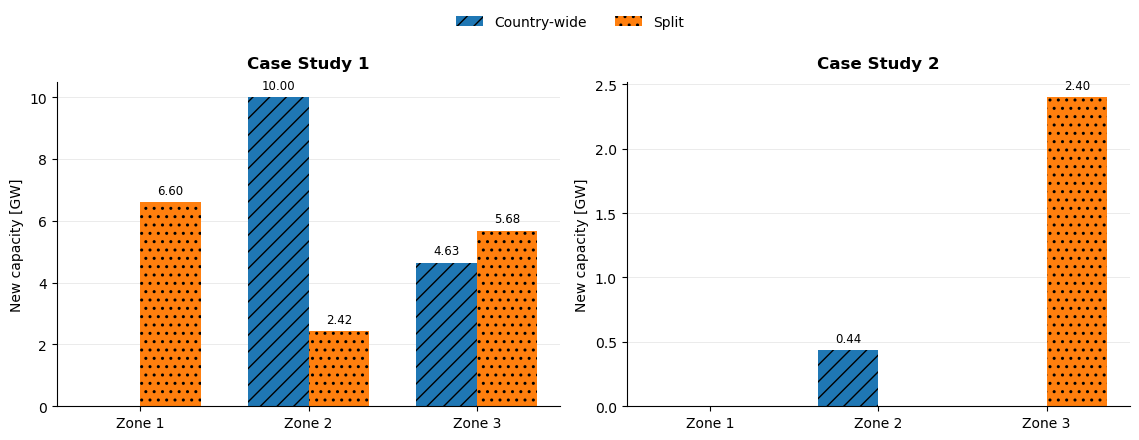

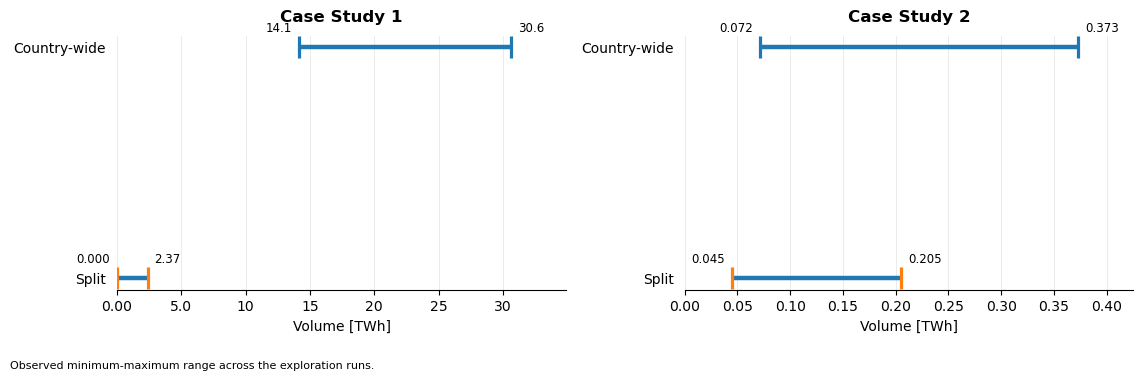

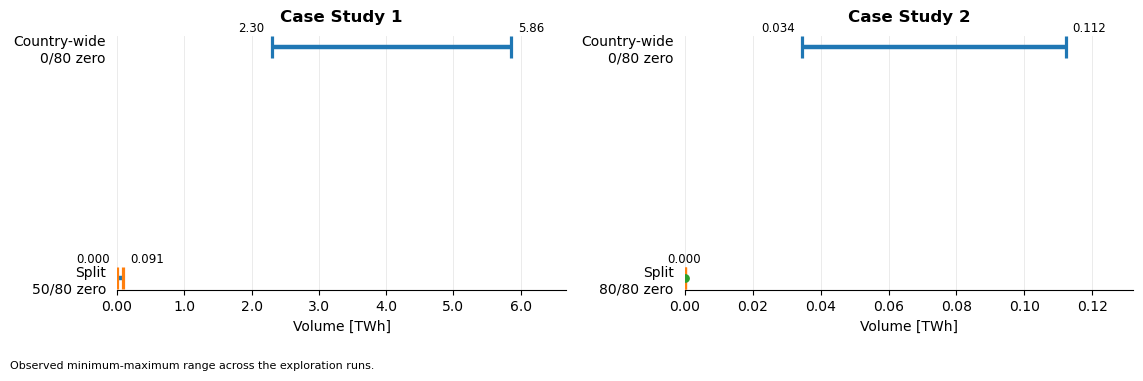

In [13]:
from matplotlib.ticker import FuncFormatter


def save_section_figure(fig, filename):
    """Save each figure as PDF and PNG in the existing output directory."""
    stem = Path(filename).stem

    fig.savefig(
        output_dir / f"{stem}.pdf",
        bbox_inches="tight",
    )
    fig.savefig(
        output_dir / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(fig)


def style_axis(ax, grid_axis="y"):
    """Apply restrained academic formatting."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis=grid_axis, alpha=0.25, linewidth=0.7)
    ax.set_axisbelow(True)


def format_twh_tick(value, _):
    if abs(value) >= 10:
        return f"{value:.0f}"
    if abs(value) >= 1:
        return f"{value:.1f}"
    return f"{value:.2f}"


def format_twh_label(value):
    if abs(value) >= 10:
        return f"{value:.1f}"
    if abs(value) >= 1:
        return f"{value:.2f}"
    return f"{value:.3f}"


def plot_two_panel_ranges(
    metric,
    filename,
    show_zero_shedding_counts=False,
):
    """Plot observed minimum-maximum ranges for both case studies."""
    metric_data = congestion_long.loc[
        congestion_long["metric"] == metric
    ].copy()

    case_studies = ["Case Study 1", "Case Study 2"]
    design_order = ["Country-wide", "Split"]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11.5, 3.8),
    )

    for ax, case_study in zip(axes, case_studies):
        data = metric_data.loc[
            metric_data["case_study"] == case_study
        ].copy()

        data["design_order"] = data["design"].map(
            {
                design: index
                for index, design in enumerate(design_order)
            }
        )
        data = data.sort_values("design_order")

        data["min_twh"] = data["min"] / 1_000_000
        data["max_twh"] = data["max"] / 1_000_000

        positions = np.arange(len(data))
        labels = list(data["design"])

        if show_zero_shedding_counts:
            counts = (
                load_shedding_counts.loc[
                    load_shedding_counts["case_study"]
                    == case_study
                ]
                .set_index("design")
            )

            labels = [
                (
                    f"{design}\n"
                    f"{int(counts.loc[design, 'zero_grid_load_shedding_runs'])}"
                    f"/{int(counts.loc[design, 'runs'])} zero"
                )
                for design in data["design"]
            ]

        for position, row in zip(
            positions,
            data.itertuples(index=False),
        ):
            lower = row.min_twh
            upper = row.max_twh

            ax.hlines(
                position,
                lower,
                upper,
                linewidth=3.2,
                zorder=2,
            )
            ax.scatter(
                [lower, upper],
                [position, position],
                marker="|",
                s=230,
                linewidths=2.3,
                zorder=3,
            )

            if np.isclose(lower, upper):
                ax.scatter(
                    lower,
                    position,
                    s=28,
                    zorder=4,
                )
                ax.annotate(
                    format_twh_label(lower),
                    (lower, position),
                    xytext=(0, 9),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=8.5,
                )
            else:
                ax.annotate(
                    format_twh_label(lower),
                    (lower, position),
                    xytext=(-5, 9),
                    textcoords="offset points",
                    ha="right",
                    va="bottom",
                    fontsize=8.5,
                )
                ax.annotate(
                    format_twh_label(upper),
                    (upper, position),
                    xytext=(5, 9),
                    textcoords="offset points",
                    ha="left",
                    va="bottom",
                    fontsize=8.5,
                )

        ax.set_yticks(positions)
        ax.set_yticklabels(labels)
        ax.invert_yaxis()

        ax.set_xlabel("Volume [TWh]")
        ax.set_title(
            case_study,
            fontweight="semibold",
            pad=10,
        )
        ax.xaxis.set_major_formatter(
            FuncFormatter(format_twh_tick)
        )

        maximum = data["max_twh"].max()
        margin = max(maximum * 0.14, 0.02)
        ax.set_xlim(0, maximum + margin)

        ax.spines["left"].set_visible(False)
        ax.tick_params(axis="y", length=0, pad=8)
        style_axis(ax, grid_axis="x")

    fig.text(
        0.01,
        0.01,
        "Observed minimum-maximum range across the exploration runs.",
        ha="left",
        va="bottom",
        fontsize=8,
    )

    fig.tight_layout(rect=(0, 0.07, 1, 1))
    save_section_figure(fig, filename)


if make_plots:

    # --------------------------------------------------------
    # Figure 1: new capacity by physical zone
    # --------------------------------------------------------

    zonal_plot_data = zone_siting.copy()
    zonal_plot_data["range_mw"] = (
        zonal_plot_data["max_mw"]
        - zonal_plot_data["min_mw"]
    )

    material_variation = zonal_plot_data["range_mw"] > 0.01

    if material_variation.any():
        problematic = zonal_plot_data.loc[
            material_variation,
            [
                "case_study",
                "design",
                "zone",
                "min_mw",
                "max_mw",
            ],
        ]

        raise ValueError(
            "Material variation found in zonal investment totals:\n"
            + problematic.to_string(index=False)
        )

    # Min and max are equal apart from numerical tolerances.
    # No mean or median is used.
    zonal_plot_data["capacity_gw"] = (
        zonal_plot_data["max_mw"]
        .where(zonal_plot_data["max_mw"] >= 0.01, 0.0)
        / 1_000
    )

    case_studies = ["Case Study 1", "Case Study 2"]
    design_order = ["Country-wide", "Split"]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11.5, 4.3),
    )

    for ax, case_study in zip(axes, case_studies):
        data = (
            zonal_plot_data.loc[
                zonal_plot_data["case_study"] == case_study
            ]
            .pivot(
                index="zone",
                columns="design",
                values="capacity_gw",
            )
            .reindex([1, 2, 3])
            .fillna(0)
        )

        positions = np.arange(len(data.index))
        width = 0.36

        for design_index, design in enumerate(design_order):
            offset = (design_index - 0.5) * width

            bars = ax.bar(
                positions + offset,
                data[design],
                width=width,
                label=design,
                hatch="//" if design == "Country-wide" else "..",
            )

            for bar in bars:
                value = bar.get_height()

                if value <= 0:
                    continue

                ax.annotate(
                    f"{value:.2f}",
                    (
                        bar.get_x() + bar.get_width() / 2,
                        value,
                    ),
                    xytext=(0, 4),
                    textcoords="offset points",
                    ha="center",
                    va="bottom",
                    fontsize=8.5,
                )

        ax.set_xticks(positions)
        ax.set_xticklabels(
            [f"Zone {zone}" for zone in data.index]
        )
        ax.set_ylabel("New capacity [GW]")
        ax.set_title(
            case_study,
            fontweight="semibold",
            pad=10,
        )
        style_axis(ax, grid_axis="y")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, 1.03),
    )

    fig.tight_layout(rect=(0, 0, 1, 0.94))
    save_section_figure(
        fig,
        "new_capacity_by_zone",
    )

    # --------------------------------------------------------
    # Figure 2: redispatch-volume ranges
    # --------------------------------------------------------

    plot_two_panel_ranges(
        metric="redispatch_volume_mwh",
        filename="redispatch_volume_ranges",
    )

    # --------------------------------------------------------
    # Figure 3: grid-related load-shedding ranges
    # --------------------------------------------------------

    plot_two_panel_ranges(
        metric="grid_related_load_shedding_mwh",
        filename="grid_load_shedding_ranges",
        show_zero_shedding_counts=True,
    )

## 5.3.3 Congestion outcomes


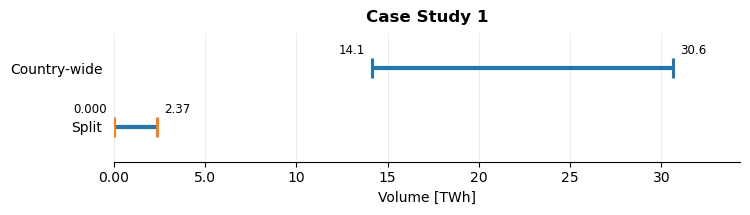

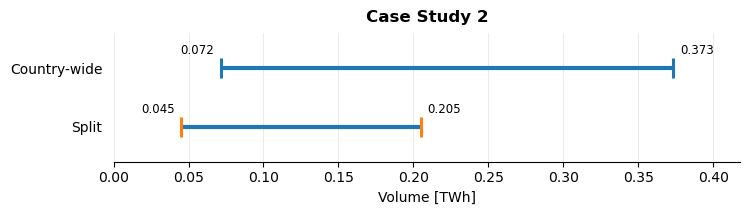

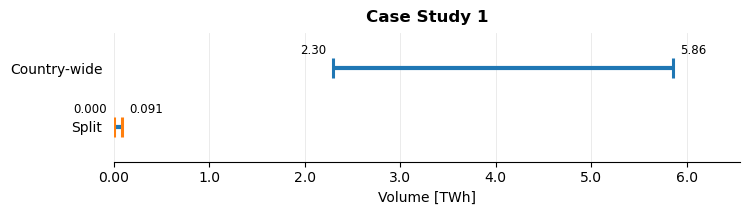

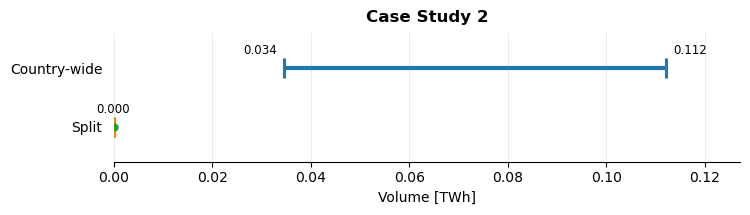

In [14]:
def plot_single_case_range(
    metric,
    case_study,
    filename,
    show_zero_shedding_counts=False,
):
    """Plot one compact minimum–maximum comparison for one case study."""

    data = congestion_long.loc[
        (congestion_long["metric"] == metric)
        & (congestion_long["case_study"] == case_study)
    ].copy()

    design_order = ["Country-wide", "Split"]

    data["design_order"] = data["design"].map(
        {
            design: index
            for index, design in enumerate(design_order)
        }
    )

    data = data.sort_values("design_order")

    # Convert MWh to TWh.
    data["min_twh"] = data["min"] / 1_000_000
    data["max_twh"] = data["max"] / 1_000_000

    # Smaller distance between the two design rows.
    positions = np.array([0.25, -0.25])

    labels = list(data["design"])

    if show_zero_shedding_counts:
        counts = (
            load_shedding_counts.loc[
                load_shedding_counts["case_study"] == case_study
            ]
            .set_index("design")
        )

        labels = [
            (
                f"{design} "
                f"({int(counts.loc[design, 'zero_grid_load_shedding_runs'])}"
                f"/{int(counts.loc[design, 'runs'])} zero)"
            )
            for design in data["design"]
        ]

    fig, ax = plt.subplots(
        figsize=(7.6, 2.25),
    )

    for position, row in zip(
        positions,
        data.itertuples(index=False),
    ):
        lower = row.min_twh
        upper = row.max_twh

        ax.hlines(
            position,
            lower,
            upper,
            linewidth=3.0,
            zorder=2,
        )

        ax.scatter(
            [lower, upper],
            [position, position],
            marker="|",
            s=210,
            linewidths=2.2,
            zorder=3,
        )

        if np.isclose(lower, upper):
            ax.scatter(
                lower,
                position,
                s=26,
                zorder=4,
            )

            ax.annotate(
                format_twh_label(lower),
                (lower, position),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8.5,
            )

        else:
            ax.annotate(
                format_twh_label(lower),
                (lower, position),
                xytext=(-5, 8),
                textcoords="offset points",
                ha="right",
                va="bottom",
                fontsize=8.5,
            )

            ax.annotate(
                format_twh_label(upper),
                (upper, position),
                xytext=(5, 8),
                textcoords="offset points",
                ha="left",
                va="bottom",
                fontsize=8.5,
            )

    ax.set_yticks(positions)
    ax.set_yticklabels(labels)

    ax.set_xlabel("Volume [TWh]")
    ax.set_title(
        case_study,
        fontweight="semibold",
        pad=8,
    )

    ax.xaxis.set_major_formatter(
        FuncFormatter(format_twh_tick)
    )

    maximum = data["max_twh"].max()
    margin = max(maximum * 0.12, 0.015)

    ax.set_xlim(
        0,
        maximum + margin,
    )

    ax.set_ylim(
        -0.55,
        0.55,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

    ax.tick_params(
        axis="y",
        length=0,
        pad=8,
    )

    ax.grid(
        axis="x",
        alpha=0.25,
        linewidth=0.7,
    )
    ax.set_axisbelow(True)

    fig.tight_layout()

    save_section_figure(
        fig,
        filename,
    )


if make_plots:

    # Redispatch-volume ranges
    plot_single_case_range(
        metric="redispatch_volume_mwh",
        case_study="Case Study 1",
        filename="cs1_redispatch_volume_range",
    )

    plot_single_case_range(
        metric="redispatch_volume_mwh",
        case_study="Case Study 2",
        filename="cs2_redispatch_volume_range",
    )

    # Grid-related load-shedding ranges
    plot_single_case_range(
        metric="grid_related_load_shedding_mwh",
        case_study="Case Study 1",
        filename="cs1_grid_load_shedding_range",
        show_zero_shedding_counts=False,
    )

    plot_single_case_range(
        metric="grid_related_load_shedding_mwh",
        case_study="Case Study 2",
        filename="cs2_grid_load_shedding_range",
        show_zero_shedding_counts=False,
    )

## 5.4 analysis: how cross-zonal participation modifies the locational signal


In [ ]:
sigma_percentages = [0, 25, 50, 75, 100]

cross_zonal_scenarios = {
    **{
        f"Case Study 1 - sigma {sigma / 100:.2f}":
        f"nl34_z3_sigma{sigma}"
        for sigma in sigma_percentages
    },
    **{
        f"Case Study 2 - sigma {sigma / 100:.2f}":
        f"cs2_nl34_z3_sigma{sigma}"
        for sigma in sigma_percentages
    },
}


def cross_zonal_meta(scenario):
    sigma_match = re.search(r"_sigma(\d+)$", scenario)

    if sigma_match is None:
        raise ValueError(
            f"Could not read sigma from scenario name: {scenario}"
        )

    return {
        "case_study": (
            "Case Study 2"
            if scenario.startswith("cs2_")
            else "Case Study 1"
        ),
        "sigma": int(sigma_match.group(1)) / 100,
        "design": "Split",
    }


cross_zonal_summaries = {}
cross_zonal_sources = []

for label, scenario in cross_zonal_scenarios.items():
    summary, source = merge_summary_with_reruns(scenario)

    if summary is None:
        print("Missing summary:", scenario)
        continue

    meta = cross_zonal_meta(scenario)
    cross_zonal_summaries[scenario] = summary

    cross_zonal_sources.append(
        {
            "label": label,
            "scenario": scenario,
            "case_study": meta["case_study"],
            "sigma": meta["sigma"],
            "base_file": str(source["base"]),
            "rerun_files": " | ".join(
                str(path)
                for path in source["reruns"]
            ),
            "runs_loaded": summary["run_id"].nunique(),
        }
    )

cross_zonal_sources = pd.DataFrame(
    cross_zonal_sources
).sort_values(
    ["case_study", "sigma"]
)

display(cross_zonal_sources)

expected_scenarios = set(cross_zonal_scenarios.values())
missing_scenarios = sorted(
    expected_scenarios
    - set(cross_zonal_summaries)
)

if missing_scenarios:
    print(
        "The following scenarios are missing and will not be analysed:"
    )
    for scenario in missing_scenarios:
        print("-", scenario)

if not cross_zonal_summaries:
    raise FileNotFoundError(
        "No split-design sigma-series summary files were found."
    )

cross_zonal_sources.to_csv(
    output_dir / "cross_zonal_file_sources.csv",
    index=False,
)


,label,scenario,case_study,sigma,base_file,rerun_files,runs_loaded
0,Case Study 1 - sigma 0.00,nl34_z3_sigma0,Case Study 1,0.00,C:\Users\Alex\MasterThesis\results\final_nl34_...,,80
1,Case Study 1 - sigma 0.25,nl34_z3_sigma25,Case Study 1,0.25,C:\Users\Alex\MasterThesis\results\final_nl34_...,,80
2,Case Study 1 - sigma 0.50,nl34_z3_sigma50,Case Study 1,0.50,C:\Users\Alex\MasterThesis\results\final_nl34_...,,80
3,Case Study 1 - sigma 0.75,nl34_z3_sigma75,Case Study 1,0.75,C:\Users\Alex\MasterThesis\results\final_nl34_...,,80
4,Case Study 1 - sigma 1.00,nl34_z3_sigma100,Case Study 1,1.00,C:\Users\Alex\MasterThesis\results\final_nl34_...,,80
5,Case Study 2 - sigma 0.00,cs2_nl34_z3_sigma0,Case Study 2,0.00,C:\Users\Alex\MasterThesis\results\final_cs2_n...,C:\Users\Alex\MasterThesis\results\reruns_cs2_...,80
6,Case Study 2 - sigma 0.25,cs2_nl34_z3_sigma25,Case Study 2,0.25,C:\Users\Alex\MasterThesis\results\final_cs2_n...,C:\Users\Alex\MasterThesis\results\reruns_cs2_...,80
7,Case Study 2 - sigma 0.50,cs2_nl34_z3_sigma50,Case Study 2,0.50,C:\Users\Alex\MasterThesis\results\final_cs2_n...,C:\Users\Alex\MasterThesis\results\reruns_cs2_...,80
8,Case Study 2 - sigma 0.75,cs2_nl34_z3_sigma75,Case Study 2,0.75,C:\Users\Alex\MasterThesis\results\final_cs2_n...,C:\Users\Alex\MasterThesis\results\reruns_cs2_...,80
9,Case Study 2 - sigma 1.00,cs2_nl34_z3_sigma100,Case Study 2,1.00,C:\Users\Alex\MasterThesis\results\final_cs2_n...,C:\Users\Alex\MasterThesis\results\reruns_cs2_...,80


### 5.4.1 Zonal capacity obligations and transfers

In [ ]:
obligation_frames = []
system_balance_frames = []
transfer_frames = []

for scenario, summary in cross_zonal_summaries.items():
    meta = cross_zonal_meta(scenario)

    cm_demand, demand_source = load_detail_with_optional_rerun(
        "cm_demand",
        scenario,
    )
    cm_diagnostics, diagnostics_source = (
        load_detail_with_optional_rerun(
            "cm_diagnostics",
            scenario,
        )
    )
    transfers, transfer_source = load_detail_with_optional_rerun(
        "transfers",
        scenario,
    )

    if cm_demand is None:
        print("Missing capacity-demand detail:", scenario)
        continue

    demand = cm_demand.copy()
    demand["scenario"] = scenario
    demand["case_study"] = meta["case_study"]
    demand["sigma"] = meta["sigma"]
    demand["zonal_expenditure"] = (
        demand["c_dem"]
        * demand["lambda_c_z"]
    )
    demand["requirement_binding"] = (
        (
            demand["c_dem"]
            - demand["req_z"]
        ).abs()
        <= 1e-3
    )

    obligation_frames.append(demand)

    per_run_system = (
        demand
        .groupby(
            [
                "scenario",
                "case_study",
                "sigma",
                "run_id",
            ],
            as_index=False,
        )
        .agg(
            base_zonal_requirement_sum_mw=(
                "d_c_z",
                "sum",
            ),
            net_import_sum_mw=(
                "net_import",
                "sum",
            ),
            effective_requirement_sum_mw=(
                "req_z",
                "sum",
            ),
            accepted_capacity_sum_mw=(
                "c_dem",
                "sum",
            ),
            total_capacity_market_expenditure=(
                "zonal_expenditure",
                "sum",
            ),
        )
    )

    if cm_diagnostics is not None:
        diagnostics = (
            cm_diagnostics[
                [
                    "run_id",
                    "sys_req",
                    "sys_slack",
                ]
            ]
            .drop_duplicates("run_id")
        )

        per_run_system = per_run_system.merge(
            diagnostics,
            on="run_id",
            how="left",
        )

        per_run_system[
            "system_requirement_binding"
        ] = (
            per_run_system["sys_slack"].abs()
            <= 1e-3
        )

    system_balance_frames.append(per_run_system)

    if transfers is not None:
        transfer = transfers.copy()
        transfer["scenario"] = scenario
        transfer["case_study"] = meta["case_study"]
        transfer["sigma"] = meta["sigma"]
        transfer["positive_limit_available"] = (
            transfer["bound"] > 1e-6
        )
        transfer["binding_positive_limit"] = (
            transfer["positive_limit_available"]
            & transfer["at_bound"].isin(
                ["upper", "lower"]
            )
        )
        transfer_frames.append(transfer)


obligations_long = pd.concat(
    obligation_frames,
    ignore_index=True,
)

system_balance_by_run = pd.concat(
    system_balance_frames,
    ignore_index=True,
)

if transfer_frames:
    transfers_long = pd.concat(
        transfer_frames,
        ignore_index=True,
    )
else:
    transfers_long = pd.DataFrame()


obligations_by_zone = (
    obligations_long
    .groupby(
        [
            "scenario",
            "case_study",
            "sigma",
            "zone",
        ],
        as_index=False,
    )
    .agg(
        base_requirement_min_mw=(
            "d_c_z",
            "min",
        ),
        base_requirement_max_mw=(
            "d_c_z",
            "max",
        ),
        net_import_min_mw=(
            "net_import",
            "min",
        ),
        net_import_max_mw=(
            "net_import",
            "max",
        ),
        effective_requirement_min_mw=(
            "req_z",
            "min",
        ),
        effective_requirement_max_mw=(
            "req_z",
            "max",
        ),
        accepted_capacity_min_mw=(
            "c_dem",
            "min",
        ),
        accepted_capacity_max_mw=(
            "c_dem",
            "max",
        ),
        price_min_per_mw=(
            "lambda_c_z",
            "min",
        ),
        price_max_per_mw=(
            "lambda_c_z",
            "max",
        ),
        zonal_expenditure_min=(
            "zonal_expenditure",
            "min",
        ),
        zonal_expenditure_max=(
            "zonal_expenditure",
            "max",
        ),
        requirement_binding_runs=(
            "requirement_binding",
            "sum",
        ),
        runs=("run_id", "nunique"),
    )
)

obligations_by_zone["role"] = np.select(
    [
        obligations_by_zone[
            "net_import_min_mw"
        ] > 1e-3,
        obligations_by_zone[
            "net_import_max_mw"
        ] < -1e-3,
        (
            obligations_by_zone[
                "net_import_min_mw"
            ] < -1e-3
        )
        & (
            obligations_by_zone[
                "net_import_max_mw"
            ] > 1e-3
        ),
    ],
    [
        "Importer in all runs",
        "Exporter in all runs",
        "Role changes across runs",
    ],
    default="No material transfer",
)


system_balance_summary = (
    system_balance_by_run
    .groupby(
        [
            "scenario",
            "case_study",
            "sigma",
        ],
        as_index=False,
    )
    .agg(
        base_zonal_requirement_sum_min_mw=(
            "base_zonal_requirement_sum_mw",
            "min",
        ),
        base_zonal_requirement_sum_max_mw=(
            "base_zonal_requirement_sum_mw",
            "max",
        ),
        net_import_sum_min_mw=(
            "net_import_sum_mw",
            "min",
        ),
        net_import_sum_max_mw=(
            "net_import_sum_mw",
            "max",
        ),
        effective_requirement_sum_min_mw=(
            "effective_requirement_sum_mw",
            "min",
        ),
        effective_requirement_sum_max_mw=(
            "effective_requirement_sum_mw",
            "max",
        ),
        accepted_capacity_sum_min_mw=(
            "accepted_capacity_sum_mw",
            "min",
        ),
        accepted_capacity_sum_max_mw=(
            "accepted_capacity_sum_mw",
            "max",
        ),
        total_capacity_market_expenditure_min=(
            "total_capacity_market_expenditure",
            "min",
        ),
        total_capacity_market_expenditure_max=(
            "total_capacity_market_expenditure",
            "max",
        ),
        system_requirement_min_mw=(
            "sys_req",
            "min",
        ),
        system_requirement_max_mw=(
            "sys_req",
            "max",
        ),
        system_slack_min_mw=(
            "sys_slack",
            "min",
        ),
        system_slack_max_mw=(
            "sys_slack",
            "max",
        ),
        system_requirement_binding_runs=(
            "system_requirement_binding",
            "sum",
        ),
        runs=("run_id", "nunique"),
    )
)


if not transfers_long.empty:
    transfer_limits = (
        transfers_long
        .groupby(
            [
                "scenario",
                "case_study",
                "sigma",
                "zone_a",
                "zone_b",
            ],
            as_index=False,
        )
        .agg(
            bound_min_mw=("bound", "min"),
            bound_max_mw=("bound", "max"),
            transfer_min_mw=("f_ab", "min"),
            transfer_max_mw=("f_ab", "max"),
            upper_bound_runs=(
                "at_bound",
                lambda values: int(
                    (values == "upper").sum()
                ),
            ),
            lower_bound_runs=(
                "at_bound",
                lambda values: int(
                    (values == "lower").sum()
                ),
            ),
            interior_runs=(
                "at_bound",
                lambda values: int(
                    (values == "interior").sum()
                ),
            ),
            binding_positive_limit_runs=(
                "binding_positive_limit",
                "sum",
            ),
            runs=("run_id", "nunique"),
        )
    )

    transfer_limits["limit_status"] = np.where(
        transfer_limits["bound_max_mw"] <= 1e-6,
        "Participation unavailable",
        np.where(
            transfer_limits[
                "binding_positive_limit_runs"
            ] == transfer_limits["runs"],
            "Binding in all runs",
            np.where(
                transfer_limits[
                    "binding_positive_limit_runs"
                ] > 0,
                "Binding in some runs",
                "Interior in all runs",
            ),
        ),
    )
else:
    transfer_limits = pd.DataFrame()


obligations_by_zone.to_csv(
    output_dir / "cross_zonal_obligations_by_zone.csv",
    index=False,
)
system_balance_summary.to_csv(
    output_dir / "cross_zonal_system_balance.csv",
    index=False,
)
transfer_limits.to_csv(
    output_dir / "cross_zonal_transfer_limits.csv",
    index=False,
)

display(obligations_by_zone.round(3))
display(system_balance_summary.round(3))
display(transfer_limits.round(3))


,scenario,case_study,sigma,zone,base_requirement_min_mw,base_requirement_max_mw,net_import_min_mw,net_import_max_mw,effective_requirement_min_mw,effective_requirement_max_mw,accepted_capacity_min_mw,accepted_capacity_max_mw,price_min_per_mw,price_max_per_mw,zonal_expenditure_min,zonal_expenditure_max,requirement_binding_runs,runs,role
0,cs2_nl34_z3_sigma0,Case Study 2,0.00,1,7227.747,7227.747,0.000,0.000,7227.747,7227.747,7227.747,7227.747,0.000,0.000,0.000000e+00,0.000000e+00,80,80,No material transfer
1,cs2_nl34_z3_sigma0,Case Study 2,0.00,2,2560.309,2560.309,0.000,0.000,2560.309,2560.309,2560.309,4419.500,0.000,0.000,0.000000e+00,0.000000e+00,36,80,No material transfer
2,cs2_nl34_z3_sigma0,Case Study 2,0.00,3,7001.105,7001.105,0.000,0.000,7001.105,7001.105,7001.105,7001.105,34087.403,34087.403,2.386495e+08,2.386495e+08,80,80,No material transfer
3,cs2_nl34_z3_sigma100,Case Study 2,1.00,1,7227.747,7227.747,-38.453,-38.453,7266.200,7266.200,7266.200,7266.200,5975.334,5975.334,4.341797e+07,4.341797e+07,80,80,Exporter in all runs
4,cs2_nl34_z3_sigma100,Case Study 2,1.00,2,2560.309,2560.309,-2361.651,-2361.651,4921.961,4921.961,4921.961,4921.961,5975.334,5975.334,2.941036e+07,2.941036e+07,80,80,Exporter in all runs
5,cs2_nl34_z3_sigma100,Case Study 2,1.00,3,7001.105,7001.105,2400.105,2400.105,4601.000,4601.000,4601.000,4601.000,5975.334,5975.334,2.749251e+07,2.749251e+07,80,80,Importer in all runs
6,cs2_nl34_z3_sigma25,Case Study 2,0.25,1,7227.747,7227.747,-38.453,0.000,7227.747,7266.200,7227.747,7266.200,0.000,0.000,0.000000e+00,0.000000e+00,72,80,No material transfer
7,cs2_nl34_z3_sigma25,Case Study 2,0.25,2,2560.309,2560.309,-1188.672,-1150.219,3710.528,3748.981,3710.528,4419.500,0.000,0.000,0.000000e+00,0.000000e+00,9,80,Exporter in all runs
8,cs2_nl34_z3_sigma25,Case Study 2,0.25,3,7001.105,7001.105,1188.672,1188.672,5812.433,5812.433,5812.433,5812.433,18839.934,18839.934,1.095059e+08,1.095059e+08,80,80,Importer in all runs
9,cs2_nl34_z3_sigma50,Case Study 2,0.50,1,7227.747,7227.747,-38.453,-38.453,7266.200,7266.200,7266.200,7266.200,5975.334,5975.334,4.341797e+07,4.341797e+07,80,80,Exporter in all runs


,scenario,case_study,sigma,base_zonal_requirement_sum_min_mw,base_zonal_requirement_sum_max_mw,net_import_sum_min_mw,net_import_sum_max_mw,effective_requirement_sum_min_mw,effective_requirement_sum_max_mw,accepted_capacity_sum_min_mw,accepted_capacity_sum_max_mw,total_capacity_market_expenditure_min,total_capacity_market_expenditure_max,system_requirement_min_mw,system_requirement_max_mw,system_slack_min_mw,system_slack_max_mw,system_requirement_binding_runs,runs
0,cs2_nl34_z3_sigma0,Case Study 2,0.00,16789.161,16789.161,0.0,0.0,16789.161,16789.161,16789.161,18648.351,2.386495e+08,2.386495e+08,16722.708,16722.708,66.453,1925.644,0,80
1,cs2_nl34_z3_sigma100,Case Study 2,1.00,16789.161,16789.161,-0.0,0.0,16789.161,16789.161,16789.161,16789.161,1.003208e+08,1.003208e+08,16722.708,16722.708,66.453,66.453,0,80
2,cs2_nl34_z3_sigma25,Case Study 2,0.25,16789.161,16789.161,-0.0,0.0,16789.161,16789.161,16789.161,17498.133,1.095059e+08,1.095059e+08,16722.708,16722.708,66.453,775.425,0,80
3,cs2_nl34_z3_sigma50,Case Study 2,0.50,16789.161,16789.161,-0.0,0.0,16789.161,16789.161,16789.161,16789.161,1.252593e+08,1.252593e+08,16722.708,16722.708,66.453,66.453,0,80
4,cs2_nl34_z3_sigma75,Case Study 2,0.75,16789.161,16789.161,-0.0,0.0,16789.161,16789.161,16789.161,16789.161,1.003208e+08,1.003208e+08,16722.708,16722.708,66.453,66.453,0,80
5,nl34_z3_sigma0,Case Study 1,0.00,16789.161,16789.161,0.0,0.0,16789.161,16789.161,16789.161,16789.161,9.307059e+08,9.307061e+08,16722.708,16722.708,66.453,66.453,0,80
6,nl34_z3_sigma100,Case Study 1,1.00,16789.161,16789.161,0.0,0.0,16789.161,16789.161,16789.161,16789.161,8.794168e+08,8.794168e+08,16722.708,16722.708,66.453,66.453,0,80
7,nl34_z3_sigma25,Case Study 1,0.25,16789.161,16789.161,0.0,0.0,16789.161,16789.161,16789.161,16789.161,9.178838e+08,9.178838e+08,16722.708,16722.708,66.453,66.453,0,80
8,nl34_z3_sigma50,Case Study 1,0.50,16789.161,16789.161,0.0,0.0,16789.161,16789.161,16789.161,16789.161,9.050615e+08,9.050615e+08,16722.708,16722.708,66.453,66.453,0,80
9,nl34_z3_sigma75,Case Study 1,0.75,16789.161,16789.161,0.0,0.0,16789.161,16789.161,16789.161,16789.161,8.922392e+08,8.922392e+08,16722.708,16722.708,66.453,66.453,0,80


,scenario,case_study,sigma,zone_a,zone_b,bound_min_mw,bound_max_mw,transfer_min_mw,transfer_max_mw,upper_bound_runs,lower_bound_runs,interior_runs,binding_positive_limit_runs,runs,limit_status
0,cs2_nl34_z3_sigma0,Case Study 2,0.00,1,2,0.000,0.000,0.000,0.000,80,0,0,0,80,Participation unavailable
1,cs2_nl34_z3_sigma0,Case Study 2,0.00,1,3,0.000,0.000,0.000,0.000,80,0,0,0,80,Participation unavailable
2,cs2_nl34_z3_sigma0,Case Study 2,0.00,2,3,0.000,0.000,0.000,0.000,80,0,0,0,80,Participation unavailable
3,cs2_nl34_z3_sigma100,Case Study 2,1.00,1,2,2377.344,2377.344,-15.692,2338.890,0,0,80,0,80,Interior in all runs
4,cs2_nl34_z3_sigma100,Case Study 2,1.00,1,3,2377.344,2377.344,-2377.344,-22.761,0,5,75,5,80,Binding in some runs
5,cs2_nl34_z3_sigma100,Case Study 2,1.00,2,3,2377.344,2377.344,-2377.344,-22.761,0,71,9,71,80,Binding in some runs
6,cs2_nl34_z3_sigma25,Case Study 2,0.25,1,2,594.336,594.336,555.883,594.336,54,0,26,54,80,Binding in some runs
7,cs2_nl34_z3_sigma25,Case Study 2,0.25,1,3,594.336,594.336,-594.336,-594.336,0,80,0,80,80,Binding in all runs
8,cs2_nl34_z3_sigma25,Case Study 2,0.25,2,3,594.336,594.336,-594.336,-594.336,0,80,0,80,80,Binding in all runs
9,cs2_nl34_z3_sigma50,Case Study 2,0.50,1,2,1188.672,1188.672,1150.219,1150.219,0,0,80,0,80,Interior in all runs


### 5.4.2 Capacity-market expenditure and the source of procurement



In [ ]:
procurement_source_frames = []
availability_frames = []
investment_detail_frames = []

for scenario in cross_zonal_summaries:
    meta = cross_zonal_meta(scenario)

    cm_detail, cm_source = load_detail_with_optional_rerun(
        "cm_detail",
        scenario,
    )
    cm_diagnostics, diagnostics_source = (
        load_detail_with_optional_rerun(
            "cm_diagnostics",
            scenario,
        )
    )
    investment, investment_source = (
        load_detail_with_optional_rerun(
            "investment",
            scenario,
        )
    )

    if investment is not None:
        investment = investment.copy()
        investment["scenario"] = scenario
        investment["case_study"] = meta["case_study"]
        investment["sigma"] = meta["sigma"]
        investment_detail_frames.append(investment)

    if cm_detail is not None:
        procurement = (
            cm_detail
            .groupby(
                [
                    "run_id",
                    "zone",
                    "type",
                ],
                as_index=False,
            )
            .agg(
                accepted_capacity_mw=(
                    "cm_offer",
                    "sum",
                )
            )
        )

        procurement["scenario"] = scenario
        procurement["case_study"] = meta["case_study"]
        procurement["sigma"] = meta["sigma"]
        procurement_source_frames.append(procurement)

    if (
        cm_diagnostics is not None
        and investment is not None
    ):
        new_by_zone = (
            investment
            .groupby(
                [
                    "run_id",
                    "zone",
                ],
                as_index=False,
            )
            .agg(
                new_capacity_mw=("c", "sum"),
                new_fixed_cost=(
                    "fixed_cost",
                    "sum",
                ),
            )
        )

        availability = cm_diagnostics.merge(
            new_by_zone,
            on=["run_id", "zone"],
            how="left",
        )

        availability[
            [
                "new_capacity_mw",
                "new_fixed_cost",
            ]
        ] = availability[
            [
                "new_capacity_mw",
                "new_fixed_cost",
            ]
        ].fillna(0)

        # In the model, investable CCGT capacity has an eligibility
        # factor of one. Subtracting new capacity from total eligible
        # availability therefore recovers eligible legacy capacity.
        availability[
            "eligible_legacy_capacity_mw"
        ] = (
            availability["zone_avail"]
            - availability["new_capacity_mw"]
        )

        availability["scenario"] = scenario
        availability["case_study"] = meta["case_study"]
        availability["sigma"] = meta["sigma"]
        availability_frames.append(availability)


procurement_source_long = pd.concat(
    procurement_source_frames,
    ignore_index=True,
)

availability_long = pd.concat(
    availability_frames,
    ignore_index=True,
)

investment_details = pd.concat(
    investment_detail_frames,
    ignore_index=True,
)


procurement_by_source = (
    procurement_source_long
    .groupby(
        [
            "scenario",
            "case_study",
            "sigma",
            "zone",
            "type",
        ],
        as_index=False,
    )
    .agg(
        accepted_capacity_min_mw=(
            "accepted_capacity_mw",
            "min",
        ),
        accepted_capacity_max_mw=(
            "accepted_capacity_mw",
            "max",
        ),
    )
)


capacity_availability_by_zone = (
    availability_long
    .groupby(
        [
            "scenario",
            "case_study",
            "sigma",
            "zone",
        ],
        as_index=False,
    )
    .agg(
        eligible_legacy_capacity_min_mw=(
            "eligible_legacy_capacity_mw",
            "min",
        ),
        eligible_legacy_capacity_max_mw=(
            "eligible_legacy_capacity_mw",
            "max",
        ),
        new_capacity_min_mw=(
            "new_capacity_mw",
            "min",
        ),
        new_capacity_max_mw=(
            "new_capacity_mw",
            "max",
        ),
        total_eligible_capacity_min_mw=(
            "zone_avail",
            "min",
        ),
        total_eligible_capacity_max_mw=(
            "zone_avail",
            "max",
        ),
        new_fixed_cost_min=(
            "new_fixed_cost",
            "min",
        ),
        new_fixed_cost_max=(
            "new_fixed_cost",
            "max",
        ),
    )
)


investment_totals_by_run = (
    investment_details
    .groupby(
        [
            "scenario",
            "case_study",
            "sigma",
            "run_id",
        ],
        as_index=False,
    )
    .agg(
        total_new_capacity_mw=("c", "sum"),
        total_new_fixed_cost=(
            "fixed_cost",
            "sum",
        ),
    )
)


capacity_market_totals = (
    system_balance_by_run
    .merge(
        investment_totals_by_run,
        on=[
            "scenario",
            "case_study",
            "sigma",
            "run_id",
        ],
        how="left",
    )
    .groupby(
        [
            "scenario",
            "case_study",
            "sigma",
        ],
        as_index=False,
    )
    .agg(
        required_procurement_min_mw=(
            "effective_requirement_sum_mw",
            "min",
        ),
        required_procurement_max_mw=(
            "effective_requirement_sum_mw",
            "max",
        ),
        accepted_capacity_min_mw=(
            "accepted_capacity_sum_mw",
            "min",
        ),
        accepted_capacity_max_mw=(
            "accepted_capacity_sum_mw",
            "max",
        ),
        total_new_capacity_min_mw=(
            "total_new_capacity_mw",
            "min",
        ),
        total_new_capacity_max_mw=(
            "total_new_capacity_mw",
            "max",
        ),
        total_new_fixed_cost_min=(
            "total_new_fixed_cost",
            "min",
        ),
        total_new_fixed_cost_max=(
            "total_new_fixed_cost",
            "max",
        ),
        capacity_market_expenditure_min=(
            "total_capacity_market_expenditure",
            "min",
        ),
        capacity_market_expenditure_max=(
            "total_capacity_market_expenditure",
            "max",
        ),
    )
)


zonal_market_results = obligations_by_zone[
    [
        "scenario",
        "case_study",
        "sigma",
        "zone",
        "effective_requirement_min_mw",
        "effective_requirement_max_mw",
        "accepted_capacity_min_mw",
        "accepted_capacity_max_mw",
        "price_min_per_mw",
        "price_max_per_mw",
        "zonal_expenditure_min",
        "zonal_expenditure_max",
    ]
].merge(
    capacity_availability_by_zone,
    on=[
        "scenario",
        "case_study",
        "sigma",
        "zone",
    ],
    how="left",
)


procurement_by_source.to_csv(
    output_dir / "cross_zonal_procurement_by_source.csv",
    index=False,
)
capacity_availability_by_zone.to_csv(
    output_dir / "cross_zonal_capacity_availability_by_zone.csv",
    index=False,
)
zonal_market_results.to_csv(
    output_dir / "cross_zonal_zonal_market_results.csv",
    index=False,
)
capacity_market_totals.to_csv(
    output_dir / "cross_zonal_capacity_market_totals.csv",
    index=False,
)

display(zonal_market_results.round(3))
display(procurement_by_source.round(3))
display(capacity_market_totals.round(3))


,scenario,case_study,sigma,zone,effective_requirement_min_mw,effective_requirement_max_mw,accepted_capacity_min_mw,accepted_capacity_max_mw,price_min_per_mw,price_max_per_mw,zonal_expenditure_min,zonal_expenditure_max,eligible_legacy_capacity_min_mw,eligible_legacy_capacity_max_mw,new_capacity_min_mw,new_capacity_max_mw,total_eligible_capacity_min_mw,total_eligible_capacity_max_mw,new_fixed_cost_min,new_fixed_cost_max
0,cs2_nl34_z3_sigma0,Case Study 2,0.00,1,7227.747,7227.747,7227.747,7227.747,0.000,0.000,0.000000e+00,0.000000e+00,7266.2,7266.2,0.000,0.000,7266.200,7266.200,0.000000e+00,2.060000e-01
1,cs2_nl34_z3_sigma0,Case Study 2,0.00,2,2560.309,2560.309,2560.309,4419.500,0.000,0.000,0.000000e+00,0.000000e+00,4419.5,4419.5,0.000,0.000,4419.500,4419.500,0.000000e+00,0.000000e+00
2,cs2_nl34_z3_sigma0,Case Study 2,0.00,3,7001.105,7001.105,7001.105,7001.105,34087.403,34087.403,2.386495e+08,2.386495e+08,4601.0,4601.0,2400.105,2400.105,7001.105,7001.105,1.294509e+08,1.294509e+08
3,cs2_nl34_z3_sigma100,Case Study 2,1.00,1,7266.200,7266.200,7266.200,7266.200,5975.334,5975.334,4.341797e+07,4.341797e+07,7266.2,7266.2,0.000,0.000,7266.200,7266.200,0.000000e+00,6.780000e-01
4,cs2_nl34_z3_sigma100,Case Study 2,1.00,2,4921.961,4921.961,4921.961,4921.961,5975.334,5975.334,2.941036e+07,2.941036e+07,4419.5,4419.5,502.461,502.461,4921.961,4921.961,2.439043e+07,2.439043e+07
5,cs2_nl34_z3_sigma100,Case Study 2,1.00,3,4601.000,4601.000,4601.000,4601.000,5975.334,5975.334,2.749251e+07,2.749251e+07,4601.0,4601.0,0.000,0.000,4601.000,4601.000,0.000000e+00,6.800000e-02
6,cs2_nl34_z3_sigma25,Case Study 2,0.25,1,7227.747,7266.200,7227.747,7266.200,0.000,0.000,0.000000e+00,0.000000e+00,7266.2,7266.2,0.000,0.000,7266.200,7266.200,0.000000e+00,4.000000e-03
7,cs2_nl34_z3_sigma25,Case Study 2,0.25,2,3710.528,3748.981,3710.528,4419.500,0.000,0.000,0.000000e+00,0.000000e+00,4419.5,4419.5,0.000,0.000,4419.500,4419.500,0.000000e+00,0.000000e+00
8,cs2_nl34_z3_sigma25,Case Study 2,0.25,3,5812.433,5812.433,5812.433,5812.433,18839.934,18839.934,1.095059e+08,1.095059e+08,4601.0,4601.0,1211.433,1211.433,5812.433,5812.433,6.533926e+07,6.533926e+07
9,cs2_nl34_z3_sigma50,Case Study 2,0.50,1,7266.200,7266.200,7266.200,7266.200,5975.334,5975.334,4.341797e+07,4.341797e+07,7266.2,7266.2,0.000,0.000,7266.200,7266.200,0.000000e+00,1.700000e-02


,scenario,case_study,sigma,zone,type,accepted_capacity_min_mw,accepted_capacity_max_mw
0,cs2_nl34_z3_sigma0,Case Study 2,0.00,1,investable,0.000,0.000
1,cs2_nl34_z3_sigma0,Case Study 2,0.00,1,legacy,7227.747,7227.747
2,cs2_nl34_z3_sigma0,Case Study 2,0.00,2,investable,0.000,0.000
3,cs2_nl34_z3_sigma0,Case Study 2,0.00,2,legacy,2560.309,4419.500
4,cs2_nl34_z3_sigma0,Case Study 2,0.00,3,investable,2400.105,2400.105
5,cs2_nl34_z3_sigma0,Case Study 2,0.00,3,legacy,4601.000,4601.000
6,cs2_nl34_z3_sigma100,Case Study 2,1.00,1,investable,0.000,0.000
7,cs2_nl34_z3_sigma100,Case Study 2,1.00,1,legacy,7266.200,7266.200
8,cs2_nl34_z3_sigma100,Case Study 2,1.00,2,investable,502.461,502.461
9,cs2_nl34_z3_sigma100,Case Study 2,1.00,2,legacy,4419.500,4419.500


,scenario,case_study,sigma,required_procurement_min_mw,required_procurement_max_mw,accepted_capacity_min_mw,accepted_capacity_max_mw,total_new_capacity_min_mw,total_new_capacity_max_mw,total_new_fixed_cost_min,total_new_fixed_cost_max,capacity_market_expenditure_min,capacity_market_expenditure_max
0,cs2_nl34_z3_sigma0,Case Study 2,0.00,16789.161,16789.161,16789.161,18648.351,2400.105,2400.105,1.294509e+08,1.294509e+08,2.386495e+08,2.386495e+08
1,cs2_nl34_z3_sigma100,Case Study 2,1.00,16789.161,16789.161,16789.161,16789.161,502.461,502.461,2.439043e+07,2.439043e+07,1.003208e+08,1.003208e+08
2,cs2_nl34_z3_sigma25,Case Study 2,0.25,16789.161,16789.161,16789.161,17498.133,1211.433,1211.433,6.533926e+07,6.533926e+07,1.095059e+08,1.095059e+08
3,cs2_nl34_z3_sigma50,Case Study 2,0.50,16789.161,16789.161,16789.161,16789.161,502.461,502.461,2.451320e+07,2.451320e+07,1.252593e+08,1.252593e+08
4,cs2_nl34_z3_sigma75,Case Study 2,0.75,16789.161,16789.161,16789.161,16789.161,502.461,502.461,2.439043e+07,2.439043e+07,1.003208e+08,1.003208e+08
5,nl34_z3_sigma0,Case Study 1,0.00,16789.161,16789.161,16789.161,16789.161,14700.961,14700.963,8.154503e+08,8.154504e+08,9.307059e+08,9.307061e+08
6,nl34_z3_sigma100,Case Study 1,1.00,16789.161,16789.161,16789.161,16789.161,14700.961,14700.961,7.641610e+08,7.641610e+08,8.794168e+08,8.794168e+08
7,nl34_z3_sigma25,Case Study 1,0.25,16789.161,16789.161,16789.161,16789.161,14700.961,14700.961,8.026279e+08,8.026279e+08,9.178838e+08,9.178838e+08
8,nl34_z3_sigma50,Case Study 1,0.50,16789.161,16789.161,16789.161,16789.161,14700.961,14700.961,7.898056e+08,7.898056e+08,9.050615e+08,9.050615e+08
9,nl34_z3_sigma75,Case Study 1,0.75,16789.161,16789.161,16789.161,16789.161,14700.961,14700.961,7.769833e+08,7.769833e+08,8.922392e+08,8.922392e+08


### 5.4.3 Siting response


In [ ]:
cross_zonal_investment_long = investment_details[
    [
        "scenario",
        "case_study",
        "sigma",
        "run_id",
        "generator",
        "bus",
        "zone",
        "cap_max",
        "c",
        "fixed_cost",
    ]
].rename(
    columns={"c": "new_capacity_mw"}
)


new_capacity_by_zone_run = (
    cross_zonal_investment_long
    .groupby(
        [
            "scenario",
            "case_study",
            "sigma",
            "run_id",
            "zone",
        ],
        as_index=False,
    )
    .agg(
        new_capacity_mw=(
            "new_capacity_mw",
            "sum",
        )
    )
)


new_capacity_by_zone = (
    new_capacity_by_zone_run
    .groupby(
        [
            "scenario",
            "case_study",
            "sigma",
            "zone",
        ],
        as_index=False,
    )
    .agg(
        new_capacity_min_mw=(
            "new_capacity_mw",
            "min",
        ),
        new_capacity_max_mw=(
            "new_capacity_mw",
            "max",
        ),
    )
)


new_capacity_by_node = (
    cross_zonal_investment_long
    .groupby(
        [
            "scenario",
            "case_study",
            "sigma",
            "zone",
            "bus",
        ],
        as_index=False,
    )
    .agg(
        new_capacity_min_mw=(
            "new_capacity_mw",
            "min",
        ),
        new_capacity_max_mw=(
            "new_capacity_mw",
            "max",
        ),
        material_investment_runs=(
            "new_capacity_mw",
            lambda values: int(
                (
                    values
                    > material_build_mw
                ).sum()
            ),
        ),
        runs=("run_id", "nunique"),
    )
)


total_investment_run = (
    cross_zonal_investment_long
    .groupby(
        [
            "scenario",
            "case_study",
            "sigma",
            "run_id",
        ]
    )["new_capacity_mw"]
    .sum()
    .rename("total_new_capacity_mw")
)


active_nodes_run = (
    cross_zonal_investment_long
    .assign(
        active=(
            cross_zonal_investment_long[
                "new_capacity_mw"
            ]
            > material_build_mw
        )
    )
    .groupby(
        [
            "scenario",
            "case_study",
            "sigma",
            "run_id",
        ]
    )["active"]
    .sum()
    .rename("active_nodes")
)


shares = cross_zonal_investment_long.merge(
    total_investment_run.reset_index(),
    on=[
        "scenario",
        "case_study",
        "sigma",
        "run_id",
    ],
    how="left",
)

shares["node_share"] = np.where(
    shares["total_new_capacity_mw"] > zero_tolerance,
    shares["new_capacity_mw"]
    / shares["total_new_capacity_mw"],
    0,
)


largest_node_share_run = (
    shares
    .groupby(
        [
            "scenario",
            "case_study",
            "sigma",
            "run_id",
        ]
    )["node_share"]
    .max()
    .rename("largest_node_share")
)


node_hhi_run = (
    shares
    .groupby(
        [
            "scenario",
            "case_study",
            "sigma",
            "run_id",
        ]
    )["node_share"]
    .apply(
        lambda values: float(
            (values ** 2).sum()
        )
    )
    .rename("node_hhi")
)


siting_concentration_run = pd.concat(
    [
        total_investment_run,
        active_nodes_run,
        largest_node_share_run,
        node_hhi_run,
    ],
    axis=1,
).reset_index()


siting_concentration = (
    siting_concentration_run
    .groupby(
        [
            "scenario",
            "case_study",
            "sigma",
        ],
        as_index=False,
    )
    .agg(
        total_new_capacity_min_mw=(
            "total_new_capacity_mw",
            "min",
        ),
        total_new_capacity_max_mw=(
            "total_new_capacity_mw",
            "max",
        ),
        active_nodes_min=(
            "active_nodes",
            "min",
        ),
        active_nodes_max=(
            "active_nodes",
            "max",
        ),
        largest_node_share_min=(
            "largest_node_share",
            "min",
        ),
        largest_node_share_max=(
            "largest_node_share",
            "max",
        ),
        node_hhi_min=(
            "node_hhi",
            "min",
        ),
        node_hhi_max=(
            "node_hhi",
            "max",
        ),
    )
)


# Paired changes relative to sigma = 0.
sigma0_nodes = (
    cross_zonal_investment_long.loc[
        cross_zonal_investment_long["sigma"] == 0,
        [
            "case_study",
            "run_id",
            "bus",
            "new_capacity_mw",
        ],
    ]
    .rename(
        columns={
            "new_capacity_mw":
            "new_capacity_sigma0_mw"
        }
    )
)


node_change_run = (
    cross_zonal_investment_long
    .merge(
        sigma0_nodes,
        on=[
            "case_study",
            "run_id",
            "bus",
        ],
        how="left",
    )
)

node_change_run[
    "change_vs_sigma0_mw"
] = (
    node_change_run["new_capacity_mw"]
    - node_change_run[
        "new_capacity_sigma0_mw"
    ]
)


node_change_vs_sigma0 = (
    node_change_run
    .groupby(
        [
            "scenario",
            "case_study",
            "sigma",
            "zone",
            "bus",
        ],
        as_index=False,
    )
    .agg(
        change_min_mw=(
            "change_vs_sigma0_mw",
            "min",
        ),
        change_max_mw=(
            "change_vs_sigma0_mw",
            "max",
        ),
    )
)


node_change_vs_sigma0["change_class"] = np.select(
    [
        node_change_vs_sigma0[
            "change_min_mw"
        ] > material_build_mw,
        node_change_vs_sigma0[
            "change_max_mw"
        ] < -material_build_mw,
        (
            node_change_vs_sigma0[
                "change_min_mw"
            ] < -material_build_mw
        )
        & (
            node_change_vs_sigma0[
                "change_max_mw"
            ] > material_build_mw
        ),
        node_change_vs_sigma0[
            "change_max_mw"
        ] > material_build_mw,
        node_change_vs_sigma0[
            "change_min_mw"
        ] < -material_build_mw,
    ],
    [
        "Gains in all paired runs",
        "Loses in all paired runs",
        "Direction differs across paired runs",
        "Gains in some paired runs",
        "Loses in some paired runs",
    ],
    default="No material change",
)


# Country-wide physical-zone benchmark.
countrywide_investment_frames = []

for case_study, scenario in [
    ("Case Study 1", "nl34_z1_sigma0"),
    ("Case Study 2", "cs2_nl34_z1_sigma0"),
]:
    investment, source = load_detail_with_optional_rerun(
        "investment",
        scenario,
    )

    if investment is None:
        print("Missing country-wide investment file:", scenario)
        continue

    zone_map, zone_map_source = build_bus_zone_map(
        case_study
    )

    benchmark = investment.copy()
    benchmark["physical_zone"] = (
        benchmark["bus"].map(zone_map)
    )
    benchmark["case_study"] = case_study

    countrywide_investment_frames.append(
        benchmark[
            [
                "case_study",
                "run_id",
                "physical_zone",
                "c",
            ]
        ]
    )


if countrywide_investment_frames:
    countrywide_investment = pd.concat(
        countrywide_investment_frames,
        ignore_index=True,
    )

    countrywide_zone_run = (
        countrywide_investment
        .groupby(
            [
                "case_study",
                "run_id",
                "physical_zone",
            ],
            as_index=False,
        )
        .agg(
            countrywide_new_capacity_mw=(
                "c",
                "sum",
            )
        )
        .rename(
            columns={
                "physical_zone": "zone"
            }
        )
    )

    distance_data = new_capacity_by_zone_run.merge(
        countrywide_zone_run,
        on=[
            "case_study",
            "run_id",
            "zone",
        ],
        how="left",
    )

    distance_data[
        "countrywide_new_capacity_mw"
    ] = distance_data[
        "countrywide_new_capacity_mw"
    ].fillna(0)

    distance_data[
        "absolute_zonal_difference_mw"
    ] = (
        distance_data["new_capacity_mw"]
        - distance_data[
            "countrywide_new_capacity_mw"
        ]
    ).abs()

    distance_to_countrywide_run = (
        distance_data
        .groupby(
            [
                "scenario",
                "case_study",
                "sigma",
                "run_id",
            ],
            as_index=False,
        )
        .agg(
            zonal_l1_distance_to_countrywide_mw=(
                "absolute_zonal_difference_mw",
                "sum",
            )
        )
    )

    distance_to_countrywide = (
        distance_to_countrywide_run
        .groupby(
            [
                "scenario",
                "case_study",
                "sigma",
            ],
            as_index=False,
        )
        .agg(
            distance_min_mw=(
                "zonal_l1_distance_to_countrywide_mw",
                "min",
            ),
            distance_max_mw=(
                "zonal_l1_distance_to_countrywide_mw",
                "max",
            ),
        )
    )
else:
    distance_to_countrywide = pd.DataFrame()


new_capacity_by_zone.to_csv(
    output_dir / "cross_zonal_new_capacity_by_zone.csv",
    index=False,
)
new_capacity_by_node.to_csv(
    output_dir / "cross_zonal_new_capacity_by_node.csv",
    index=False,
)
node_change_vs_sigma0.to_csv(
    output_dir / "cross_zonal_node_change_vs_sigma0.csv",
    index=False,
)
siting_concentration.to_csv(
    output_dir / "cross_zonal_siting_concentration.csv",
    index=False,
)
distance_to_countrywide.to_csv(
    output_dir / "cross_zonal_distance_to_countrywide.csv",
    index=False,
)

display(new_capacity_by_zone.round(3))
display(siting_concentration.round(4))
display(distance_to_countrywide.round(3))


,scenario,case_study,sigma,zone,new_capacity_min_mw,new_capacity_max_mw
0,cs2_nl34_z3_sigma0,Case Study 2,0.00,1,0.000,0.000
1,cs2_nl34_z3_sigma0,Case Study 2,0.00,2,0.000,0.000
2,cs2_nl34_z3_sigma0,Case Study 2,0.00,3,2400.105,2400.105
3,cs2_nl34_z3_sigma100,Case Study 2,1.00,1,0.000,0.000
4,cs2_nl34_z3_sigma100,Case Study 2,1.00,2,502.461,502.461
5,cs2_nl34_z3_sigma100,Case Study 2,1.00,3,0.000,0.000
6,cs2_nl34_z3_sigma25,Case Study 2,0.25,1,0.000,0.000
7,cs2_nl34_z3_sigma25,Case Study 2,0.25,2,0.000,0.000
8,cs2_nl34_z3_sigma25,Case Study 2,0.25,3,1211.433,1211.433
9,cs2_nl34_z3_sigma50,Case Study 2,0.50,1,0.000,0.000


,scenario,case_study,sigma,total_new_capacity_min_mw,total_new_capacity_max_mw,active_nodes_min,active_nodes_max,largest_node_share_min,largest_node_share_max,node_hhi_min,node_hhi_max
0,cs2_nl34_z3_sigma0,Case Study 2,0.00,2400.1048,2400.1048,3,7,0.3302,0.4166,0.1978,0.3750
1,cs2_nl34_z3_sigma100,Case Study 2,1.00,502.4608,502.4608,1,6,0.4671,1.0000,0.2989,1.0000
2,cs2_nl34_z3_sigma25,Case Study 2,0.25,1211.4329,1211.4329,2,7,0.4120,0.8255,0.2744,0.7119
3,cs2_nl34_z3_sigma50,Case Study 2,0.50,502.4608,502.4608,2,7,0.2638,0.9547,0.1960,0.9135
4,cs2_nl34_z3_sigma75,Case Study 2,0.75,502.4608,502.4608,1,6,0.4671,1.0000,0.2989,1.0000
5,nl34_z3_sigma0,Case Study 1,0.00,14700.9608,14700.9627,16,30,0.0680,0.0680,0.0408,0.0648
6,nl34_z3_sigma100,Case Study 1,1.00,14700.9608,14700.9608,16,32,0.0680,0.0680,0.0469,0.0657
7,nl34_z3_sigma25,Case Study 1,0.25,14700.9608,14700.9608,16,32,0.0680,0.0680,0.0382,0.0648
8,nl34_z3_sigma50,Case Study 1,0.50,14700.9608,14700.9608,16,32,0.0680,0.0680,0.0387,0.0655
9,nl34_z3_sigma75,Case Study 1,0.75,14700.9608,14700.9608,16,32,0.0680,0.0680,0.0415,0.0668


,scenario,case_study,sigma,distance_min_mw,distance_max_mw
0,cs2_nl34_z3_sigma0,Case Study 2,0.00,2836.112,2836.112
1,cs2_nl34_z3_sigma100,Case Study 2,1.00,66.453,66.453
2,cs2_nl34_z3_sigma25,Case Study 2,0.25,1647.441,1647.441
3,cs2_nl34_z3_sigma50,Case Study 2,0.50,66.453,66.453
4,cs2_nl34_z3_sigma75,Case Study 2,0.75,66.453,66.453
5,nl34_z3_sigma0,Case Study 1,0.00,15223.834,15223.836
6,nl34_z3_sigma100,Case Study 1,1.00,5714.460,5714.460
7,nl34_z3_sigma25,Case Study 1,0.25,12846.491,12846.491
8,nl34_z3_sigma50,Case Study 1,0.50,10469.147,10469.147
9,nl34_z3_sigma75,Case Study 1,0.75,8091.803,8091.804


### 5.4.4 Congestion response



In [ ]:
cross_zonal_congestion_rows = []
cross_zonal_zero_shedding_rows = []

congestion_metric_map_54 = {
    "rd_volume": "redispatch_volume_mwh",
    "rd_up_vol": "upward_redispatch_mwh",
    "rd_down_vol": "downward_redispatch_mwh",
    "curtailment": "grid_related_load_shedding_mwh",
    "rd_cost_econ":
    "redispatch_cost_excluding_load_shedding",
    "curt_cost":
    "grid_related_load_shedding_cost",
}

for scenario, summary in cross_zonal_summaries.items():
    meta = cross_zonal_meta(scenario)

    for source_column, output_name in (
        congestion_metric_map_54.items()
    ):
        if source_column not in summary.columns:
            continue

        values = pd.to_numeric(
            summary[source_column],
            errors="coerce",
        )

        cross_zonal_congestion_rows.append(
            {
                "scenario": scenario,
                "case_study": meta["case_study"],
                "design": "Split",
                "sigma": meta["sigma"],
                "metric": output_name,
                "min": values.min(),
                "max": values.max(),
            }
        )

    shedding = pd.to_numeric(
        summary["curtailment"],
        errors="coerce",
    ).fillna(0)

    cross_zonal_zero_shedding_rows.append(
        {
            "scenario": scenario,
            "case_study": meta["case_study"],
            "design": "Split",
            "sigma": meta["sigma"],
            "runs": summary["run_id"].nunique(),
            "zero_grid_load_shedding_runs": int(
                (
                    shedding
                    <= zero_tolerance
                ).sum()
            ),
            "nonzero_grid_load_shedding_runs": int(
                (
                    shedding
                    > zero_tolerance
                ).sum()
            ),
        }
    )


cross_zonal_congestion = pd.DataFrame(
    cross_zonal_congestion_rows
).sort_values(
    [
        "case_study",
        "metric",
        "sigma",
    ]
)

cross_zonal_zero_shedding = pd.DataFrame(
    cross_zonal_zero_shedding_rows
).sort_values(
    [
        "case_study",
        "sigma",
    ]
)


# Add the country-wide design as an explicit benchmark.
countrywide_congestion_rows = []
countrywide_zero_shedding_rows = []

for case_study, scenario in [
    ("Case Study 1", "nl34_z1_sigma0"),
    ("Case Study 2", "cs2_nl34_z1_sigma0"),
]:
    if scenario in summaries:
        summary = summaries[scenario]
    else:
        summary, source = merge_summary_with_reruns(
            scenario
        )

    if summary is None:
        print("Missing country-wide benchmark:", scenario)
        continue

    for source_column, output_name in (
        congestion_metric_map_54.items()
    ):
        if source_column not in summary.columns:
            continue

        values = pd.to_numeric(
            summary[source_column],
            errors="coerce",
        )

        countrywide_congestion_rows.append(
            {
                "scenario": scenario,
                "case_study": case_study,
                "design": "Country-wide",
                "sigma": np.nan,
                "metric": output_name,
                "min": values.min(),
                "max": values.max(),
            }
        )

    shedding = pd.to_numeric(
        summary["curtailment"],
        errors="coerce",
    ).fillna(0)

    countrywide_zero_shedding_rows.append(
        {
            "scenario": scenario,
            "case_study": case_study,
            "design": "Country-wide",
            "sigma": np.nan,
            "runs": summary["run_id"].nunique(),
            "zero_grid_load_shedding_runs": int(
                (
                    shedding
                    <= zero_tolerance
                ).sum()
            ),
            "nonzero_grid_load_shedding_runs": int(
                (
                    shedding
                    > zero_tolerance
                ).sum()
            ),
        }
    )


congestion_with_countrywide = pd.concat(
    [
        pd.DataFrame(
            countrywide_congestion_rows
        ),
        cross_zonal_congestion,
    ],
    ignore_index=True,
)

zero_shedding_with_countrywide = pd.concat(
    [
        pd.DataFrame(
            countrywide_zero_shedding_rows
        ),
        cross_zonal_zero_shedding,
    ],
    ignore_index=True,
)


# Check whether the lower and upper observed bounds move
# monotonically as sigma increases.
monotonicity_rows = []

for (
    case_study,
    metric,
), group in cross_zonal_congestion.groupby(
    ["case_study", "metric"]
):
    ordered = group.sort_values("sigma")

    lower_changes = ordered["min"].diff().dropna()
    upper_changes = ordered["max"].diff().dropna()

    monotonicity_rows.append(
        {
            "case_study": case_study,
            "metric": metric,
            "lower_bound_non_decreasing":
            bool((lower_changes >= -1e-6).all()),
            "lower_bound_non_increasing":
            bool((lower_changes <= 1e-6).all()),
            "upper_bound_non_decreasing":
            bool((upper_changes >= -1e-6).all()),
            "upper_bound_non_increasing":
            bool((upper_changes <= 1e-6).all()),
        }
    )

congestion_monotonicity = pd.DataFrame(
    monotonicity_rows
)


cross_zonal_congestion.to_csv(
    output_dir / "cross_zonal_congestion_ranges.csv",
    index=False,
)
cross_zonal_zero_shedding.to_csv(
    output_dir / "cross_zonal_zero_shedding_counts.csv",
    index=False,
)
congestion_with_countrywide.to_csv(
    output_dir
    / "cross_zonal_congestion_with_countrywide.csv",
    index=False,
)
zero_shedding_with_countrywide.to_csv(
    output_dir
    / "cross_zonal_zero_shedding_with_countrywide.csv",
    index=False,
)
congestion_monotonicity.to_csv(
    output_dir
    / "cross_zonal_congestion_monotonicity.csv",
    index=False,
)

display(cross_zonal_congestion.round(3))
display(cross_zonal_zero_shedding)
display(congestion_monotonicity)


,scenario,case_study,design,sigma,metric,min,max
2,nl34_z3_sigma0,Case Study 1,Split,0.00,downward_redispatch_mwh,0.000000e+00,1.231541e+06
8,nl34_z3_sigma25,Case Study 1,Split,0.25,downward_redispatch_mwh,0.000000e+00,1.861624e+06
14,nl34_z3_sigma50,Case Study 1,Split,0.50,downward_redispatch_mwh,9.368014e+04,5.500118e+06
20,nl34_z3_sigma75,Case Study 1,Split,0.75,downward_redispatch_mwh,3.009231e+05,5.605174e+06
26,nl34_z3_sigma100,Case Study 1,Split,1.00,downward_redispatch_mwh,2.865427e+06,1.179589e+07
5,nl34_z3_sigma0,Case Study 1,Split,0.00,grid_related_load_shedding_cost,0.000000e+00,6.278974e+09
11,nl34_z3_sigma25,Case Study 1,Split,0.25,grid_related_load_shedding_cost,0.000000e+00,1.133633e+10
17,nl34_z3_sigma50,Case Study 1,Split,0.50,grid_related_load_shedding_cost,0.000000e+00,2.164326e+10
23,nl34_z3_sigma75,Case Study 1,Split,0.75,grid_related_load_shedding_cost,4.463696e+09,5.852306e+10
29,nl34_z3_sigma100,Case Study 1,Split,1.00,grid_related_load_shedding_cost,3.129148e+10,1.520546e+11


,scenario,case_study,design,sigma,runs,zero_grid_load_shedding_runs,nonzero_grid_load_shedding_runs
0,nl34_z3_sigma0,Case Study 1,Split,0.00,80,50,30
1,nl34_z3_sigma25,Case Study 1,Split,0.25,80,42,38
2,nl34_z3_sigma50,Case Study 1,Split,0.50,80,2,78
3,nl34_z3_sigma75,Case Study 1,Split,0.75,80,0,80
4,nl34_z3_sigma100,Case Study 1,Split,1.00,80,0,80
5,cs2_nl34_z3_sigma0,Case Study 2,Split,0.00,80,80,0
6,cs2_nl34_z3_sigma25,Case Study 2,Split,0.25,80,80,0
7,cs2_nl34_z3_sigma50,Case Study 2,Split,0.50,80,0,80
8,cs2_nl34_z3_sigma75,Case Study 2,Split,0.75,80,0,80
9,cs2_nl34_z3_sigma100,Case Study 2,Split,1.00,80,0,80


,case_study,metric,lower_bound_non_decreasing,lower_bound_non_increasing,upper_bound_non_decreasing,upper_bound_non_increasing
0,Case Study 1,downward_redispatch_mwh,True,False,True,False
1,Case Study 1,grid_related_load_shedding_cost,True,False,True,False
2,Case Study 1,grid_related_load_shedding_mwh,True,False,True,False
3,Case Study 1,redispatch_cost_excluding_load_shedding,False,True,False,False
4,Case Study 1,redispatch_volume_mwh,True,False,True,False
5,Case Study 1,upward_redispatch_mwh,True,False,True,False
6,Case Study 2,downward_redispatch_mwh,False,False,False,False
7,Case Study 2,grid_related_load_shedding_cost,False,False,True,False
8,Case Study 2,grid_related_load_shedding_mwh,False,False,True,False
9,Case Study 2,redispatch_cost_excluding_load_shedding,False,False,False,False


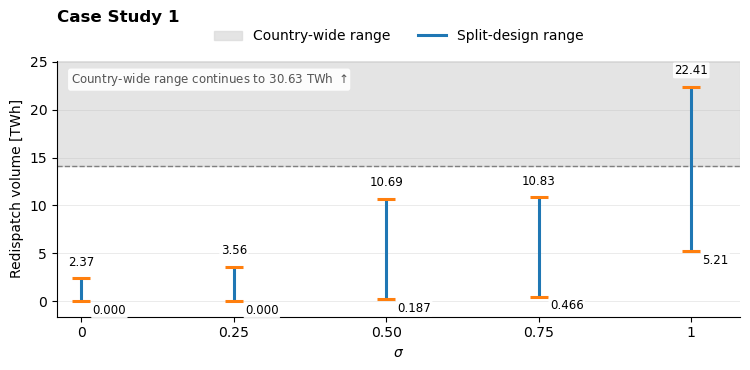

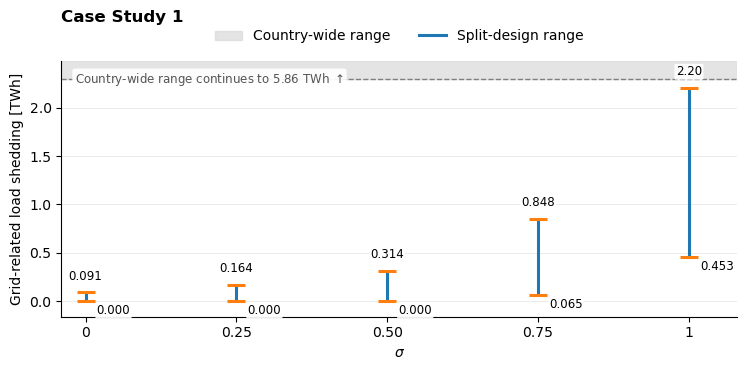

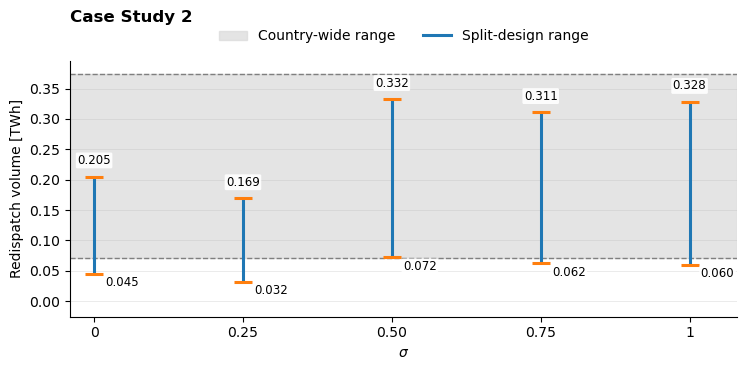

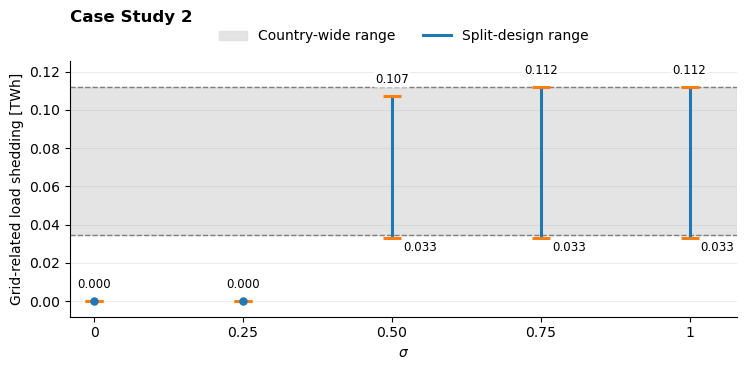

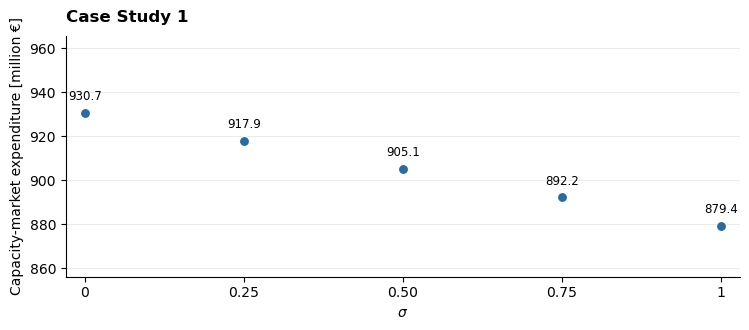

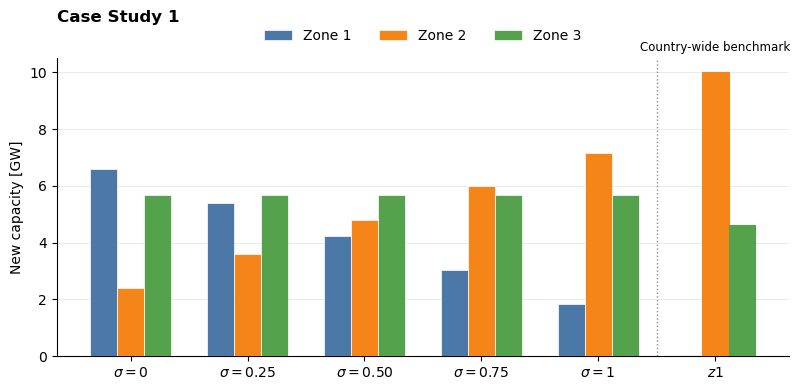

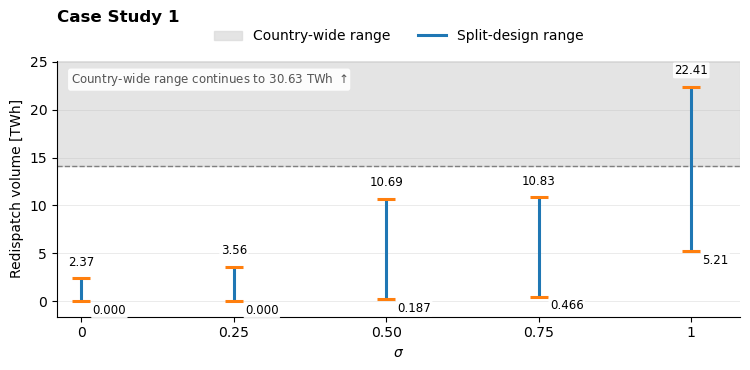

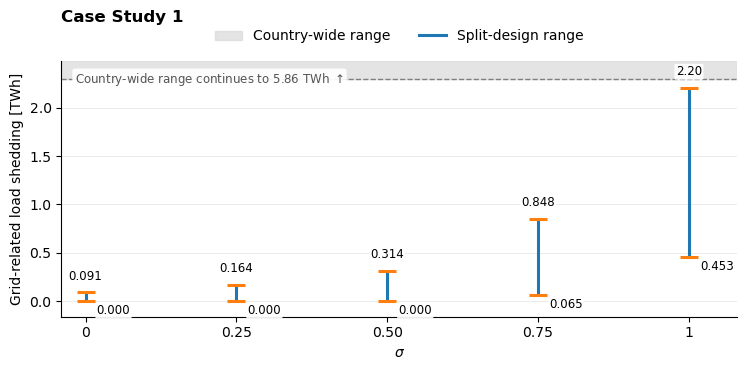

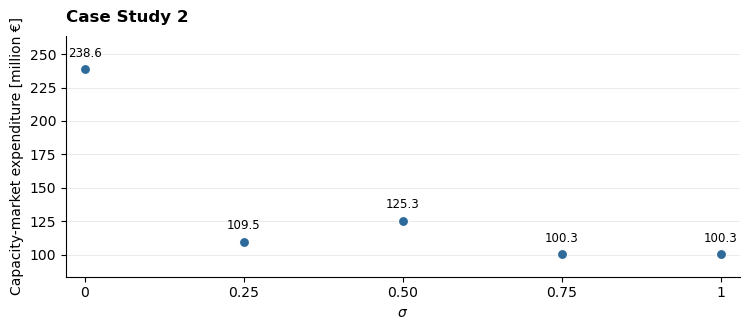

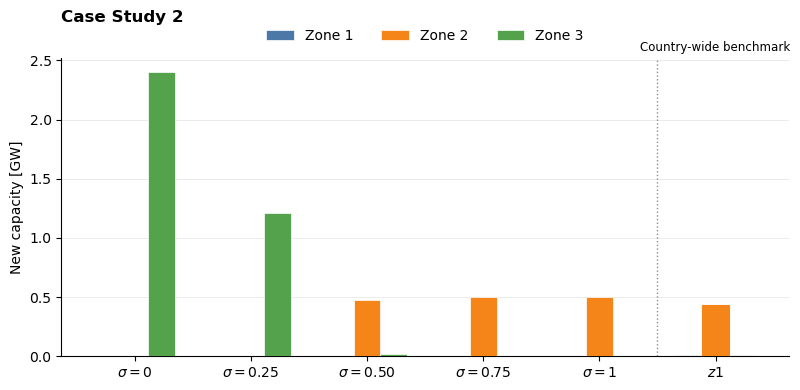

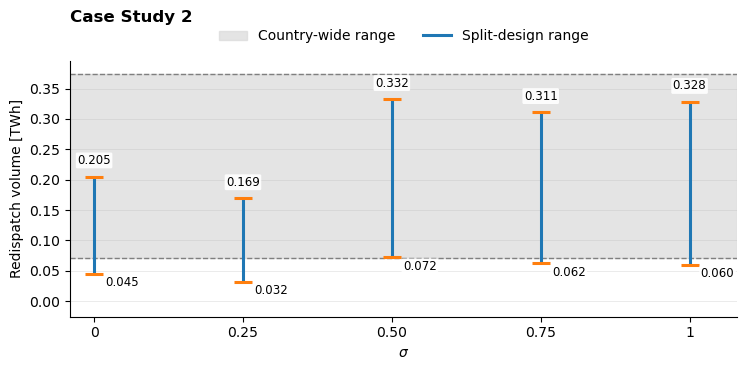

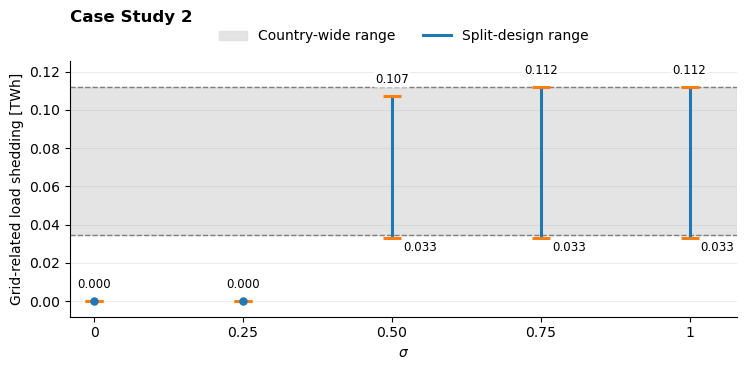

In [20]:
sigma_ticks_54 = np.array(
    [0.00, 0.25, 0.50, 0.75, 1.00]
)

sigma_labels_54 = [
    "0",
    "0.25",
    "0.50",
    "0.75",
    "1",
]


def case_slug_54(case_study):
    return (
        "cs1"
        if case_study == "Case Study 1"
        else "cs2"
    )


def set_sigma_axis_54(ax):
    ax.set_xticks(sigma_ticks_54)
    ax.set_xticklabels(sigma_labels_54)
    ax.set_xlim(-0.03, 1.03)
    ax.set_xlabel(r"$\sigma$")

zone_colors_54 = {
    1: "#4C78A8",
    2: "#F58518",
    3: "#54A24B",
}

expenditure_color_54 = "#2F6B9A"


# ============================================================
# 1. Capacity-market expenditure across sigma
# ============================================================

def plot_capacity_market_expenditure_54(
    case_study,
):
    data = (
        capacity_market_totals.loc[
            capacity_market_totals["case_study"]
            == case_study
        ]
        .sort_values("sigma")
        .copy()
    )

    x = data["sigma"].to_numpy(dtype=float)

    lower = (
        data["capacity_market_expenditure_min"]
        .to_numpy(dtype=float)
        / 1_000_000
    )

    upper = (
        data["capacity_market_expenditure_max"]
        .to_numpy(dtype=float)
        / 1_000_000
    )

    fig, ax = plt.subplots(
        figsize=(7.6, 3.4)
    )

    for sigma, low, high in zip(
        x,
        lower,
        upper,
    ):
        collapsed = np.isclose(
            low,
            high,
            atol=0.005,
        )

        if collapsed:
            # One discrete result at this sigma
            ax.scatter(
                sigma,
                high,
                s=52,
                color=expenditure_color_54,
                edgecolor="white",
                linewidth=0.8,
                zorder=3,
            )

            label_value = high

        else:
            # Genuine observed minimum–maximum range
            ax.vlines(
                sigma,
                low,
                high,
                linewidth=2.2,
                color=expenditure_color_54,
                zorder=2,
            )

            ax.scatter(
                [sigma, sigma],
                [low, high],
                marker="_",
                s=180,
                linewidths=2.2,
                color=expenditure_color_54,
                zorder=3,
            )

            label_value = high

        ax.annotate(
            f"{label_value:.1f}",
            (sigma, label_value),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8.5,
        )

    set_sigma_axis_54(ax)

    ax.set_ylabel(
        "Capacity-market expenditure [million €]"
    )

    ax.set_title(
        case_study,
        loc="left",
        fontweight="semibold",
        pad=10,
    )

    # Dot plots may use a focused y-axis because marker area
    # does not represent magnitude.
    value_min = float(lower.min())
    value_max = float(upper.max())

    padding = max(
        (value_max - value_min) * 0.12,
        value_max * 0.025,
        1.0,
    )

    ax.set_ylim(
        value_min - padding,
        value_max + 1.5 * padding,
    )

    style_axis(
        ax,
        grid_axis="y",
    )

    fig.tight_layout()

    save_section_figure(
        fig,
        (
            f"{case_slug_54(case_study)}"
            "_cross_zonal_capacity_market_expenditure"
        ),
    )

# ============================================================
# 2. New capacity by zone across sigma
# ============================================================

def plot_zonal_siting_54(
    case_study,
):
    split_data = (
        new_capacity_by_zone.loc[
            new_capacity_by_zone["case_study"]
            == case_study
        ]
        .sort_values(
            [
                "sigma",
                "zone",
            ]
        )
        .copy()
    )

    # Zonal investment should be fixed for each design point.
    split_data["range_mw"] = (
        split_data["new_capacity_max_mw"]
        - split_data["new_capacity_min_mw"]
    )

    varying_split = (
        split_data["range_mw"] > 0.01
    )

    if varying_split.any():
        raise ValueError(
            "Material variation found in zonal investment:\n"
            + split_data.loc[
                varying_split,
                [
                    "sigma",
                    "zone",
                    "new_capacity_min_mw",
                    "new_capacity_max_mw",
                ],
            ].to_string(index=False)
        )

    split_pivot = (
        split_data
        .pivot(
            index="sigma",
            columns="zone",
            values="new_capacity_max_mw",
        )
        .reindex(sigma_ticks_54)
        .fillna(0)
        / 1_000
    )

    # Add the country-wide design as one separate benchmark group.
    benchmark = (
        zone_siting.loc[
            (
                zone_siting["case_study"]
                == case_study
            )
            & (
                zone_siting["design"]
                == "Country-wide"
            )
        ]
        .copy()
    )

    benchmark["range_mw"] = (
        benchmark["max_mw"]
        - benchmark["min_mw"]
    )

    varying_benchmark = (
        benchmark["range_mw"] > 0.01
    )

    if varying_benchmark.any():
        raise ValueError(
            "Material variation found in the country-wide "
            "zonal benchmark:\n"
            + benchmark.loc[
                varying_benchmark,
                [
                    "zone",
                    "min_mw",
                    "max_mw",
                ],
            ].to_string(index=False)
        )

    benchmark_values = (
        benchmark
        .set_index("zone")["max_mw"]
        .reindex([1, 2, 3])
        .fillna(0)
        / 1_000
    )

    # Five split-design sigma values plus one z1 benchmark.
    group_positions = np.arange(6)

    group_labels = [
        r"$\sigma=0$",
        r"$\sigma=0.25$",
        r"$\sigma=0.50$",
        r"$\sigma=0.75$",
        r"$\sigma=1$",
        r"$z1$",
    ]

    bar_width = 0.23

    fig, ax = plt.subplots(
        figsize=(8.2, 4.0)
    )

    for zone_index, zone in enumerate(
        [1, 2, 3]
    ):
        offset = (
            zone_index - 1
        ) * bar_width

        split_values = (
            split_pivot[zone]
            .to_numpy(dtype=float)
            if zone in split_pivot.columns
            else np.zeros(5)
        )

        values = np.append(
            split_values,
            float(benchmark_values.loc[zone]),
        )

        bars = ax.bar(
            group_positions + offset,
            values,
            width=bar_width,
            color=zone_colors_54[zone],
            label=f"Zone {zone}",
            edgecolor="white",
            linewidth=0.5,
            zorder=3,
        )

        # Hatch only the country-wide benchmark bars.
        benchmark_bar = bars[-1]
        benchmark_bar.set_hatch("//")
        benchmark_bar.set_edgecolor(
            zone_colors_54[zone]
        )
        benchmark_bar.set_linewidth(0.8)

    # Visually separate the benchmark from the sigma values.
    ax.axvline(
        4.5,
        color="#8C8C8C",
        linestyle=":",
        linewidth=1.0,
        zorder=1,
    )

    ax.text(
        5,
        1.015,
        "Country-wide benchmark",
        transform=ax.get_xaxis_transform(),
        ha="center",
        va="bottom",
        fontsize=8.5,
    )

    ax.set_xticks(group_positions)
    ax.set_xticklabels(group_labels)

    ax.set_ylabel("New capacity [GW]")

    ax.set_title(
        case_study,
        loc="left",
        fontweight="semibold",
        pad=26,
    )

    ax.legend(
        frameon=False,
        ncol=3,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.01),
    )

    ax.set_ylim(
        bottom=0
    )

    style_axis(
        ax,
        grid_axis="y",
    )

    fig.tight_layout()

    save_section_figure(
        fig,
        (
            f"{case_slug_54(case_study)}"
            "_cross_zonal_new_capacity_by_zone"
        ),
    )


# ============================================================
# 3. Redispatch and load-shedding ranges across sigma
# ============================================================

def format_congestion_value_54(value):
    """Format TWh values without unnecessary decimals."""
    if abs(value) < 1:
        return f"{value:.3f}"

    return f"{value:.2f}"


def plot_congestion_range_54(
    case_study,
    metric,
    y_label,
    filename_suffix,
):
    required_columns = {
        "case_study",
        "design",
        "metric",
        "sigma",
        "min",
        "max",
    }

    missing_columns = (
        required_columns
        - set(congestion_with_countrywide.columns)
    )

    if missing_columns:
        raise KeyError(
            "congestion_with_countrywide is missing: "
            + ", ".join(sorted(missing_columns))
        )

    # --------------------------------------------------------
    # Split-design results
    # --------------------------------------------------------

    split = (
        congestion_with_countrywide.loc[
            (
                congestion_with_countrywide["case_study"]
                == case_study
            )
            & (
                congestion_with_countrywide["design"]
                == "Split"
            )
            & (
                congestion_with_countrywide["metric"]
                == metric
            ),
            [
                "sigma",
                "min",
                "max",
            ],
        ]
        .copy()
    )

    split["sigma"] = pd.to_numeric(
        split["sigma"],
        errors="coerce",
    )

    split["min"] = pd.to_numeric(
        split["min"],
        errors="coerce",
    )

    split["max"] = pd.to_numeric(
        split["max"],
        errors="coerce",
    )

    split = (
        split
        .dropna(
            subset=[
                "sigma",
                "min",
                "max",
            ]
        )
        .sort_values("sigma")
    )

    if split.empty:
        raise ValueError(
            f"No split-design results found for "
            f"{case_study}, {metric}."
        )

    # --------------------------------------------------------
    # Country-wide benchmark
    # --------------------------------------------------------

    benchmark_congestion = (
        congestion_with_countrywide.loc[
            (
                congestion_with_countrywide["case_study"]
                == case_study
            )
            & (
                congestion_with_countrywide["design"]
                == "Country-wide"
            )
            & (
                congestion_with_countrywide["metric"]
                == metric
            ),
            [
                "min",
                "max",
            ],
        ]
        .copy()
    )

    benchmark_congestion["min"] = pd.to_numeric(
        benchmark_congestion["min"],
        errors="coerce",
    )

    benchmark_congestion["max"] = pd.to_numeric(
        benchmark_congestion["max"],
        errors="coerce",
    )

    benchmark_congestion = benchmark_congestion.dropna(
        subset=[
            "min",
            "max",
        ]
    )

    if benchmark_congestion.empty:
        raise ValueError(
            f"No country-wide benchmark found for "
            f"{case_study}, {metric}."
        )

    # Convert MWh to TWh.
    x = split["sigma"].to_numpy(dtype=float)

    lower = (
        split["min"].to_numpy(dtype=float)
        / 1_000_000
    )

    upper = (
        split["max"].to_numpy(dtype=float)
        / 1_000_000
    )

    benchmark_low = (
        float(benchmark_congestion["min"].iloc[0])
        / 1_000_000
    )

    benchmark_high = (
        float(benchmark_congestion["max"].iloc[0])
        / 1_000_000
    )

    # --------------------------------------------------------
    # Determine whether the benchmark should be truncated
    # --------------------------------------------------------

    split_upper = float(upper.max())

    focused_upper = max(
        split_upper * 1.12,
        benchmark_low * 1.08,
        0.01,
    )

    # Show the entire country-wide range only if doing so does
    # not substantially enlarge the scale.
    benchmark_is_clipped = (
        benchmark_high
        > focused_upper * 1.12
    )

    if benchmark_is_clipped:
        plot_upper = focused_upper
    else:
        plot_upper = max(
            focused_upper,
            benchmark_high * 1.06,
        )

    # Small gap below zero for the lower endpoint labels.
    plot_lower = -0.065 * plot_upper

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(7.6, 3.8)
    )

    benchmark_colour = "#D9D9D9"
    benchmark_edge = "#7F7F7F"
    split_colour = "#1F77B4"
    endpoint_colour = "#FF7F0E"

    # --------------------------------------------------------
    # Country-wide reference range
    # --------------------------------------------------------

    visible_benchmark_high = min(
        benchmark_high,
        plot_upper,
    )

    ax.axhspan(
        benchmark_low,
        visible_benchmark_high,
        color=benchmark_colour,
        alpha=0.70,
        zorder=0,
    )

    ax.axhline(
        benchmark_low,
        linestyle="--",
        linewidth=1.0,
        color=benchmark_edge,
        zorder=1,
    )

    if not benchmark_is_clipped:
        ax.axhline(
            benchmark_high,
            linestyle="--",
            linewidth=1.0,
            color=benchmark_edge,
            zorder=1,
        )

    else:
        # The grey area reaching the top and this annotation
        # indicate that the benchmark continues beyond the axis.
        ax.text(
            0.02,
            0.96,
            (
                "Country-wide range continues to "
                f"{format_congestion_value_54(benchmark_high)} TWh "
                r"$\uparrow$"
            ),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8.5,
            color="#555555",
            bbox=dict(
                boxstyle="round,pad=0.22",
                facecolor="white",
                edgecolor="none",
                alpha=0.92,
            ),
            zorder=6,
        )

    # --------------------------------------------------------
    # Separate split-design ranges for each sigma
    # --------------------------------------------------------

    ax.vlines(
        x,
        lower,
        upper,
        linewidth=2.2,
        color=split_colour,
        zorder=3,
    )

    ax.scatter(
        x,
        lower,
        marker="_",
        s=180,
        linewidths=2.2,
        color=endpoint_colour,
        zorder=4,
    )

    ax.scatter(
        x,
        upper,
        marker="_",
        s=180,
        linewidths=2.2,
        color=endpoint_colour,
        zorder=4,
    )

    # Show one point where the minimum and maximum are equal.
    collapsed = np.isclose(
        lower,
        upper,
        atol=1e-6,
    )

    if collapsed.any():
        ax.scatter(
            x[collapsed],
            lower[collapsed],
            s=26,
            color=split_colour,
            zorder=5,
        )

    # --------------------------------------------------------
    # Endpoint labels
    # --------------------------------------------------------

    label_box = dict(
        boxstyle="round,pad=0.12",
        facecolor="white",
        edgecolor="none",
        alpha=0.92,
    )

    for sigma, low, high in zip(
        x,
        lower,
        upper,
    ):
        if np.isclose(
            low,
            high,
            atol=0.0005,
        ):
            ax.annotate(
                format_congestion_value_54(high),
                (sigma, high),
                xytext=(0, 7),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8.5,
                bbox=label_box,
                clip_on=False,
                zorder=6,
            )

        else:
            # Upper endpoint
            ax.annotate(
                format_congestion_value_54(high),
                (sigma, high),
                xytext=(0, 7),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8.5,
                bbox=label_box,
                clip_on=False,
                zorder=6,
            )

            # Lower endpoint: to the right and in the gap
            # between zero and the x-axis.
            ax.annotate(
                format_congestion_value_54(low),
                (sigma, low),
                xytext=(8, -2),
                textcoords="offset points",
                ha="left",
                va="top",
                fontsize=8.5,
                bbox=label_box,
                clip_on=False,
                zorder=6,
            )

    # --------------------------------------------------------
    # Axis formatting
    # --------------------------------------------------------

    sigma_ticks = np.array(
        [0.00, 0.25, 0.50, 0.75, 1.00]
    )

    sigma_labels = [
        "0",
        "0.25",
        "0.50",
        "0.75",
        "1",
    ]

    ax.set_xticks(sigma_ticks)
    ax.set_xticklabels(sigma_labels)

    # Extra room on the right for the lower label at sigma=1.
    ax.set_xlim(
        -0.04,
        1.08,
    )

    ax.set_ylim(
        plot_lower,
        plot_upper,
    )

    ax.set_xlabel(r"$\sigma$")
    ax.set_ylabel(y_label)

    ax.set_title(
        case_study,
        loc="left",
        fontweight="semibold",
        pad=28,
    )

    legend_handles = [
        Patch(
            facecolor=benchmark_colour,
            edgecolor=benchmark_colour,
            alpha=0.70,
            label="Country-wide range",
        ),
        Line2D(
            [0],
            [0],
            color=split_colour,
            linewidth=2.2,
            label="Split-design range",
        ),
    ]

    ax.legend(
        handles=legend_handles,
        frameon=False,
        ncol=2,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        alpha=0.25,
        linewidth=0.7,
    )

    ax.set_axisbelow(True)

    fig.tight_layout()

    save_section_figure(
        fig,
        (
            f"{case_slug_54(case_study)}_"
            f"{filename_suffix}"
        ),
    )


# ============================================================
# Generate the four congestion figures
# ============================================================

if make_plots:

    for case_study in [
        "Case Study 1",
        "Case Study 2",
    ]:

        plot_congestion_range_54(
            case_study=case_study,
            metric="redispatch_volume_mwh",
            y_label="Redispatch volume [TWh]",
            filename_suffix=(
                "cross_zonal_redispatch_range"
            ),
        )

        plot_congestion_range_54(
            case_study=case_study,
            metric=(
                "grid_related_load_shedding_mwh"
            ),
            y_label=(
                "Grid-related load shedding [TWh]"
            ),
            filename_suffix=(
                "cross_zonal_grid_load_shedding_range"
            ),
        )

# ============================================================
# Generate the Section 5.4 figures
# ============================================================

if make_plots:

    for case_study in [
        "Case Study 1",
        "Case Study 2",
    ]:

        plot_capacity_market_expenditure_54(
            case_study
        )

        plot_zonal_siting_54(
            case_study
        )

        plot_congestion_range_54(
            case_study=case_study,
            metric="redispatch_volume_mwh",
            y_label="Redispatch volume [TWh]",
            filename_suffix=(
                "cross_zonal_redispatch_range"
            ),
        )

        plot_congestion_range_54(
            case_study=case_study,
            metric=(
                "grid_related_load_shedding_mwh"
            ),
            y_label=(
                "Grid-related load shedding [TWh]"
            ),
            filename_suffix=(
                "cross_zonal_grid_load_shedding_range"
            ),
        )

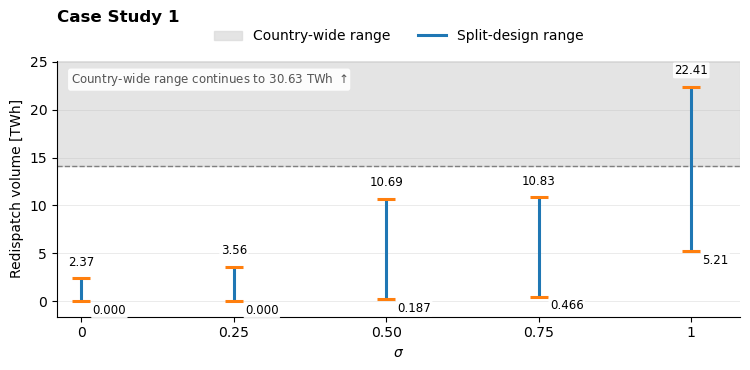

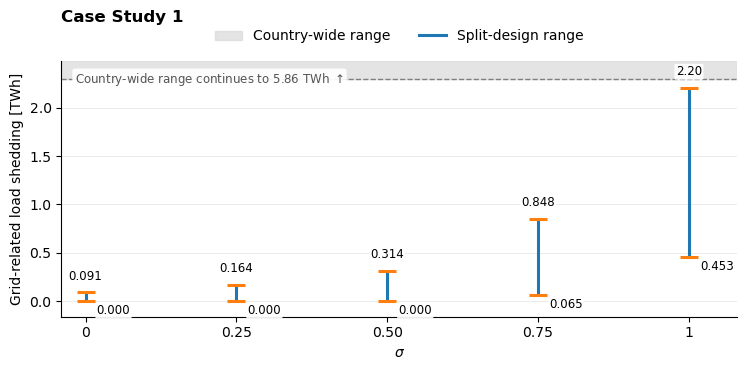

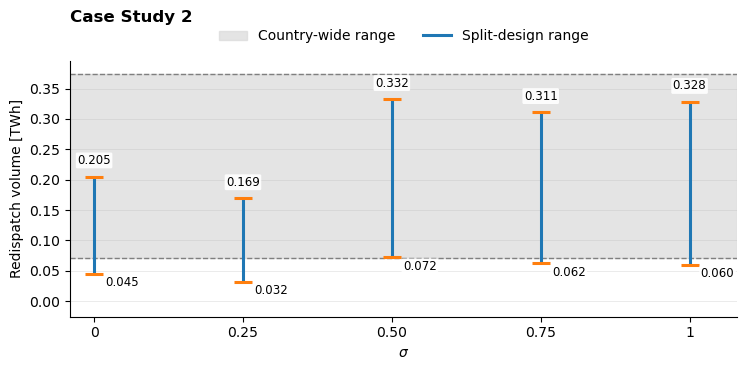

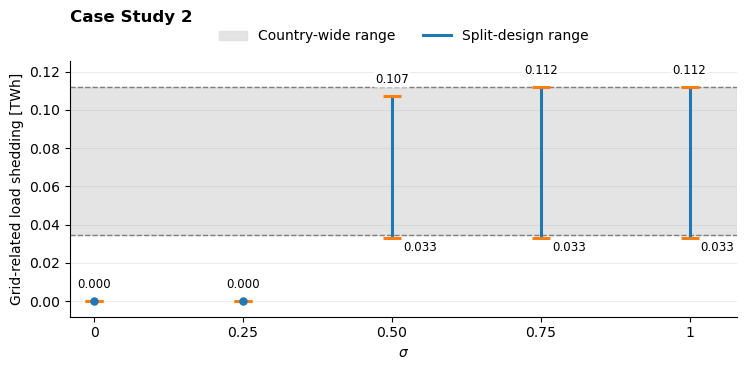

In [21]:
def format_congestion_value_54(value):
    """Format TWh values without unnecessary decimals."""
    if abs(value) < 1:
        return f"{value:.3f}"

    return f"{value:.2f}"


def plot_congestion_range_54(
    case_study,
    metric,
    y_label,
    filename_suffix,
):
    required_columns = {
        "case_study",
        "design",
        "metric",
        "sigma",
        "min",
        "max",
    }

    missing_columns = (
        required_columns
        - set(congestion_with_countrywide.columns)
    )

    if missing_columns:
        raise KeyError(
            "congestion_with_countrywide is missing: "
            + ", ".join(sorted(missing_columns))
        )

    # --------------------------------------------------------
    # Split-design results
    # --------------------------------------------------------

    split = (
        congestion_with_countrywide.loc[
            (
                congestion_with_countrywide["case_study"]
                == case_study
            )
            & (
                congestion_with_countrywide["design"]
                == "Split"
            )
            & (
                congestion_with_countrywide["metric"]
                == metric
            ),
            [
                "sigma",
                "min",
                "max",
            ],
        ]
        .copy()
    )

    split["sigma"] = pd.to_numeric(
        split["sigma"],
        errors="coerce",
    )

    split["min"] = pd.to_numeric(
        split["min"],
        errors="coerce",
    )

    split["max"] = pd.to_numeric(
        split["max"],
        errors="coerce",
    )

    split = (
        split
        .dropna(
            subset=[
                "sigma",
                "min",
                "max",
            ]
        )
        .sort_values("sigma")
    )

    if split.empty:
        raise ValueError(
            f"No split-design results found for "
            f"{case_study}, {metric}."
        )

    # --------------------------------------------------------
    # Country-wide benchmark
    # --------------------------------------------------------

    benchmark_congestion = (
        congestion_with_countrywide.loc[
            (
                congestion_with_countrywide["case_study"]
                == case_study
            )
            & (
                congestion_with_countrywide["design"]
                == "Country-wide"
            )
            & (
                congestion_with_countrywide["metric"]
                == metric
            ),
            [
                "min",
                "max",
            ],
        ]
        .copy()
    )

    benchmark_congestion["min"] = pd.to_numeric(
        benchmark_congestion["min"],
        errors="coerce",
    )

    benchmark_congestion["max"] = pd.to_numeric(
        benchmark_congestion["max"],
        errors="coerce",
    )

    benchmark_congestion = benchmark_congestion.dropna(
        subset=[
            "min",
            "max",
        ]
    )

    if benchmark_congestion.empty:
        raise ValueError(
            f"No country-wide benchmark found for "
            f"{case_study}, {metric}."
        )

    # Convert MWh to TWh.
    x = split["sigma"].to_numpy(dtype=float)

    lower = (
        split["min"].to_numpy(dtype=float)
        / 1_000_000
    )

    upper = (
        split["max"].to_numpy(dtype=float)
        / 1_000_000
    )

    benchmark_low = (
        float(benchmark_congestion["min"].iloc[0])
        / 1_000_000
    )

    benchmark_high = (
        float(benchmark_congestion["max"].iloc[0])
        / 1_000_000
    )

    # --------------------------------------------------------
    # Determine whether the benchmark should be truncated
    # --------------------------------------------------------

    split_upper = float(upper.max())

    focused_upper = max(
        split_upper * 1.12,
        benchmark_low * 1.08,
        0.01,
    )

    # Show the entire country-wide range only if doing so does
    # not substantially enlarge the scale.
    benchmark_is_clipped = (
        benchmark_high
        > focused_upper * 1.12
    )

    if benchmark_is_clipped:
        plot_upper = focused_upper
    else:
        plot_upper = max(
            focused_upper,
            benchmark_high * 1.06,
        )

    # Small gap below zero for the lower endpoint labels.
    plot_lower = -0.065 * plot_upper

    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(7.6, 3.8)
    )

    benchmark_colour = "#D9D9D9"
    benchmark_edge = "#7F7F7F"
    split_colour = "#1F77B4"
    endpoint_colour = "#FF7F0E"

    # --------------------------------------------------------
    # Country-wide reference range
    # --------------------------------------------------------

    visible_benchmark_high = min(
        benchmark_high,
        plot_upper,
    )

    ax.axhspan(
        benchmark_low,
        visible_benchmark_high,
        color=benchmark_colour,
        alpha=0.70,
        zorder=0,
    )

    ax.axhline(
        benchmark_low,
        linestyle="--",
        linewidth=1.0,
        color=benchmark_edge,
        zorder=1,
    )

    if not benchmark_is_clipped:
        ax.axhline(
            benchmark_high,
            linestyle="--",
            linewidth=1.0,
            color=benchmark_edge,
            zorder=1,
        )

    else:
        # The grey area reaching the top and this annotation
        # indicate that the benchmark continues beyond the axis.
        ax.text(
            0.02,
            0.96,
            (
                "Country-wide range continues to "
                f"{format_congestion_value_54(benchmark_high)} TWh "
                r"$\uparrow$"
            ),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=8.5,
            color="#555555",
            bbox=dict(
                boxstyle="round,pad=0.22",
                facecolor="white",
                edgecolor="none",
                alpha=0.92,
            ),
            zorder=6,
        )

    # --------------------------------------------------------
    # Separate split-design ranges for each sigma
    # --------------------------------------------------------

    ax.vlines(
        x,
        lower,
        upper,
        linewidth=2.2,
        color=split_colour,
        zorder=3,
    )

    ax.scatter(
        x,
        lower,
        marker="_",
        s=180,
        linewidths=2.2,
        color=endpoint_colour,
        zorder=4,
    )

    ax.scatter(
        x,
        upper,
        marker="_",
        s=180,
        linewidths=2.2,
        color=endpoint_colour,
        zorder=4,
    )

    # Show one point where the minimum and maximum are equal.
    collapsed = np.isclose(
        lower,
        upper,
        atol=1e-6,
    )

    if collapsed.any():
        ax.scatter(
            x[collapsed],
            lower[collapsed],
            s=26,
            color=split_colour,
            zorder=5,
        )

    # --------------------------------------------------------
    # Endpoint labels
    # --------------------------------------------------------

    label_box = dict(
        boxstyle="round,pad=0.12",
        facecolor="white",
        edgecolor="none",
        alpha=0.92,
    )

    for sigma, low, high in zip(
        x,
        lower,
        upper,
    ):
        if np.isclose(
            low,
            high,
            atol=0.0005,
        ):
            ax.annotate(
                format_congestion_value_54(high),
                (sigma, high),
                xytext=(0, 7),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8.5,
                bbox=label_box,
                clip_on=False,
                zorder=6,
            )

        else:
            # Upper endpoint
            ax.annotate(
                format_congestion_value_54(high),
                (sigma, high),
                xytext=(0, 7),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8.5,
                bbox=label_box,
                clip_on=False,
                zorder=6,
            )

            # Lower endpoint: to the right and in the gap
            # between zero and the x-axis.
            ax.annotate(
                format_congestion_value_54(low),
                (sigma, low),
                xytext=(8, -2),
                textcoords="offset points",
                ha="left",
                va="top",
                fontsize=8.5,
                bbox=label_box,
                clip_on=False,
                zorder=6,
            )

    # --------------------------------------------------------
    # Axis formatting
    # --------------------------------------------------------

    sigma_ticks = np.array(
        [0.00, 0.25, 0.50, 0.75, 1.00]
    )

    sigma_labels = [
        "0",
        "0.25",
        "0.50",
        "0.75",
        "1",
    ]

    ax.set_xticks(sigma_ticks)
    ax.set_xticklabels(sigma_labels)

    # Extra room on the right for the lower label at sigma=1.
    ax.set_xlim(
        -0.04,
        1.08,
    )

    ax.set_ylim(
        plot_lower,
        plot_upper,
    )

    ax.set_xlabel(r"$\sigma$")
    ax.set_ylabel(y_label)

    ax.set_title(
        case_study,
        loc="left",
        fontweight="semibold",
        pad=28,
    )

    legend_handles = [
        Patch(
            facecolor=benchmark_colour,
            edgecolor=benchmark_colour,
            alpha=0.70,
            label="Country-wide range",
        ),
        Line2D(
            [0],
            [0],
            color=split_colour,
            linewidth=2.2,
            label="Split-design range",
        ),
    ]

    ax.legend(
        handles=legend_handles,
        frameon=False,
        ncol=2,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        alpha=0.25,
        linewidth=0.7,
    )

    ax.set_axisbelow(True)

    fig.tight_layout()

    save_section_figure(
        fig,
        (
            f"{case_slug_54(case_study)}_"
            f"{filename_suffix}"
        ),
    )


# ============================================================
# Generate the four congestion figures
# ============================================================

if make_plots:

    for case_study in [
        "Case Study 1",
        "Case Study 2",
    ]:

        plot_congestion_range_54(
            case_study=case_study,
            metric="redispatch_volume_mwh",
            y_label="Redispatch volume [TWh]",
            filename_suffix=(
                "cross_zonal_redispatch_range"
            ),
        )

        plot_congestion_range_54(
            case_study=case_study,
            metric=(
                "grid_related_load_shedding_mwh"
            ),
            y_label=(
                "Grid-related load shedding [TWh]"
            ),
            filename_suffix=(
                "cross_zonal_grid_load_shedding_range"
            ),
        )

In [22]:

cross_zonal_output_files = sorted(
    path.name
    for path in output_dir.glob(
        "cross_zonal_*.csv"
    )
)

print("Section 5.4 output files:")
for file_name in cross_zonal_output_files:
    print("-", file_name)


Section 5.4 output files:
- cross_zonal_capacity_availability_by_zone.csv
- cross_zonal_capacity_market_totals.csv
- cross_zonal_congestion_monotonicity.csv
- cross_zonal_congestion_ranges.csv
- cross_zonal_congestion_with_countrywide.csv
- cross_zonal_distance_to_countrywide.csv
- cross_zonal_file_sources.csv
- cross_zonal_new_capacity_by_node.csv
- cross_zonal_new_capacity_by_zone.csv
- cross_zonal_node_change_vs_sigma0.csv
- cross_zonal_obligations_by_zone.csv
- cross_zonal_procurement_by_source.csv
- cross_zonal_siting_concentration.csv
- cross_zonal_system_balance.csv
- cross_zonal_transfer_limits.csv
- cross_zonal_zero_shedding_counts.csv
- cross_zonal_zero_shedding_with_countrywide.csv
- cross_zonal_zonal_market_results.csv


In [23]:
created_files = sorted(
    path.name
    for path in output_dir.iterdir()
    if path.is_file()
)

print("Created files:")
for file_name in created_files:
    print("-", file_name)

Created files:
- capacity_detail_file_sources.csv
- capacity_market_cost_range.png
- capacity_overprocurement.csv
- capacity_price_source_indicator.csv
- capacity_procurement_by_market_zone_and_source.csv
- capacity_procurement_by_physical_zone_and_source.csv
- capacity_procurement_by_zone.csv
- capacity_procurement_main.csv
- congestion_outcomes_long.csv
- congestion_outcomes_summary.csv
- countrywide_vs_split_comparison.csv
- cross_zonal_capacity_availability_by_zone.csv
- cross_zonal_capacity_market_totals.csv
- cross_zonal_congestion_monotonicity.csv
- cross_zonal_congestion_ranges.csv
- cross_zonal_congestion_with_countrywide.csv
- cross_zonal_distance_to_countrywide.csv
- cross_zonal_file_sources.csv
- cross_zonal_new_capacity_by_node.csv
- cross_zonal_new_capacity_by_zone.csv
- cross_zonal_node_change_vs_sigma0.csv
- cross_zonal_obligations_by_zone.csv
- cross_zonal_procurement_by_source.csv
- cross_zonal_siting_concentration.csv
- cross_zonal_system_balance.csv
- cross_zonal_tr

## 5.5 analysis: network mechanisms behind the congestion outcomes

In [ ]:
network_scenarios_55 = {
    "nl34_z1_sigma0": {
        "case_study": "Case Study 1",
        "design": "Country-wide",
        "sigma": np.nan,
    },
    "nl34_z3_sigma0": {
        "case_study": "Case Study 1",
        "design": "Split",
        "sigma": 0.00,
    },
    "nl34_z3_sigma25": {
        "case_study": "Case Study 1",
        "design": "Split",
        "sigma": 0.25,
    },
    "nl34_z3_sigma50": {
        "case_study": "Case Study 1",
        "design": "Split",
        "sigma": 0.50,
    },
    "nl34_z3_sigma75": {
        "case_study": "Case Study 1",
        "design": "Split",
        "sigma": 0.75,
    },
    "nl34_z3_sigma100": {
        "case_study": "Case Study 1",
        "design": "Split",
        "sigma": 1.00,
    },
    "cs2_nl34_z1_sigma0": {
        "case_study": "Case Study 2",
        "design": "Country-wide",
        "sigma": np.nan,
    },
    "cs2_nl34_z3_sigma0": {
        "case_study": "Case Study 2",
        "design": "Split",
        "sigma": 0.00,
    },
    "cs2_nl34_z3_sigma25": {
        "case_study": "Case Study 2",
        "design": "Split",
        "sigma": 0.25,
    },
    "cs2_nl34_z3_sigma50": {
        "case_study": "Case Study 2",
        "design": "Split",
        "sigma": 0.50,
    },
    "cs2_nl34_z3_sigma75": {
        "case_study": "Case Study 2",
        "design": "Split",
        "sigma": 0.75,
    },
    "cs2_nl34_z3_sigma100": {
        "case_study": "Case Study 2",
        "design": "Split",
        "sigma": 1.00,
    },
}


def normalise_line_id_55(value):
    value_string = str(value).strip()

    if re.fullmatch(r"-?\d+\.0", value_string):
        return str(int(float(value_string)))

    return value_string


def numeric_55(frame, columns):
    frame = frame.copy()

    for column in columns:
        if column in frame.columns:
            frame[column] = pd.to_numeric(
                frame[column],
                errors="coerce",
            )

    return frame


line_run_frames_55 = []
line_scenario_frames_55 = []
event_frames_55 = []
investment_frames_55 = []
network_source_rows_55 = []

for scenario, meta in network_scenarios_55.items():
    print("Processing:", scenario)

    summary, summary_source = merge_summary_with_reruns(
        scenario
    )
    flows, flow_source = load_detail_with_optional_rerun(
        "line_flows",
        scenario,
    )
    curtailment, curtailment_source = (
        load_detail_with_optional_rerun(
            "curtailment",
            scenario,
        )
    )
    investment, investment_source = (
        load_detail_with_optional_rerun(
            "investment",
            scenario,
        )
    )

    if summary is None or flows is None:
        print("  Missing summary or line-flow file; skipped.")
        continue

    flows = numeric_55(
        flows,
        [
            "run_id",
            "t",
            "market_flow",
            "final_flow",
            "Fmax",
            "market_utilization",
            "final_utilization",
            "market_overload",
        ],
    )

    flows["line"] = (
        flows["line"]
        .map(normalise_line_id_55)
    )

    flows["positive_overload_mw"] = np.maximum(
        flows["market_flow"] - flows["Fmax"],
        0.0,
    )

    flows["negative_overload_mw"] = np.maximum(
        -flows["market_flow"] - flows["Fmax"],
        0.0,
    )

    flows["is_overloaded"] = (
        flows["market_overload"] > 1e-4
    )

    # Grid-related load shedding by run and representative timestep.
    if curtailment is not None and not curtailment.empty:
        curtailment = numeric_55(
            curtailment,
            [
                "run_id",
                "t",
                "curtailment",
            ],
        )

        event_curtailment = (
            curtailment
            .groupby(
                [
                    "run_id",
                    "t",
                ],
                as_index=False,
            )
            .agg(
                grid_load_shedding_mw=(
                    "curtailment",
                    "sum",
                )
            )
        )
    else:
        event_curtailment = pd.DataFrame(
            columns=[
                "run_id",
                "t",
                "grid_load_shedding_mw",
            ]
        )

    flows = flows.merge(
        event_curtailment,
        on=[
            "run_id",
            "t",
        ],
        how="left",
    )

    flows["grid_load_shedding_mw"] = (
        flows["grid_load_shedding_mw"]
        .fillna(0.0)
    )

    flows["overload_during_shedding_index"] = np.where(
        flows["grid_load_shedding_mw"] > zero_tolerance,
        flows["market_overload"],
        0.0,
    )

    # This is an association measure. The same shedding event may be
    # associated with more than one overloaded line and is not attributed.
    flows["shedding_associated_with_overload_mw"] = np.where(
        flows["is_overloaded"],
        flows["grid_load_shedding_mw"],
        0.0,
    )

    line_run = (
        flows
        .groupby(
            [
                "run_id",
                "line",
            ],
            as_index=False,
        )
        .agg(
            total_overload_index=(
                "market_overload",
                "sum",
            ),
            positive_overload_index=(
                "positive_overload_mw",
                "sum",
            ),
            negative_overload_index=(
                "negative_overload_mw",
                "sum",
            ),
            maximum_overload_mw=(
                "market_overload",
                "max",
            ),
            overloaded_run_hours=(
                "is_overloaded",
                "sum",
            ),
            maximum_market_utilization=(
                "market_utilization",
                "max",
            ),
            overload_during_shedding_index=(
                "overload_during_shedding_index",
                "sum",
            ),
            shedding_associated_with_overload_mw=(
                "shedding_associated_with_overload_mw",
                "sum",
            ),
        )
    )

    summary_for_merge = summary[
        [
            "run_id",
            "rd_volume",
            "curtailment",
        ]
    ].copy()

    summary_for_merge = numeric_55(
        summary_for_merge,
        [
            "run_id",
            "rd_volume",
            "curtailment",
        ],
    )

    line_run = line_run.merge(
        summary_for_merge,
        on="run_id",
        how="left",
    )

    line_run["scenario"] = scenario
    line_run["case_study"] = meta["case_study"]
    line_run["design"] = meta["design"]
    line_run["sigma"] = meta["sigma"]

    line_run_frames_55.append(line_run)

    overloaded_only = flows.loc[
        flows["is_overloaded"]
    ].copy()

    if overloaded_only.empty:
        line_scenario = pd.DataFrame(
            {
                "line": flows["line"].drop_duplicates(),
            }
        )

        for column in [
            "total_overload_index",
            "maximum_overload_mw",
            "overloaded_run_hours",
            "representative_timesteps_ever_overloaded",
            "runs_with_overload",
            "overload_during_shedding_index",
            "shedding_associated_with_overload_mw",
            "maximum_market_utilization",
        ]:
            line_scenario[column] = 0.0
    else:
        line_scenario = (
            flows
            .groupby(
                "line",
                as_index=False,
            )
            .agg(
                total_overload_index=(
                    "market_overload",
                    "sum",
                ),
                maximum_overload_mw=(
                    "market_overload",
                    "max",
                ),
                overloaded_run_hours=(
                    "is_overloaded",
                    "sum",
                ),
                overload_during_shedding_index=(
                    "overload_during_shedding_index",
                    "sum",
                ),
                shedding_associated_with_overload_mw=(
                    "shedding_associated_with_overload_mw",
                    "sum",
                ),
                maximum_market_utilization=(
                    "market_utilization",
                    "max",
                ),
            )
        )

        distinct_times = (
            overloaded_only
            .groupby("line")["t"]
            .nunique()
            .rename(
                "representative_timesteps_ever_overloaded"
            )
        )

        distinct_runs = (
            overloaded_only
            .groupby("line")["run_id"]
            .nunique()
            .rename("runs_with_overload")
        )

        line_scenario = (
            line_scenario
            .merge(
                distinct_times,
                on="line",
                how="left",
            )
            .merge(
                distinct_runs,
                on="line",
                how="left",
            )
        )

    line_scenario["scenario"] = scenario
    line_scenario["case_study"] = meta["case_study"]
    line_scenario["design"] = meta["design"]
    line_scenario["sigma"] = meta["sigma"]
    line_scenario["runs_analysed"] = (
        summary["run_id"].nunique()
    )

    total_overload = (
        line_scenario["total_overload_index"].sum()
    )

    line_scenario = line_scenario.sort_values(
        "total_overload_index",
        ascending=False,
    ).reset_index(drop=True)

    line_scenario["rank_in_scenario"] = (
        np.arange(len(line_scenario)) + 1
    )

    line_scenario["share_of_scenario_overload"] = np.where(
        total_overload > zero_tolerance,
        line_scenario["total_overload_index"]
        / total_overload,
        0.0,
    )

    line_scenario_frames_55.append(line_scenario)

    # Event-level totals used later to select representative hours.
    event_totals = (
        flows
        .groupby(
            [
                "run_id",
                "t",
            ],
            as_index=False,
        )
        .agg(
            total_market_overload_index=(
                "market_overload",
                "sum",
            ),
            maximum_line_overload_mw=(
                "market_overload",
                "max",
            ),
            overloaded_lines=(
                "is_overloaded",
                "sum",
            ),
            grid_load_shedding_mw=(
                "grid_load_shedding_mw",
                "max",
            ),
        )
    )

    event_totals["scenario"] = scenario
    event_totals["case_study"] = meta["case_study"]
    event_totals["design"] = meta["design"]
    event_totals["sigma"] = meta["sigma"]

    event_frames_55.append(event_totals)

    if investment is not None and not investment.empty:
        investment = numeric_55(
            investment,
            [
                "run_id",
                "c",
            ],
        )

        investment_by_bus = (
            investment
            .groupby(
                [
                    "run_id",
                    "bus",
                ],
                as_index=False,
            )
            .agg(
                new_capacity_mw=(
                    "c",
                    "sum",
                )
            )
        )

        investment_by_bus["scenario"] = scenario
        investment_by_bus["case_study"] = meta["case_study"]
        investment_by_bus["design"] = meta["design"]
        investment_by_bus["sigma"] = meta["sigma"]

        investment_frames_55.append(
            investment_by_bus
        )

    network_source_rows_55.append(
        {
            "scenario": scenario,
            "case_study": meta["case_study"],
            "design": meta["design"],
            "sigma": meta["sigma"],
            "summary_file": str(
                summary_source["base"]
            ),
            "line_flow_file": str(
                flow_source["base"]
            ),
            "curtailment_file": str(
                curtailment_source["base"]
                if curtailment_source is not None
                else ""
            ),
            "investment_file": str(
                investment_source["base"]
                if investment_source is not None
                else ""
            ),
        }
    )

    del flows
    del curtailment
    del investment


line_run_metrics_55 = pd.concat(
    line_run_frames_55,
    ignore_index=True,
)

line_scenario_metrics_55 = pd.concat(
    line_scenario_frames_55,
    ignore_index=True,
)

network_events_55 = pd.concat(
    event_frames_55,
    ignore_index=True,
)

network_investment_55 = pd.concat(
    investment_frames_55,
    ignore_index=True,
)

network_sources_55 = pd.DataFrame(
    network_source_rows_55
)

# Share of overload represented by the five highest-ranked lines.
top_five_share_55 = (
    line_scenario_metrics_55.loc[
        line_scenario_metrics_55[
            "rank_in_scenario"
        ] <= 5
    ]
    .groupby(
        [
            "scenario",
            "case_study",
            "design",
            "sigma",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        top_five_overload_share=(
            "share_of_scenario_overload",
            "sum",
        ),
        total_overload_index_top_five=(
            "total_overload_index",
            "sum",
        ),
    )
)

# Cross-scenario recurrence and importance by case study.
line_case_ranking_55 = (
    line_scenario_metrics_55
    .groupby(
        [
            "case_study",
            "line",
        ],
        as_index=False,
    )
    .agg(
        total_overload_index=(
            "total_overload_index",
            "sum",
        ),
        maximum_overload_mw=(
            "maximum_overload_mw",
            "max",
        ),
        overloaded_run_hours=(
            "overloaded_run_hours",
            "sum",
        ),
        runs_with_overload=(
            "runs_with_overload",
            "sum",
        ),
        scenarios_with_overload=(
            "total_overload_index",
            lambda values: int(
                (values > zero_tolerance).sum()
            ),
        ),
        overload_during_shedding_index=(
            "overload_during_shedding_index",
            "sum",
        ),
        shedding_associated_with_overload_mw=(
            "shedding_associated_with_overload_mw",
            "sum",
        ),
    )
)

line_case_ranking_55["rank_by_overload"] = (
    line_case_ranking_55
    .groupby("case_study")[
        "total_overload_index"
    ]
    .rank(
        method="first",
        ascending=False,
    )
    .astype(int)
)

line_case_ranking_55["rank_by_shedding_association"] = (
    line_case_ranking_55
    .groupby("case_study")[
        "shedding_associated_with_overload_mw"
    ]
    .rank(
        method="first",
        ascending=False,
    )
    .astype(int)
)

line_scenario_metrics_55.to_csv(
    output_dir / "network_line_metrics_by_scenario.csv",
    index=False,
)

line_run_metrics_55.to_csv(
    output_dir / "network_line_metrics_by_run.csv",
    index=False,
)

line_case_ranking_55.to_csv(
    output_dir / "network_line_ranking_by_case.csv",
    index=False,
)

top_five_share_55.to_csv(
    output_dir / "network_top_five_overload_share.csv",
    index=False,
)

network_events_55.to_csv(
    output_dir / "network_event_totals.csv",
    index=False,
)

network_investment_55.to_csv(
    output_dir / "network_investment_by_bus_and_run.csv",
    index=False,
)

network_sources_55.to_csv(
    output_dir / "network_file_sources.csv",
    index=False,
)

display(
    line_case_ranking_55.loc[
        line_case_ranking_55[
            "rank_by_overload"
        ] <= 10
    ]
    .sort_values(
        [
            "case_study",
            "rank_by_overload",
        ]
    )
)

display(top_five_share_55)


Processing: nl34_z1_sigma0
Processing: nl34_z3_sigma0
Processing: nl34_z3_sigma25
Processing: nl34_z3_sigma50
Processing: nl34_z3_sigma75
Processing: nl34_z3_sigma100
Processing: cs2_nl34_z1_sigma0
Processing: cs2_nl34_z3_sigma0


C:\Users\Alex\AppData\Local\Temp\ipykernel_17972\2527563773.py:204: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0.0)


Processing: cs2_nl34_z3_sigma25


C:\Users\Alex\AppData\Local\Temp\ipykernel_17972\2527563773.py:204: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(0.0)


Processing: cs2_nl34_z3_sigma50
Processing: cs2_nl34_z3_sigma75
Processing: cs2_nl34_z3_sigma100


,case_study,line,total_overload_index,maximum_overload_mw,overloaded_run_hours,runs_with_overload,scenarios_with_overload,overload_during_shedding_index,shedding_associated_with_overload_mw,rank_by_overload,rank_by_shedding_association
19,Case Study 1,26,1.266630e+07,3892.117887,10308,368.0,6,8.678586e+06,6.871878e+06,1,2
20,Case Study 1,27,1.191503e+07,4118.173815,9063,383.0,6,8.682800e+06,6.803805e+06,2,3
27,Case Study 1,34,1.178067e+07,2254.463841,16242,388.0,6,5.923877e+06,7.009558e+06,3,1
3,Case Study 1,11,6.810931e+06,1562.687599,14359,370.0,6,3.420615e+06,6.786120e+06,4,4
6,Case Study 1,14,6.514134e+06,1543.900098,13201,370.0,6,3.388051e+06,6.763608e+06,5,5
37,Case Study 1,7,1.938945e+06,1034.283546,8026,277.0,6,8.697657e+05,4.922186e+06,6,6
4,Case Study 1,12,1.867956e+06,1204.889803,7402,390.0,6,8.295603e+05,4.829456e+06,7,7
38,Case Study 1,8,1.047950e+06,751.676726,5057,337.0,6,2.307792e+05,8.239437e+05,8,15
36,Case Study 1,6,4.170893e+05,974.477355,1343,76.0,3,2.960744e+05,1.326148e+06,9,11
1,Case Study 1,1,2.980454e+05,708.783601,1262,103.0,6,2.646418e+05,2.673450e+06,10,8


,scenario,case_study,design,sigma,top_five_overload_share,total_overload_index_top_five
0,cs2_nl34_z1_sigma0,Case Study 2,Country-wide,NaN,0.895122,1.696416e+05
1,cs2_nl34_z3_sigma0,Case Study 2,Split,0.00,1.000000,1.305328e+05
2,cs2_nl34_z3_sigma100,Case Study 2,Split,1.00,0.892224,1.312815e+05
3,cs2_nl34_z3_sigma25,Case Study 2,Split,0.25,1.000000,1.145716e+05
4,cs2_nl34_z3_sigma50,Case Study 2,Split,0.50,0.906251,1.509160e+05
5,cs2_nl34_z3_sigma75,Case Study 2,Split,0.75,0.894015,1.411710e+05
6,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,0.907890,3.272421e+07
7,nl34_z3_sigma0,Case Study 1,Split,0.00,0.680699,1.095021e+05
8,nl34_z3_sigma100,Case Study 1,Split,1.00,0.889397,1.093618e+07
9,nl34_z3_sigma25,Case Study 1,Split,0.25,0.837639,5.821054e+05


### PTDF structure and descriptive investment associations

In [ ]:
ptdf_candidates_55 = [
    path
    for path in all_csvs
    if path.name == "nl34_ptdf_matrix.csv"
]

if not ptdf_candidates_55:
    fallback_ptdf_55 = (
        project_root / "nl34_ptdf_matrix.csv"
    )

    if fallback_ptdf_55.exists():
        ptdf_candidates_55 = [
            fallback_ptdf_55
        ]

if not ptdf_candidates_55:
    raise FileNotFoundError(
        "nl34_ptdf_matrix.csv was not found."
    )

ptdf_path_55 = ptdf_candidates_55[0]
ptdf_55 = pd.read_csv(ptdf_path_55)

line_column_55 = (
    "Line"
    if "Line" in ptdf_55.columns
    else ptdf_55.columns[0]
)

ptdf_55["line"] = (
    ptdf_55[line_column_55]
    .map(normalise_line_id_55)
)

ptdf_node_columns_55 = [
    column
    for column in ptdf_55.columns
    if column not in {
        line_column_55,
        "line",
    }
]

ptdf_long_55 = ptdf_55.melt(
    id_vars="line",
    value_vars=ptdf_node_columns_55,
    var_name="bus",
    value_name="ptdf",
)

ptdf_long_55["ptdf"] = pd.to_numeric(
    ptdf_long_55["ptdf"],
    errors="coerce",
)

# Union of the five highest-overload and five strongest
# load-shedding-associated lines in each case study.
selected_lines_55 = (
    line_case_ranking_55.loc[
        (
            line_case_ranking_55[
                "rank_by_overload"
            ] <= 5
        )
        | (
            line_case_ranking_55[
                "rank_by_shedding_association"
            ] <= 5
        ),
        [
            "case_study",
            "line",
        ],
    ]
    .drop_duplicates()
)

ptdf_extreme_rows_55 = []

for row in selected_lines_55.itertuples(
    index=False
):
    profile = (
        ptdf_long_55.loc[
            ptdf_long_55["line"] == row.line
        ]
        .dropna(
            subset=["ptdf"]
        )
        .copy()
    )

    positive = profile.nlargest(
        5,
        "ptdf",
    )

    negative = profile.nsmallest(
        5,
        "ptdf",
    )

    for rank, node_row in enumerate(
        positive.itertuples(index=False),
        start=1,
    ):
        ptdf_extreme_rows_55.append(
            {
                "case_study": row.case_study,
                "line": row.line,
                "side": "positive",
                "rank": rank,
                "bus": node_row.bus,
                "ptdf": node_row.ptdf,
            }
        )

    for rank, node_row in enumerate(
        negative.itertuples(index=False),
        start=1,
    ):
        ptdf_extreme_rows_55.append(
            {
                "case_study": row.case_study,
                "line": row.line,
                "side": "negative",
                "rank": rank,
                "bus": node_row.bus,
                "ptdf": node_row.ptdf,
            }
        )

line_ptdf_extremes_55 = pd.DataFrame(
    ptdf_extreme_rows_55
)


def spearman_55(x, y):
    valid = pd.DataFrame(
        {
            "x": x,
            "y": y,
        }
    ).dropna()

    if len(valid) < 5:
        return np.nan

    if (
        valid["x"].nunique() < 2
        or valid["y"].nunique() < 2
    ):
        return np.nan

    return valid["x"].corr(
        valid["y"],
        method="spearman",
    )


association_rows_55 = []
directional_rows_55 = []

for scenario, meta in network_scenarios_55.items():
    scenario_line_runs = (
        line_run_metrics_55.loc[
            line_run_metrics_55["scenario"]
            == scenario
        ]
        .copy()
    )

    scenario_investment = (
        network_investment_55.loc[
            network_investment_55["scenario"]
            == scenario
        ]
        .copy()
    )

    if (
        scenario_line_runs.empty
        or scenario_investment.empty
    ):
        continue

    relevant_lines = (
        selected_lines_55.loc[
            selected_lines_55["case_study"]
            == meta["case_study"],
            "line",
        ]
        .drop_duplicates()
    )

    for line in relevant_lines:
        outcomes = (
            scenario_line_runs.loc[
                scenario_line_runs["line"]
                == line
            ]
            .copy()
        )

        if outcomes.empty:
            continue

        line_ptdf = (
            ptdf_long_55.loc[
                ptdf_long_55["line"] == line
            ]
            .dropna(
                subset=["ptdf"]
            )
            .copy()
        )

        investment_ptdf = scenario_investment.merge(
            line_ptdf,
            on="bus",
            how="inner",
        )

        if investment_ptdf.empty:
            continue

        # Run-level PTDF-weighted investment score.
        directional_score = (
            investment_ptdf
            .assign(
                ptdf_weighted_capacity=lambda frame:
                frame["new_capacity_mw"]
                * frame["ptdf"]
            )
            .groupby(
                "run_id",
                as_index=False,
            )
            .agg(
                ptdf_weighted_investment_mw=(
                    "ptdf_weighted_capacity",
                    "sum",
                )
            )
            .merge(
                outcomes,
                on="run_id",
                how="inner",
            )
        )

        directional_rows_55.append(
            {
                "scenario": scenario,
                "case_study": meta["case_study"],
                "design": meta["design"],
                "sigma": meta["sigma"],
                "line": line,
                "rho_directional_score_total_overload": (
                    spearman_55(
                        directional_score[
                            "ptdf_weighted_investment_mw"
                        ],
                        directional_score[
                            "total_overload_index"
                        ],
                    )
                ),
                "rho_directional_score_positive_overload": (
                    spearman_55(
                        directional_score[
                            "ptdf_weighted_investment_mw"
                        ],
                        directional_score[
                            "positive_overload_index"
                        ],
                    )
                ),
                "rho_directional_score_negative_overload": (
                    spearman_55(
                        directional_score[
                            "ptdf_weighted_investment_mw"
                        ],
                        directional_score[
                            "negative_overload_index"
                        ],
                    )
                ),
                "rho_directional_score_grid_shedding": (
                    spearman_55(
                        directional_score[
                            "ptdf_weighted_investment_mw"
                        ],
                        directional_score[
                            "curtailment"
                        ],
                    )
                ),
                "runs": directional_score[
                    "run_id"
                ].nunique(),
            }
        )

        # Node-specific associations for buses with a material PTDF.
        material_ptdf_nodes = line_ptdf.loc[
            line_ptdf["ptdf"].abs() >= 0.05
        ]

        for node_row in material_ptdf_nodes.itertuples(
            index=False
        ):
            node_investment = (
                scenario_investment.loc[
                    scenario_investment["bus"]
                    == node_row.bus,
                    [
                        "run_id",
                        "new_capacity_mw",
                    ],
                ]
                .merge(
                    outcomes,
                    on="run_id",
                    how="inner",
                )
            )

            if node_investment.empty:
                continue

            capacity_range = (
                node_investment[
                    "new_capacity_mw"
                ].max()
                - node_investment[
                    "new_capacity_mw"
                ].min()
            )

            if capacity_range <= 1.0:
                continue

            association_rows_55.append(
                {
                    "scenario": scenario,
                    "case_study": meta["case_study"],
                    "design": meta["design"],
                    "sigma": meta["sigma"],
                    "line": line,
                    "bus": node_row.bus,
                    "ptdf": node_row.ptdf,
                    "ptdf_side": (
                        "positive"
                        if node_row.ptdf > 0
                        else "negative"
                    ),
                    "capacity_min_mw": (
                        node_investment[
                            "new_capacity_mw"
                        ].min()
                    ),
                    "capacity_max_mw": (
                        node_investment[
                            "new_capacity_mw"
                        ].max()
                    ),
                    "rho_investment_total_overload": (
                        spearman_55(
                            node_investment[
                                "new_capacity_mw"
                            ],
                            node_investment[
                                "total_overload_index"
                            ],
                        )
                    ),
                    "rho_investment_maximum_overload": (
                        spearman_55(
                            node_investment[
                                "new_capacity_mw"
                            ],
                            node_investment[
                                "maximum_overload_mw"
                            ],
                        )
                    ),
                    "rho_investment_redispatch": (
                        spearman_55(
                            node_investment[
                                "new_capacity_mw"
                            ],
                            node_investment[
                                "rd_volume"
                            ],
                        )
                    ),
                    "rho_investment_grid_shedding": (
                        spearman_55(
                            node_investment[
                                "new_capacity_mw"
                            ],
                            node_investment[
                                "curtailment"
                            ],
                        )
                    ),
                    "runs": node_investment[
                        "run_id"
                    ].nunique(),
                }
            )

line_investment_associations_55 = pd.DataFrame(
    association_rows_55
)

line_directional_associations_55 = pd.DataFrame(
    directional_rows_55
)

line_ptdf_extremes_55.to_csv(
    output_dir / "network_line_ptdf_extremes.csv",
    index=False,
)

line_investment_associations_55.to_csv(
    output_dir / "network_line_investment_associations.csv",
    index=False,
)

line_directional_associations_55.to_csv(
    output_dir / "network_line_directional_associations.csv",
    index=False,
)

display(line_ptdf_extremes_55)

display(
    line_investment_associations_55.sort_values(
        "rho_investment_grid_shedding",
        key=lambda values: values.abs(),
        ascending=False,
    ).head(30)
)


,case_study,line,side,rank,bus,ptdf
0,Case Study 1,11,positive,1,NL0 14,0.595866
1,Case Study 1,11,positive,2,NL0 28,0.531563
2,Case Study 1,11,positive,3,NL0 12,0.349605
3,Case Study 1,11,positive,4,NL0 31,0.274550
4,Case Study 1,11,positive,5,NL0 25,0.267485
...,...,...,...,...,...,...
125,Case Study 2,8,negative,1,NL0 28,-0.468437
126,Case Study 2,8,negative,2,NL0 14,-0.404134
127,Case Study 2,8,negative,3,NL0 26,-0.256818
128,Case Study 2,8,negative,4,NL0 4,-0.012727


,scenario,case_study,design,sigma,line,bus,ptdf,ptdf_side,capacity_min_mw,capacity_max_mw,rho_investment_total_overload,rho_investment_maximum_overload,rho_investment_redispatch,rho_investment_grid_shedding,runs
1,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,26,NL0 1,0.586393,positive,0.0,1000.0,0.671072,0.897854,0.039465,0.911063,80
9,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,27,NL0 1,-0.586393,negative,0.0,1000.0,0.689549,0.906185,0.039465,0.911063,80
13,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,27,NL0 5,-0.196163,negative,0.0,1000.0,-0.698509,-0.906713,-0.026976,-0.905058,80
5,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,26,NL0 5,0.196163,positive,0.0,1000.0,-0.687086,-0.899437,-0.026976,-0.905058,80
220,nl34_z3_sigma50,Case Study 1,Split,0.5,34,NL0 28,0.531563,positive,0.0,1000.0,0.877790,0.884022,0.715572,0.890778,80
205,nl34_z3_sigma50,Case Study 1,Split,0.5,27,NL0 28,-0.815785,negative,0.0,1000.0,0.218855,0.224233,0.715572,0.890778,80
185,nl34_z3_sigma50,Case Study 1,Split,0.5,26,NL0 28,0.815785,positive,0.0,1000.0,0.266457,0.269568,0.715572,0.890778,80
170,nl34_z3_sigma50,Case Study 1,Split,0.5,14,NL0 28,-0.273964,negative,0.0,1000.0,-0.103450,0.064456,0.715572,0.890778,80
162,nl34_z3_sigma50,Case Study 1,Split,0.5,11,NL0 28,0.531563,positive,0.0,1000.0,0.887299,0.875588,0.715572,0.890778,80
157,nl34_z3_sigma50,Case Study 1,Split,0.5,11,NL0 15,0.060292,positive,0.0,1000.0,-0.911345,-0.890404,-0.714087,-0.888372,80


### Representative congestion and load-shedding events


In [ ]:
representative_scenarios_55 = [
    "nl34_z1_sigma0",
    "nl34_z3_sigma0",
    "nl34_z3_sigma100",
    "cs2_nl34_z1_sigma0",
    "cs2_nl34_z3_sigma0",
    "cs2_nl34_z3_sigma100",
]


def classify_generator_55(generator):
    generator_lower = str(generator).lower()

    renewable_labels = [
        "solar",
        "onwind",
        "offwind",
    ]

    if any(
        label in generator_lower
        for label in renewable_labels
    ):
        return "renewable"

    return "controllable"


representative_event_rows_55 = []
event_headroom_node_frames_55 = []
event_headroom_zone_frames_55 = []
event_line_frames_55 = []
event_shedding_node_frames_55 = []

for scenario in representative_scenarios_55:
    if scenario not in network_scenarios_55:
        continue

    meta = network_scenarios_55[scenario]

    scenario_events = (
        network_events_55.loc[
            network_events_55["scenario"]
            == scenario
        ]
        .copy()
    )

    if scenario_events.empty:
        continue

    shedding_events = scenario_events.loc[
        scenario_events[
            "grid_load_shedding_mw"
        ] > zero_tolerance
    ]

    if not shedding_events.empty:
        selected_event = (
            shedding_events
            .sort_values(
                [
                    "grid_load_shedding_mw",
                    "total_market_overload_index",
                ],
                ascending=False,
            )
            .iloc[0]
        )
        selection_basis = (
            "largest grid-related load shedding"
        )
    else:
        selected_event = (
            scenario_events
            .sort_values(
                [
                    "total_market_overload_index",
                    "maximum_line_overload_mw",
                ],
                ascending=False,
            )
            .iloc[0]
        )
        selection_basis = (
            "largest pre-redispatch overload"
        )

    selected_run = int(
        selected_event["run_id"]
    )
    selected_t = int(
        selected_event["t"]
    )

    representative_event_rows_55.append(
        {
            "scenario": scenario,
            "case_study": meta["case_study"],
            "design": meta["design"],
            "sigma": meta["sigma"],
            "run_id": selected_run,
            "t": selected_t,
            "selection_basis": selection_basis,
            "grid_load_shedding_mw": (
                selected_event[
                    "grid_load_shedding_mw"
                ]
            ),
            "total_market_overload_index": (
                selected_event[
                    "total_market_overload_index"
                ]
            ),
            "maximum_line_overload_mw": (
                selected_event[
                    "maximum_line_overload_mw"
                ]
            ),
            "overloaded_lines": (
                selected_event[
                    "overloaded_lines"
                ]
            ),
        }
    )

    rd_detail, rd_source = (
        load_detail_with_optional_rerun(
            "redispatch_detail",
            scenario,
        )
    )

    line_flows, line_source = (
        load_detail_with_optional_rerun(
            "line_flows",
            scenario,
        )
    )

    curtailment, curtailment_source = (
        load_detail_with_optional_rerun(
            "curtailment",
            scenario,
        )
    )

    if rd_detail is None or line_flows is None:
        print(
            "Missing detailed event data:",
            scenario,
        )
        continue

    rd_detail = numeric_55(
        rd_detail,
        [
            "run_id",
            "t",
            "q_market",
            "r_up",
            "r_down",
            "q_final",
            "q_max",
        ],
    )

    event_rd = rd_detail.loc[
        (
            rd_detail["run_id"]
            == selected_run
        )
        & (
            rd_detail["t"]
            == selected_t
        )
    ].copy()

    event_rd["generator_class"] = (
        event_rd["generator"]
        .map(classify_generator_55)
    )

    event_rd["upward_headroom_before_mw"] = np.maximum(
        event_rd["q_max"]
        - event_rd["q_market"],
        0.0,
    )

    event_rd["upward_headroom_after_mw"] = np.maximum(
        event_rd["q_max"]
        - event_rd["q_final"],
        0.0,
    )

    event_rd["downward_headroom_before_mw"] = np.maximum(
        event_rd["q_market"],
        0.0,
    )

    event_rd["at_final_output_limit"] = (
        event_rd["upward_headroom_after_mw"]
        <= 1e-3
    )

    controllable_event = event_rd.loc[
        event_rd["generator_class"]
        == "controllable"
    ].copy()

    bus_zone_map, zone_map_source = (
        build_bus_zone_map(
            meta["case_study"]
        )
    )

    controllable_event["zone"] = (
        controllable_event["bus"]
        .map(bus_zone_map)
    )

    node_headroom = (
        controllable_event
        .groupby(
            [
                "bus",
                "zone",
            ],
            as_index=False,
            dropna=False,
        )
        .agg(
            q_market_mw=(
                "q_market",
                "sum",
            ),
            q_final_mw=(
                "q_final",
                "sum",
            ),
            q_max_mw=(
                "q_max",
                "sum",
            ),
            redispatch_up_mw=(
                "r_up",
                "sum",
            ),
            redispatch_down_mw=(
                "r_down",
                "sum",
            ),
            upward_headroom_before_mw=(
                "upward_headroom_before_mw",
                "sum",
            ),
            upward_headroom_after_mw=(
                "upward_headroom_after_mw",
                "sum",
            ),
            downward_headroom_before_mw=(
                "downward_headroom_before_mw",
                "sum",
            ),
            controllable_generators=(
                "generator",
                "nunique",
            ),
            generators_at_final_limit=(
                "at_final_output_limit",
                "sum",
            ),
        )
    )

    node_headroom["scenario"] = scenario
    node_headroom["case_study"] = meta["case_study"]
    node_headroom["design"] = meta["design"]
    node_headroom["sigma"] = meta["sigma"]
    node_headroom["run_id"] = selected_run
    node_headroom["t"] = selected_t

    event_headroom_node_frames_55.append(
        node_headroom
    )

    zone_headroom = (
        node_headroom
        .groupby(
            "zone",
            as_index=False,
            dropna=False,
        )
        .agg(
            q_market_mw=(
                "q_market_mw",
                "sum",
            ),
            q_final_mw=(
                "q_final_mw",
                "sum",
            ),
            q_max_mw=(
                "q_max_mw",
                "sum",
            ),
            redispatch_up_mw=(
                "redispatch_up_mw",
                "sum",
            ),
            redispatch_down_mw=(
                "redispatch_down_mw",
                "sum",
            ),
            upward_headroom_before_mw=(
                "upward_headroom_before_mw",
                "sum",
            ),
            upward_headroom_after_mw=(
                "upward_headroom_after_mw",
                "sum",
            ),
            downward_headroom_before_mw=(
                "downward_headroom_before_mw",
                "sum",
            ),
            controllable_generators=(
                "controllable_generators",
                "sum",
            ),
            generators_at_final_limit=(
                "generators_at_final_limit",
                "sum",
            ),
        )
    )

    zone_headroom["scenario"] = scenario
    zone_headroom["case_study"] = meta["case_study"]
    zone_headroom["design"] = meta["design"]
    zone_headroom["sigma"] = meta["sigma"]
    zone_headroom["run_id"] = selected_run
    zone_headroom["t"] = selected_t

    event_headroom_zone_frames_55.append(
        zone_headroom
    )

    line_flows = numeric_55(
        line_flows,
        [
            "run_id",
            "t",
            "market_flow",
            "final_flow",
            "Fmax",
            "market_overload",
            "market_utilization",
            "final_utilization",
        ],
    )

    line_flows["line"] = (
        line_flows["line"]
        .map(normalise_line_id_55)
    )

    event_lines = line_flows.loc[
        (
            line_flows["run_id"]
            == selected_run
        )
        & (
            line_flows["t"]
            == selected_t
        )
    ].copy()

    event_lines["market_overloaded"] = (
        event_lines["market_overload"]
        > 1e-4
    )

    event_lines["binding_after_redispatch"] = (
        event_lines["final_utilization"]
        >= 0.999
    )

    event_lines = event_lines.loc[
        event_lines["market_overloaded"]
        | event_lines["binding_after_redispatch"]
    ]

    event_lines["scenario"] = scenario
    event_lines["case_study"] = meta["case_study"]
    event_lines["design"] = meta["design"]
    event_lines["sigma"] = meta["sigma"]

    event_line_frames_55.append(
        event_lines[
            [
                "scenario",
                "case_study",
                "design",
                "sigma",
                "run_id",
                "t",
                "line",
                "market_flow",
                "final_flow",
                "Fmax",
                "market_overload",
                "market_utilization",
                "final_utilization",
                "market_overloaded",
                "binding_after_redispatch",
            ]
        ]
    )

    if curtailment is not None and not curtailment.empty:
        curtailment = numeric_55(
            curtailment,
            [
                "run_id",
                "t",
                "demand",
                "curtailment",
            ],
        )

        event_shedding = curtailment.loc[
            (
                curtailment["run_id"]
                == selected_run
            )
            & (
                curtailment["t"]
                == selected_t
            )
            & (
                curtailment["curtailment"]
                > zero_tolerance
            )
        ].copy()

        if not event_shedding.empty:
            event_shedding["zone"] = (
                event_shedding["node"]
                .map(bus_zone_map)
            )

            event_shedding["scenario"] = scenario
            event_shedding["case_study"] = (
                meta["case_study"]
            )
            event_shedding["design"] = meta["design"]
            event_shedding["sigma"] = meta["sigma"]

            event_shedding_node_frames_55.append(
                event_shedding
            )

    del rd_detail
    del line_flows
    del curtailment


representative_events_55 = pd.DataFrame(
    representative_event_rows_55
)

event_headroom_by_node_55 = (
    pd.concat(
        event_headroom_node_frames_55,
        ignore_index=True,
    )
    if event_headroom_node_frames_55
    else pd.DataFrame()
)

event_headroom_by_zone_55 = (
    pd.concat(
        event_headroom_zone_frames_55,
        ignore_index=True,
    )
    if event_headroom_zone_frames_55
    else pd.DataFrame()
)

event_binding_lines_55 = (
    pd.concat(
        event_line_frames_55,
        ignore_index=True,
    )
    if event_line_frames_55
    else pd.DataFrame()
)

event_shedding_by_node_55 = (
    pd.concat(
        event_shedding_node_frames_55,
        ignore_index=True,
    )
    if event_shedding_node_frames_55
    else pd.DataFrame()
)

representative_events_55.to_csv(
    output_dir / "network_representative_events.csv",
    index=False,
)

event_headroom_by_node_55.to_csv(
    output_dir / "network_event_headroom_by_node.csv",
    index=False,
)

event_headroom_by_zone_55.to_csv(
    output_dir / "network_event_headroom_by_zone.csv",
    index=False,
)

event_binding_lines_55.to_csv(
    output_dir / "network_event_binding_lines.csv",
    index=False,
)

event_shedding_by_node_55.to_csv(
    output_dir / "network_event_shedding_by_node.csv",
    index=False,
)

display(representative_events_55)
display(event_headroom_by_zone_55)
display(event_binding_lines_55)


,scenario,case_study,design,sigma,run_id,t,selection_basis,grid_load_shedding_mw,total_market_overload_index,maximum_line_overload_mw,overloaded_lines
0,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,1,177,largest grid-related load shedding,5013.511091,14094.056732,4116.578449,10
1,nl34_z3_sigma0,Case Study 1,Split,0.0,78,177,largest grid-related load shedding,697.515719,601.078518,567.066720,2
2,nl34_z3_sigma100,Case Study 1,Split,1.0,39,177,largest grid-related load shedding,3219.833136,7515.316016,2701.120768,7
3,cs2_nl34_z1_sigma0,Case Study 2,Country-wide,NaN,78,177,largest grid-related load shedding,875.237061,935.652992,336.433703,5
4,cs2_nl34_z3_sigma0,Case Study 2,Split,0.0,8,44,largest pre-redispatch overload,0.000000,463.959691,306.821001,2
5,cs2_nl34_z3_sigma100,Case Study 2,Split,1.0,75,177,largest grid-related load shedding,875.237061,1111.491452,389.998015,6


,zone,q_market_mw,q_final_mw,q_max_mw,redispatch_up_mw,redispatch_down_mw,upward_headroom_before_mw,upward_headroom_after_mw,downward_headroom_before_mw,controllable_generators,generators_at_final_limit,scenario,case_study,design,sigma,run_id,t
0,1,626.200000,626.200000,626.200000,0.000000,0.000000,0.000000,0.000000,626.200000,22,22,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,1,177
1,2,10139.000000,5125.488909,10139.000000,0.000000,5013.511091,0.000000,5013.511091,10139.000000,13,6,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,1,177
2,3,5957.507603,5957.507603,5957.507603,0.000000,0.000000,0.000000,0.000000,5957.507603,17,17,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,1,177
3,1,7161.293530,7227.746703,7227.746703,66.453172,0.000000,66.453172,0.000000,7161.293530,22,22,nl34_z3_sigma0,Case Study 1,Split,0.0,78,177
4,2,2560.309319,1796.340428,2560.309319,0.000000,763.968891,0.000000,763.968891,2560.309319,13,12,nl34_z3_sigma0,Case Study 1,Split,0.0,78,177
5,3,7001.104754,7001.104754,7001.104754,0.000000,0.000000,0.000000,0.000000,7001.104754,17,17,nl34_z3_sigma0,Case Study 1,Split,0.0,78,177
6,1,2473.059390,1775.840823,2473.059390,0.000000,697.218566,0.000000,697.218566,2473.059390,22,21,nl34_z3_sigma100,Case Study 1,Split,1.0,39,177
7,2,7248.543459,4725.928890,7314.996631,0.000000,2522.614569,66.453172,2589.067742,7248.543459,13,9,nl34_z3_sigma100,Case Study 1,Split,1.0,39,177
8,3,7001.104754,7001.104754,7001.104754,0.000000,0.000000,0.000000,0.000000,7001.104754,17,17,nl34_z3_sigma100,Case Study 1,Split,1.0,39,177
9,1,7266.200000,7266.200000,7266.200000,0.000000,0.000000,0.000000,0.000000,7266.200000,33,33,cs2_nl34_z1_sigma0,Case Study 2,Country-wide,NaN,78,177


,scenario,case_study,design,sigma,run_id,t,line,market_flow,final_flow,Fmax,market_overload,market_utilization,final_utilization,market_overloaded,binding_after_redispatch
0,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,1,177,1,-2781.702825,-1566.517480,2377.343656,404.359168,1.170089,0.658936,True,False
1,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,1,177,11,1829.759290,688.178427,688.178427,1141.580863,2.658844,1.000000,True,True
2,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,1,177,12,-976.319492,-688.178427,688.178427,288.141066,1.418701,1.000000,True,True
3,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,1,177,14,-1781.401061,-688.178427,688.178427,1093.222635,2.588574,1.000000,True,True
4,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,1,177,26,6246.933704,2377.343656,2377.343656,3869.590048,2.627695,1.000000,True,True
5,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,1,177,27,-6493.922106,-2377.343656,2377.343656,4116.578449,2.731587,1.000000,True,True
6,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,1,177,34,2660.749715,538.898460,688.178427,1972.571288,3.866366,0.783080,True,False
7,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,1,177,4,-2916.869857,-812.197275,2377.343656,539.526200,1.226945,0.341641,True,False
8,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,1,177,40,-2739.983526,-1843.050885,2377.343656,362.639869,1.152540,0.775256,True,False
9,nl34_z1_sigma0,Case Study 1,Country-wide,NaN,1,177,7,994.025573,25.594201,688.178427,305.847146,1.444430,0.037191,True,False


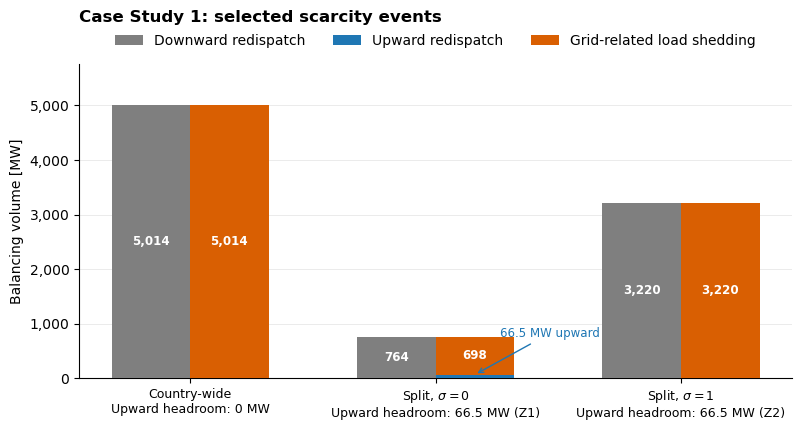

In [29]:
def plot_network_scarcity_event_cs1_55():

    headroom = pd.read_csv(
        output_dir
        / "network_event_headroom_by_zone.csv"
    )

    events = pd.read_csv(
        output_dir
        / "network_representative_events.csv"
    )

    scenario_order = [
        "nl34_z1_sigma0",
        "nl34_z3_sigma0",
        "nl34_z3_sigma100",
    ]

    design_labels = {
        "nl34_z1_sigma0": "Country-wide",
        "nl34_z3_sigma0": r"Split, $\sigma=0$",
        "nl34_z3_sigma100": r"Split, $\sigma=1$",
    }

    records = []

    for scenario in scenario_order:

        scenario_headroom = headroom.loc[
            headroom["scenario"] == scenario
        ].copy()

        scenario_event = events.loc[
            events["scenario"] == scenario
        ].iloc[0]

        downward_redispatch = (
            scenario_headroom[
                "redispatch_down_mw"
            ].sum()
        )

        upward_redispatch = (
            scenario_headroom[
                "redispatch_up_mw"
            ].sum()
        )

        upward_headroom = (
            scenario_headroom[
                "upward_headroom_before_mw"
            ].sum()
        )

        grid_shedding = float(
            scenario_event[
                "grid_load_shedding_mw"
            ]
        )

        positive_headroom = (
            scenario_headroom.loc[
                scenario_headroom[
                    "upward_headroom_before_mw"
                ] > 1e-3,
                [
                    "zone",
                    "upward_headroom_before_mw",
                ],
            ]
        )

        if positive_headroom.empty:
            headroom_label = (
                "Upward headroom: 0 MW"
            )

        else:
            zone_text = ", ".join(
                [
                    f"Z{int(row.zone)}"
                    for row in positive_headroom.itertuples(
                        index=False
                    )
                ]
            )

            headroom_label = (
                "Upward headroom: "
                f"{upward_headroom:.1f} MW "
                f"({zone_text})"
            )

        records.append(
            {
                "scenario": scenario,
                "design": design_labels[scenario],
                "downward_redispatch": (
                    downward_redispatch
                ),
                "upward_redispatch": (
                    upward_redispatch
                ),
                "grid_shedding": grid_shedding,
                "headroom_label": headroom_label,
            }
        )

    plot_data = pd.DataFrame(records)

    x = np.arange(len(plot_data))
    width = 0.32

    fig, ax = plt.subplots(
        figsize=(8.2, 4.4)
    )

    downward_colour = "#7F7F7F"
    upward_colour = "#1F77B4"
    shedding_colour = "#D95F02"

    downward_bars = ax.bar(
        x - width / 2,
        plot_data["downward_redispatch"],
        width=width,
        color=downward_colour,
        label="Downward redispatch",
        zorder=3,
    )

    upward_bars = ax.bar(
        x + width / 2,
        plot_data["upward_redispatch"],
        width=width,
        color=upward_colour,
        label="Upward redispatch",
        zorder=3,
    )

    shedding_bars = ax.bar(
        x + width / 2,
        plot_data["grid_shedding"],
        width=width,
        bottom=plot_data["upward_redispatch"],
        color=shedding_colour,
        label="Grid-related load shedding",
        zorder=3,
    )

    # --------------------------------------------------------
    # Value labels
    # --------------------------------------------------------

    for bar, value in zip(
        downward_bars,
        plot_data["downward_redispatch"],
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value / 2,
            f"{value:,.0f}",
            ha="center",
            va="center",
            fontsize=8.5,
            color="white",
            fontweight="semibold",
        )

    for bar, value in zip(
        shedding_bars,
        plot_data["grid_shedding"],
    ):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_y() + value / 2,
            f"{value:,.0f}",
            ha="center",
            va="center",
            fontsize=8.5,
            color="white",
            fontweight="semibold",
        )

    # The upward redispatch segment is small and therefore
    # receives a separate annotation.
    for index, value in enumerate(
        plot_data["upward_redispatch"]
    ):
        if value > 1e-3:
            ax.annotate(
                f"{value:.1f} MW upward",
                xy=(
                    x[index] + width / 2,
                    value,
                ),
                xytext=(18, 25),
                textcoords="offset points",
                ha="left",
                va="bottom",
                fontsize=8.5,
                color=upward_colour,
                arrowprops=dict(
                    arrowstyle="->",
                    color=upward_colour,
                    linewidth=1.0,
                ),
            )

    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------

    tick_labels = [
        (
            f"{row.design}\n"
            f"{row.headroom_label}"
        )
        for row in plot_data.itertuples(
            index=False
        )
    ]

    ax.set_xticks(x)
    ax.set_xticklabels(
        tick_labels,
        fontsize=9,
    )

    ax.set_ylabel("Balancing volume [MW]")

    ax.set_title(
        "Case Study 1: selected scarcity events",
        loc="left",
        fontweight="semibold",
        pad=30,
    )

    maximum_value = max(
        plot_data["downward_redispatch"].max(),
        (
            plot_data["upward_redispatch"]
            + plot_data["grid_shedding"]
        ).max(),
    )

    ax.set_ylim(
        0,
        maximum_value * 1.15,
    )

    ax.legend(
        frameon=False,
        ncol=3,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.01),
    )

    ax.grid(
        axis="y",
        alpha=0.25,
        linewidth=0.7,
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda value, position: (
                f"{value:,.0f}"
            )
        )
    )

    fig.tight_layout()

    save_section_figure(
        fig,
        "network_scarcity_event_cs1",
    )


if make_plots:
    plot_network_scarcity_event_cs1_55()

## Section 5.6: Cost trade-off and break-even valuation of grid-related load shedding


Processing: nl34_z1_sigma0
Processing: nl34_z3_sigma0
Processing: nl34_z3_sigma25
Processing: nl34_z3_sigma50
Processing: nl34_z3_sigma75
Processing: nl34_z3_sigma100
Processing: cs2_nl34_z1_sigma0
Processing: cs2_nl34_z3_sigma0
Processing: cs2_nl34_z3_sigma25
Processing: cs2_nl34_z3_sigma50
Processing: cs2_nl34_z3_sigma75
Processing: cs2_nl34_z3_sigma100


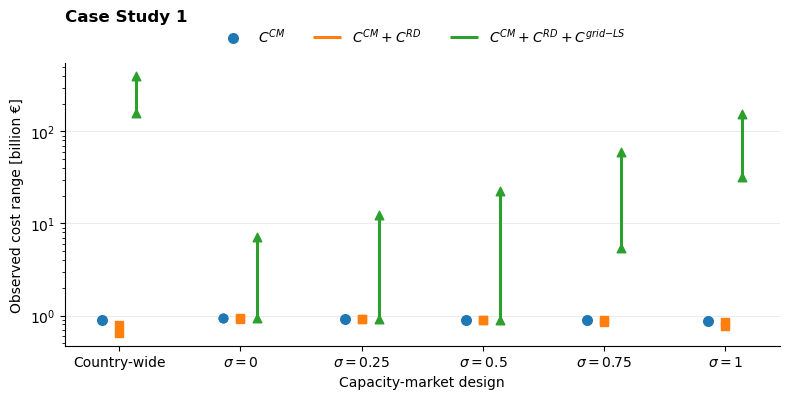

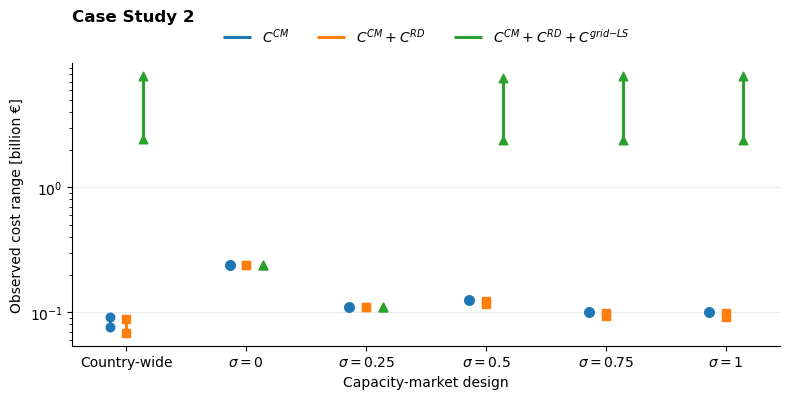

,case_study,design_label,capacity_market_cost_min,capacity_market_cost_max,redispatch_cost_min,redispatch_cost_max,grid_load_shedding_cost_min,grid_load_shedding_cost_max,total_cost_min,total_cost_max
6,Case Study 1,Country-wide,9.019479e+08,9.019479e+08,-2.533675e+08,-1.090368e+08,1.586849e+11,4.040383e+11,1.594771e+11,4.046880e+11
7,Case Study 1,$\sigma=0$,9.307059e+08,9.307061e+08,-4.359173e+06,7.409897e+05,0.000000e+00,6.278974e+09,9.307061e+08,7.205321e+09
9,Case Study 1,$\sigma=0.25$,9.178838e+08,9.178838e+08,-7.875674e+06,8.447489e+05,0.000000e+00,1.133633e+10,9.178838e+08,1.224634e+10
10,Case Study 1,$\sigma=0.5$,9.050615e+08,9.050615e+08,-1.508181e+07,1.498236e+05,0.000000e+00,2.164326e+10,9.051496e+08,2.253324e+10
11,Case Study 1,$\sigma=0.75$,8.922392e+08,8.922392e+08,-4.078099e+07,-2.805516e+06,4.463696e+09,5.852306e+10,5.353130e+09,5.937452e+10
8,Case Study 1,$\sigma=1$,8.794168e+08,8.794168e+08,-1.028088e+08,-2.180504e+07,3.129148e+10,1.520546e+11,3.214909e+10,1.528312e+11
0,Case Study 2,Country-wide,7.623992e+07,9.151637e+07,-7.929888e+06,-2.622647e+06,2.380368e+09,7.734712e+09,2.453985e+09,7.820289e+09
1,Case Study 2,$\sigma=0$,2.386495e+08,2.386495e+08,1.296775e+04,1.182457e+05,0.000000e+00,0.000000e+00,2.386624e+08,2.387677e+08
3,Case Study 2,$\sigma=0.25$,1.095059e+08,1.095059e+08,1.296775e+04,1.548453e+05,0.000000e+00,0.000000e+00,1.095188e+08,1.096607e+08
4,Case Study 2,$\sigma=0.5$,1.252593e+08,1.252593e+08,-8.837506e+06,-2.251344e+06,2.284794e+09,7.400761e+09,2.407692e+09,7.520889e+09


,case_study,design_label,break_even_voll_min,break_even_voll_max,avoided_grid_shedding_min_mwh,avoided_grid_shedding_max_mwh
0,Case Study 1,$\sigma=0$,47.209910,6.067000e+01,2.208789e+06,5.855100e+06
2,Case Study 1,$\sigma=0.25$,44.978605,5.510126e+01,2.135494e+06,5.854614e+06
3,Case Study 1,$\sigma=0.5$,42.687087,4.979174e+01,2.037502e+06,5.834226e+06
4,Case Study 1,$\sigma=0.75$,39.465223,4.344057e+01,1.531627e+06,5.567234e+06
1,Case Study 1,$\sigma=1$,23.767223,3.761764e+01,9.585582e+05,4.797856e+06
5,Case Study 2,$\sigma=0$,1356.954603,4.784184e+03,3.449808e+04,1.120973e+05
7,Case Study 2,$\sigma=0.25$,204.481995,1.043565e+03,3.449808e+04,1.120973e+05
8,Case Study 2,$\sigma=0.5$,615.052946,3.833537e+04,-4.730678e+04,5.807270e+04
9,Case Study 2,$\sigma=0.75$,185.982630,6.234665e+04,-2.392587e+04,5.792397e+04
6,Case Study 2,$\sigma=1$,186.137938,1.354921e+06,-2.392587e+04,5.792397e+04


: 

In [ ]:
VOLL_GRID_BASE_56 = 69_000.0  # €/MWh used in the model

cost_scenarios_56 = {
    "nl34_z1_sigma0": {
        "case_study": "Case Study 1",
        "design": "Country-wide",
        "sigma": np.nan,
        "design_order": 0,
        "design_label": "Country-wide",
    },
    "nl34_z3_sigma0": {
        "case_study": "Case Study 1",
        "design": "Split",
        "sigma": 0.00,
        "design_order": 1,
        "design_label": r"$\sigma=0$",
    },
    "nl34_z3_sigma25": {
        "case_study": "Case Study 1",
        "design": "Split",
        "sigma": 0.25,
        "design_order": 2,
        "design_label": r"$\sigma=0.25$",
    },
    "nl34_z3_sigma50": {
        "case_study": "Case Study 1",
        "design": "Split",
        "sigma": 0.50,
        "design_order": 3,
        "design_label": r"$\sigma=0.5$",
    },
    "nl34_z3_sigma75": {
        "case_study": "Case Study 1",
        "design": "Split",
        "sigma": 0.75,
        "design_order": 4,
        "design_label": r"$\sigma=0.75$",
    },
    "nl34_z3_sigma100": {
        "case_study": "Case Study 1",
        "design": "Split",
        "sigma": 1.00,
        "design_order": 5,
        "design_label": r"$\sigma=1$",
    },
    "cs2_nl34_z1_sigma0": {
        "case_study": "Case Study 2",
        "design": "Country-wide",
        "sigma": np.nan,
        "design_order": 0,
        "design_label": "Country-wide",
    },
    "cs2_nl34_z3_sigma0": {
        "case_study": "Case Study 2",
        "design": "Split",
        "sigma": 0.00,
        "design_order": 1,
        "design_label": r"$\sigma=0$",
    },
    "cs2_nl34_z3_sigma25": {
        "case_study": "Case Study 2",
        "design": "Split",
        "sigma": 0.25,
        "design_order": 2,
        "design_label": r"$\sigma=0.25$",
    },
    "cs2_nl34_z3_sigma50": {
        "case_study": "Case Study 2",
        "design": "Split",
        "sigma": 0.50,
        "design_order": 3,
        "design_label": r"$\sigma=0.5$",
    },
    "cs2_nl34_z3_sigma75": {
        "case_study": "Case Study 2",
        "design": "Split",
        "sigma": 0.75,
        "design_order": 4,
        "design_label": r"$\sigma=0.75$",
    },
    "cs2_nl34_z3_sigma100": {
        "case_study": "Case Study 2",
        "design": "Split",
        "sigma": 1.00,
        "design_order": 5,
        "design_label": r"$\sigma=1$",
    },
}


def numeric_columns_56(frame, columns):
    frame = frame.copy()

    for column in columns:
        if column in frame.columns:
            frame[column] = pd.to_numeric(
                frame[column],
                errors="coerce",
            )

    return frame


# ============================================================
# 1. Construct run-level cost table
# ============================================================

cost_run_frames_56 = []
cost_source_rows_56 = []

for scenario, meta in cost_scenarios_56.items():

    print("Processing:", scenario)

    summary, summary_source = merge_summary_with_reruns(
        scenario
    )

    cm_detail, cm_source = load_detail_with_optional_rerun(
        "cm_detail",
        scenario,
    )

    if summary is None or cm_detail is None:
        print(
            "  Missing summary or capacity-market detail; "
            "scenario skipped."
        )
        continue

    summary = numeric_columns_56(
        summary,
        [
            "run_id",
            "rd_cost_econ",
            "curtailment",
            "curt_cost",
        ],
    )

    cm_detail = numeric_columns_56(
        cm_detail,
        [
            "run_id",
            "cm_offer",
            "lambda_c_z",
        ],
    )

    required_summary_columns = {
        "run_id",
        "weight_type",
        "rd_cost_econ",
        "curtailment",
    }

    missing_summary_columns = (
        required_summary_columns
        - set(summary.columns)
    )

    if missing_summary_columns:
        raise KeyError(
            f"{scenario} summary is missing: "
            + ", ".join(
                sorted(missing_summary_columns)
            )
        )

    required_cm_columns = {
        "run_id",
        "cm_offer",
        "lambda_c_z",
    }

    missing_cm_columns = (
        required_cm_columns
        - set(cm_detail.columns)
    )

    if missing_cm_columns:
        raise KeyError(
            f"{scenario} capacity-market detail is missing: "
            + ", ".join(
                sorted(missing_cm_columns)
            )
        )

    # Capacity-market expenditure is calculated for every run
    # from all accepted offers and the corresponding zonal price.
    cm_detail["cm_payment"] = (
        cm_detail["cm_offer"]
        * cm_detail["lambda_c_z"]
    )

    cm_cost_by_run = (
        cm_detail
        .groupby(
            "run_id",
            as_index=False,
        )
        .agg(
            capacity_market_cost=(
                "cm_payment",
                "sum",
            )
        )
    )

    run_costs = (
        summary[
            [
                "run_id",
                "weight_type",
                "rd_cost_econ",
                "curtailment",
            ]
        ]
        .merge(
            cm_cost_by_run,
            on="run_id",
            how="inner",
            validate="one_to_one",
        )
    )

    run_costs = run_costs.dropna(
        subset=[
            "capacity_market_cost",
            "rd_cost_econ",
            "curtailment",
        ]
    )

    # Redispatch cost excludes grid-related load shedding.
    run_costs["cm_plus_redispatch_cost"] = (
        run_costs["capacity_market_cost"]
        + run_costs["rd_cost_econ"]
    )

    # Physical load shedding is revalued independently of the
    # original redispatch optimisation.
    run_costs["grid_load_shedding_cost"] = (
        run_costs["curtailment"]
        * VOLL_GRID_BASE_56
    )

    run_costs["total_cost"] = (
        run_costs["cm_plus_redispatch_cost"]
        + run_costs["grid_load_shedding_cost"]
    )

    run_costs["scenario"] = scenario
    run_costs["case_study"] = meta["case_study"]
    run_costs["design"] = meta["design"]
    run_costs["sigma"] = meta["sigma"]
    run_costs["design_order"] = meta["design_order"]
    run_costs["design_label"] = meta["design_label"]

    cost_run_frames_56.append(run_costs)

    cost_source_rows_56.append(
        {
            "scenario": scenario,
            "case_study": meta["case_study"],
            "design": meta["design"],
            "sigma": meta["sigma"],
            "summary_file": str(
                summary_source["base"]
            ),
            "cm_detail_file": str(
                cm_source["base"]
            ),
        }
    )


cost_tradeoff_by_run_56 = pd.concat(
    cost_run_frames_56,
    ignore_index=True,
)

cost_file_sources_56 = pd.DataFrame(
    cost_source_rows_56
)


# ============================================================
# 2. Observed min–max ranges by design
# ============================================================

cost_tradeoff_ranges_56 = (
    cost_tradeoff_by_run_56
    .groupby(
        [
            "scenario",
            "case_study",
            "design",
            "sigma",
            "design_order",
            "design_label",
        ],
        as_index=False,
        dropna=False,
    )
    .agg(
        capacity_market_cost_min=(
            "capacity_market_cost",
            "min",
        ),
        capacity_market_cost_max=(
            "capacity_market_cost",
            "max",
        ),
        redispatch_cost_min=(
            "rd_cost_econ",
            "min",
        ),
        redispatch_cost_max=(
            "rd_cost_econ",
            "max",
        ),
        grid_load_shedding_mwh_min=(
            "curtailment",
            "min",
        ),
        grid_load_shedding_mwh_max=(
            "curtailment",
            "max",
        ),
        grid_load_shedding_cost_min=(
            "grid_load_shedding_cost",
            "min",
        ),
        grid_load_shedding_cost_max=(
            "grid_load_shedding_cost",
            "max",
        ),
        cm_plus_redispatch_cost_min=(
            "cm_plus_redispatch_cost",
            "min",
        ),
        cm_plus_redispatch_cost_max=(
            "cm_plus_redispatch_cost",
            "max",
        ),
        total_cost_min=(
            "total_cost",
            "min",
        ),
        total_cost_max=(
            "total_cost",
            "max",
        ),
        runs=(
            "run_id",
            "nunique",
        ),
    )
    .sort_values(
        [
            "case_study",
            "design_order",
        ]
    )
)


# ============================================================
# 3. Matched break-even values
#
# Runs are paired by run_id and weight_type. These represent
# the same systematic PTDF exploration direction in the
# country-wide and split designs.
# ============================================================

paired_break_even_frames_56 = []

for case_study in [
    "Case Study 1",
    "Case Study 2",
]:

    countrywide = (
        cost_tradeoff_by_run_56.loc[
            (
                cost_tradeoff_by_run_56[
                    "case_study"
                ]
                == case_study
            )
            & (
                cost_tradeoff_by_run_56[
                    "design"
                ]
                == "Country-wide"
            ),
            [
                "run_id",
                "weight_type",
                "capacity_market_cost",
                "rd_cost_econ",
                "curtailment",
            ],
        ]
        .copy()
    )

    countrywide = countrywide.rename(
        columns={
            "capacity_market_cost": (
                "capacity_market_cost_countrywide"
            ),
            "rd_cost_econ": (
                "redispatch_cost_countrywide"
            ),
            "curtailment": (
                "grid_shedding_countrywide_mwh"
            ),
        }
    )

    split_scenarios = (
        cost_tradeoff_by_run_56.loc[
            (
                cost_tradeoff_by_run_56[
                    "case_study"
                ]
                == case_study
            )
            & (
                cost_tradeoff_by_run_56[
                    "design"
                ]
                == "Split"
            ),
            [
                "scenario",
                "sigma",
                "design_order",
                "design_label",
            ],
        ]
        .drop_duplicates()
        .sort_values("design_order")
    )

    for split_meta in split_scenarios.itertuples(
        index=False
    ):

        split = (
            cost_tradeoff_by_run_56.loc[
                cost_tradeoff_by_run_56[
                    "scenario"
                ]
                == split_meta.scenario,
                [
                    "run_id",
                    "weight_type",
                    "capacity_market_cost",
                    "rd_cost_econ",
                    "curtailment",
                ],
            ]
            .copy()
        )

        split = split.rename(
            columns={
                "capacity_market_cost": (
                    "capacity_market_cost_split"
                ),
                "rd_cost_econ": (
                    "redispatch_cost_split"
                ),
                "curtailment": (
                    "grid_shedding_split_mwh"
                ),
            }
        )

        paired = countrywide.merge(
            split,
            on=[
                "run_id",
                "weight_type",
            ],
            how="inner",
            validate="one_to_one",
        )

        paired["delta_capacity_market_cost"] = (
            paired[
                "capacity_market_cost_split"
            ]
            - paired[
                "capacity_market_cost_countrywide"
            ]
        )

        paired["delta_redispatch_cost"] = (
            paired[
                "redispatch_cost_split"
            ]
            - paired[
                "redispatch_cost_countrywide"
            ]
        )

        paired["delta_cost_excluding_grid_shedding"] = (
            paired[
                "delta_capacity_market_cost"
            ]
            + paired[
                "delta_redispatch_cost"
            ]
        )

        paired["avoided_grid_shedding_mwh"] = (
            paired[
                "grid_shedding_countrywide_mwh"
            ]
            - paired[
                "grid_shedding_split_mwh"
            ]
        )

        # Break-even value is defined where the split design
        # avoids a material amount of grid-related shedding.
        paired["break_even_voll_eur_per_mwh"] = np.where(
            paired[
                "avoided_grid_shedding_mwh"
            ] > 1.0,
            paired[
                "delta_cost_excluding_grid_shedding"
            ]
            / paired[
                "avoided_grid_shedding_mwh"
            ],
            np.nan,
        )

        paired["case_study"] = case_study
        paired["scenario"] = split_meta.scenario
        paired["sigma"] = split_meta.sigma
        paired["design_order"] = (
            split_meta.design_order
        )
        paired["design_label"] = (
            split_meta.design_label
        )

        paired_break_even_frames_56.append(
            paired
        )


paired_break_even_56 = pd.concat(
    paired_break_even_frames_56,
    ignore_index=True,
)


break_even_ranges_56 = (
    paired_break_even_56
    .groupby(
        [
            "case_study",
            "scenario",
            "sigma",
            "design_order",
            "design_label",
        ],
        as_index=False,
    )
    .agg(
        break_even_voll_min=(
            "break_even_voll_eur_per_mwh",
            "min",
        ),
        break_even_voll_max=(
            "break_even_voll_eur_per_mwh",
            "max",
        ),
        avoided_grid_shedding_min_mwh=(
            "avoided_grid_shedding_mwh",
            "min",
        ),
        avoided_grid_shedding_max_mwh=(
            "avoided_grid_shedding_mwh",
            "max",
        ),
        delta_cost_excluding_grid_shedding_min=(
            "delta_cost_excluding_grid_shedding",
            "min",
        ),
        delta_cost_excluding_grid_shedding_max=(
            "delta_cost_excluding_grid_shedding",
            "max",
        ),
        matched_runs=(
            "run_id",
            "nunique",
        ),
    )
    .sort_values(
        [
            "case_study",
            "design_order",
        ]
    )
)


# ============================================================
# 4. Save analysis outputs
# ============================================================

cost_tradeoff_by_run_56.to_csv(
    output_dir
    / "cost_tradeoff_by_run.csv",
    index=False,
)

cost_tradeoff_ranges_56.to_csv(
    output_dir
    / "cost_tradeoff_ranges.csv",
    index=False,
)

paired_break_even_56.to_csv(
    output_dir
    / "cost_break_even_by_matched_run.csv",
    index=False,
)

break_even_ranges_56.to_csv(
    output_dir
    / "cost_break_even_ranges.csv",
    index=False,
)

cost_file_sources_56.to_csv(
    output_dir
    / "cost_tradeoff_file_sources.csv",
    index=False,
)


# ============================================================
# 5. Cost-trade-off figure
#
# A logarithmic scale is used because grid-related load-
# shedding costs are several orders of magnitude larger than
# capacity-market and redispatch costs in some outcomes.
# ============================================================

def draw_cost_range_56(
    ax,
    x_position,
    lower,
    upper,
    marker,
    colour,
    label=None,
):
    if np.isclose(
        lower,
        upper,
        rtol=1e-8,
        atol=1e-8,
    ):
        ax.scatter(
            x_position,
            lower,
            marker=marker,
            s=48,
            color=colour,
            zorder=4,
            label=label,
        )

    else:
        ax.vlines(
            x_position,
            lower,
            upper,
            linewidth=2.2,
            color=colour,
            zorder=3,
            label=label,
        )

        ax.scatter(
            [x_position, x_position],
            [lower, upper],
            marker=marker,
            s=38,
            color=colour,
            zorder=4,
        )


def plot_cost_tradeoff_case_56(
    case_study,
    filename,
):
    case_data = (
        cost_tradeoff_ranges_56.loc[
            cost_tradeoff_ranges_56[
                "case_study"
            ]
            == case_study
        ]
        .sort_values("design_order")
        .copy()
    )

    if case_data.empty:
        raise ValueError(
            f"No cost-trade-off results found for "
            f"{case_study}."
        )

    x = case_data[
        "design_order"
    ].to_numpy(dtype=float)

    default_colours = (
        plt.rcParams[
            "axes.prop_cycle"
        ]
        .by_key()["color"]
    )

    component_specs = [
        {
            "minimum": "capacity_market_cost_min",
            "maximum": "capacity_market_cost_max",
            "offset": -0.14,
            "marker": "o",
            "colour": default_colours[0],
            "label": r"$C^{CM}$",
        },
        {
            "minimum": (
                "cm_plus_redispatch_cost_min"
            ),
            "maximum": (
                "cm_plus_redispatch_cost_max"
            ),
            "offset": 0.00,
            "marker": "s",
            "colour": default_colours[1],
            "label": (
                r"$C^{CM}+C^{RD}$"
            ),
        },
        {
            "minimum": "total_cost_min",
            "maximum": "total_cost_max",
            "offset": 0.14,
            "marker": "^",
            "colour": default_colours[2],
            "label": (
                r"$C^{CM}+C^{RD}"
                r"+C^{grid\mathrm{-}LS}$"
            ),
        },
    ]

    fig, ax = plt.subplots(
        figsize=(8.0, 4.1)
    )

    for component_index, spec in enumerate(
        component_specs
    ):
        lower_values = (
            case_data[
                spec["minimum"]
            ].to_numpy(dtype=float)
            / 1_000_000_000
        )

        upper_values = (
            case_data[
                spec["maximum"]
            ].to_numpy(dtype=float)
            / 1_000_000_000
        )

        for point_index, (
            x_value,
            lower,
            upper,
        ) in enumerate(
            zip(
                x,
                lower_values,
                upper_values,
            )
        ):
            draw_cost_range_56(
                ax=ax,
                x_position=(
                    x_value
                    + spec["offset"]
                ),
                lower=lower,
                upper=upper,
                marker=spec["marker"],
                colour=spec["colour"],
                label=(
                    spec["label"]
                    if point_index == 0
                    else None
                ),
            )

    # --------------------------------------------------------
    # Axis scale
    # --------------------------------------------------------

    all_lower_values = np.concatenate(
        [
            case_data[
                spec["minimum"]
            ].to_numpy(dtype=float)
            / 1_000_000_000
            for spec in component_specs
        ]
    )

    if np.all(all_lower_values > 0):
        ax.set_yscale("log")

    else:
        ax.set_yscale(
            "symlog",
            linthresh=0.05,
        )

    # --------------------------------------------------------
    # Axis formatting
    # --------------------------------------------------------

    design_labels = (
        case_data[
            "design_label"
        ].tolist()
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        design_labels
    )

    ax.set_xlim(
        x.min() - 0.45,
        x.max() + 0.45,
    )

    ax.set_xlabel(
        "Capacity-market design"
    )

    ax.set_ylabel(
        "Observed cost range [billion €]"
    )

    ax.set_title(
        case_study,
        loc="left",
        fontweight="semibold",
        pad=30,
    )

    ax.legend(
        frameon=False,
        ncol=3,
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
    )

    ax.grid(
        axis="y",
        which="major",
        alpha=0.25,
        linewidth=0.7,
    )

    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.tight_layout()

    save_section_figure(
        fig,
        filename,
    )


if make_plots:

    plot_cost_tradeoff_case_56(
        case_study="Case Study 1",
        filename="cost_tradeoff_ranges_cs1",
    )

    plot_cost_tradeoff_case_56(
        case_study="Case Study 2",
        filename="cost_tradeoff_ranges_cs2",
    )


# ============================================================
# 6. Display concise outputs
# ============================================================

display(
    cost_tradeoff_ranges_56[
        [
            "case_study",
            "design_label",
            "capacity_market_cost_min",
            "capacity_market_cost_max",
            "redispatch_cost_min",
            "redispatch_cost_max",
            "grid_load_shedding_cost_min",
            "grid_load_shedding_cost_max",
            "total_cost_min",
            "total_cost_max",
        ]
    ]
)

display(
    break_even_ranges_56[
        [
            "case_study",
            "design_label",
            "break_even_voll_min",
            "break_even_voll_max",
            "avoided_grid_shedding_min_mwh",
            "avoided_grid_shedding_max_mwh",
        ]
    ]
)